# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [ ]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results
import seaborn as sns  # we use seaborn for enhanced heatmap visualizations

In [ ]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "entropy")

# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [ ]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [ ]:

def get_ordinal_suffix(n):
    """we get the ordinal suffix for a number (1st, 2nd, 3rd, 4th, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

def compute_entropy_in_eigenvector_basis(eigenvectors, eigenvector_order, N, D_IN, M, L, output_dir):
    """
    We compute the entropy of the distribution for each coordinate of a specific eigenvector order,
    but using the eigenvectors of the first experiment as the basis.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    # we use the first experiment's eigenvectors as the basis
    first_experiment_basis = eigenvectors[0, :, :] # shape (n_vectors, dimension)
    
    try: # we get the eigenvectors for the specific order from all other experiments
        selected_eigenvectors = eigenvectors[1:, eigenvector_order, :] # shape (n_experiments-1, dimension)
    except IndexError:
        print(f"Warning: Could not extract eigenvector {eigenvector_order+1} for config N{N}_D{D_IN}_M{M}_L{L}.")
        return None

    n_remaining_experiments, dimension = selected_eigenvectors.shape
    
    # we project each eigenvector onto the basis formed by first experiment's eigenvectors
    coordinates_in_basis = []
    for exp_idx in range(n_remaining_experiments):
        eigenvector = selected_eigenvectors[exp_idx, :] # current eigenvector
        
        # we compute scalar products with each basis vector
        coords = []
        for basis_idx in range(min(n_vectors, dimension-1)): # we use N-1 vectors as mentioned
            basis_vector = first_experiment_basis[basis_idx, :]
            scalar_product = np.dot(eigenvector, basis_vector)
            coords.append(scalar_product)
        
        coordinates_in_basis.append(coords)
    
    coordinates_in_basis = np.array(coordinates_in_basis) # shape (n_remaining_experiments, n_basis_vectors)
    
    # we compute entropy for each coordinate in the new basis
    coordinate_entropies = []
    n_basis_coords = coordinates_in_basis.shape[1]
    
    for i in range(n_basis_coords): # we compute entropy coordinate-wise in new basis
        coordinate_values = coordinates_in_basis[:, i]
        
        hist, bin_edges = np.histogram(coordinate_values, bins='auto', density=True)
        bin_width = bin_edges[1] - bin_edges[0]
        
        # we normalize
        probabilities = hist * bin_width
        probabilities = probabilities[probabilities > 0] # we remove zero probabilities
        
        entropy = -np.sum(probabilities * np.log2(probabilities))
        coordinate_entropies.append(entropy)
    
    return coordinate_entropies

def analyze_entropy_in_eigenvector_basis(eigenvectors, N, D_IN, M, L, output_dir):
    """
    Analyze entropy distributions using the first experiment's eigenvectors as basis.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    if n_experiments < 2:
        print(f"Warning: Need at least 2 experiments for basis analysis, got {n_experiments}")
        return None
    
    print(f"Computing entropy in eigenvector basis - N{N}_D{D_IN}_M{M}_L{L}")
    print(f"Using first experiment as basis, analyzing {n_experiments-1} remaining experiments")
    
    # we compute entropy for each eigenvector order
    all_entropies = []
    n_basis_vectors = min(n_vectors, dimension-1) # we use N-1 vectors as basis
    
    for k in range(n_vectors):
        entropies = compute_entropy_in_eigenvector_basis(eigenvectors, k, N, D_IN, M, L, output_dir)
        if entropies is not None:
            all_entropies.append(entropies)
    
    if not all_entropies:
        print("No valid entropy computations")
        return None
        
    all_entropies = np.array(all_entropies) # shape (n_vectors, n_basis_vectors)
    
    # viz creation
    plt.figure(figsize=(14, 10))
    
    # we plot entropy for each eigenvector order
    eigenvector_indices = list(range(1, len(all_entropies) + 1))
    basis_indices = list(range(1, n_basis_vectors + 1))
    
    plt.subplot(2, 2, 1)
    mean_entropies = np.mean(all_entropies, axis=1)
    std_entropies = np.std(all_entropies, axis=1)
    
    plt.errorbar(eigenvector_indices, mean_entropies, yerr=std_entropies,
                fmt='o-', capsize=5, linewidth=2, markersize=6)
    plt.title(f'Mean Entropy in Eigenvector Basis\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Mean Entropy (bits)')
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.imshow(all_entropies.T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Entropy (bits)')
    plt.title('Entropy Heatmap (Eigenvector Basis)')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Basis Vector Index')
    
    # we plot distribution of all entropies
    plt.subplot(2, 2, 3)
    all_entropy_values = all_entropies.flatten()
    plt.hist(all_entropy_values, bins=30, alpha=0.7, density=True)
    plt.axvline(np.mean(all_entropy_values), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_entropy_values):.3f}')
    plt.title('Distribution of All Entropies')
    plt.xlabel('Entropy (bits)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    
    # we plot entropy vs basis vector index
    plt.subplot(2, 2, 4)
    mean_entropies_per_basis = np.mean(all_entropies, axis=0)
    std_entropies_per_basis = np.std(all_entropies, axis=0)
    
    plt.errorbar(basis_indices, mean_entropies_per_basis, yerr=std_entropies_per_basis,
                fmt='s-', capsize=5, linewidth=2, markersize=6, color='orange')
    plt.title('Mean Entropy per Basis Vector')
    plt.xlabel('Basis Vector Index')
    plt.ylabel('Mean Entropy (bits)')
    plt.grid(True)
    
    plt.tight_layout()
    
    # Save plot
    entropy_filename = os.path.join(output_dir, f'entropy_eigenvector_basis_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(entropy_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Print statistics
    print(f"\nEntropy Statistics in Eigenvector Basis:")
    print(f"  Overall mean entropy: {np.mean(all_entropy_values):.4f} ± {np.std(all_entropy_values):.4f} bits")
    print(f"  Max entropy: {np.max(all_entropy_values):.4f} bits")
    print(f"  Min entropy: {np.min(all_entropy_values):.4f} bits")
    print(f"  Number of basis vectors used: {n_basis_vectors}")
    
    # Find most and least random eigenvectors
    most_random_idx = np.argmax(mean_entropies)
    least_random_idx = np.argmin(mean_entropies)
    
    print(f"\nMost random eigenvector: {get_ordinal_suffix(most_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[most_random_idx]:.4f} ± {std_entropies[most_random_idx]:.4f} bits")
    
    print(f"\nLeast random eigenvector: {get_ordinal_suffix(least_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[least_random_idx]:.4f} ± {std_entropies[least_random_idx]:.4f} bits")
    
    # we test uniformity hypothesis
    theoretical_uniform_entropy = np.log2(n_experiments-1) # we approximate for uniform distribution
    print(f"\nUniformity Analysis:")
    print(f"  Theoretical uniform entropy (approx): {theoretical_uniform_entropy:.4f} bits")
    print(f"  Observed mean entropy: {np.mean(all_entropy_values):.4f} bits")
    print(f"  Difference: {np.mean(all_entropy_values) - theoretical_uniform_entropy:.4f} bits")
    
    return {
        'mean_entropies': mean_entropies,
        'std_entropies': std_entropies,
        'all_entropies': all_entropies,
        'most_random_idx': most_random_idx,
        'least_random_idx': least_random_idx,
        'n_basis_vectors': n_basis_vectors,
        'theoretical_uniform_entropy': theoretical_uniform_entropy
    }

Processing all experiment files for eigenvector basis entropy analysis...


Processing experiment files:   0%|          | 0/97 [00:00<?, ?it/s]

Computing entropy in eigenvector basis - N8_D20_M10_L8
Using first experiment as basis, analyzing 99 remaining experiments


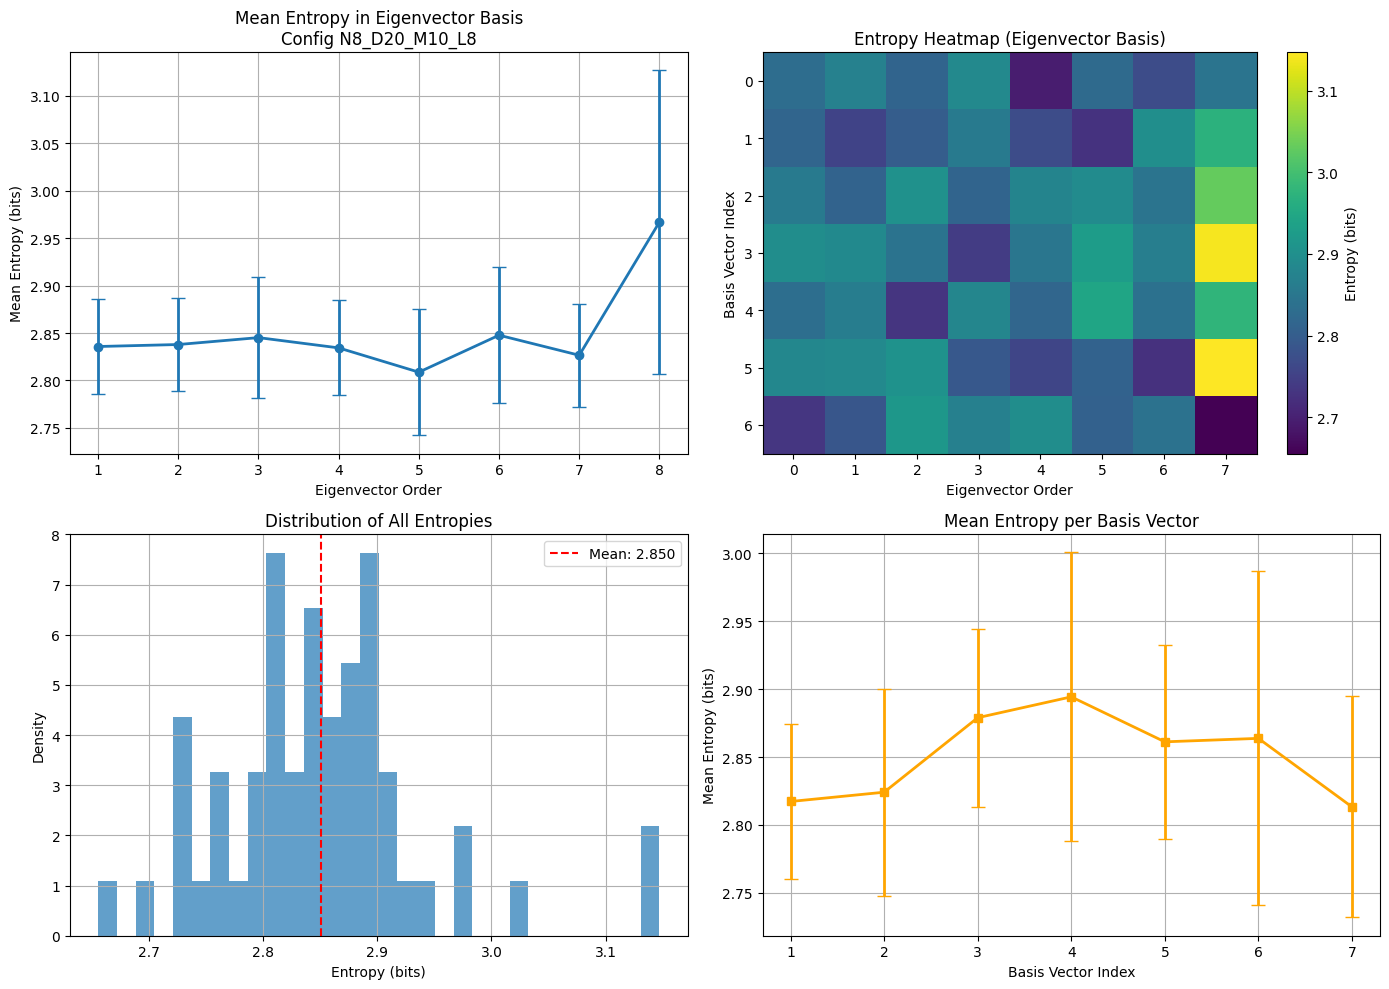

Processing experiment files:   1%|          | 1/97 [00:08<13:42,  8.57s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8504 ± 0.0908 bits
  Max entropy: 3.1472 bits
  Min entropy: 2.6553 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9669 ± 0.1599 bits

Least random eigenvector: 5th
  Mean entropy: 2.8088 ± 0.0666 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8504 bits
  Difference: -3.7789 bits


Computing entropy in eigenvector basis - N8_D20_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


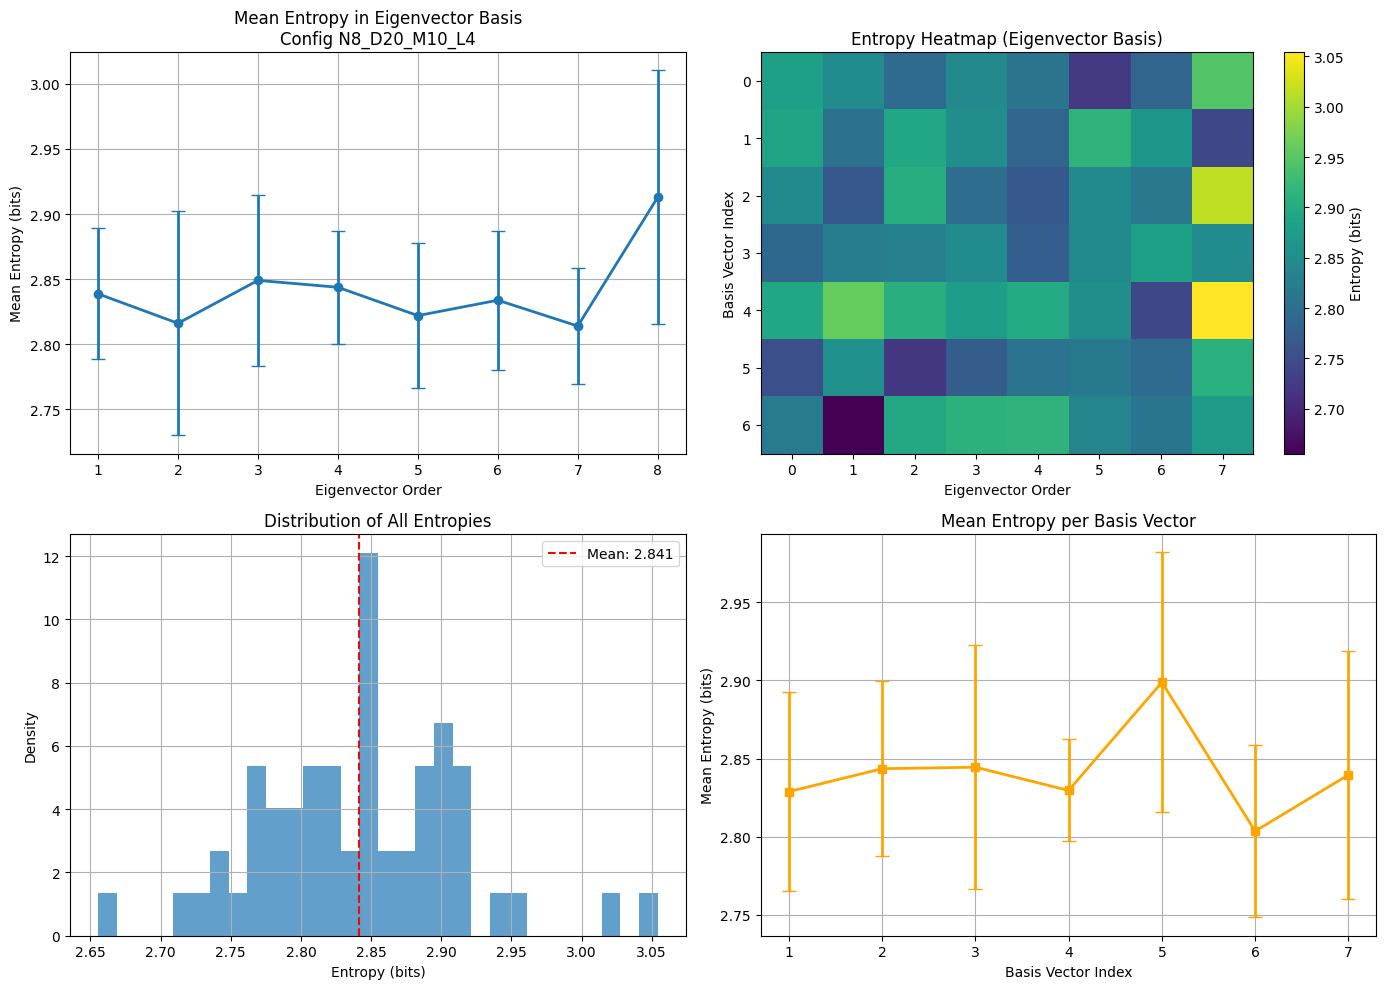

Processing experiment files:   2%|▏         | 2/97 [00:18<14:48,  9.36s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8412 ± 0.0713 bits
  Max entropy: 3.0543 bits
  Min entropy: 2.6554 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9129 ± 0.0976 bits

Least random eigenvector: 7th
  Mean entropy: 2.8138 ± 0.0443 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8412 bits
  Difference: -3.7882 bits


Computing entropy in eigenvector basis - N8_D50_M50_L6
Using first experiment as basis, analyzing 99 remaining experiments


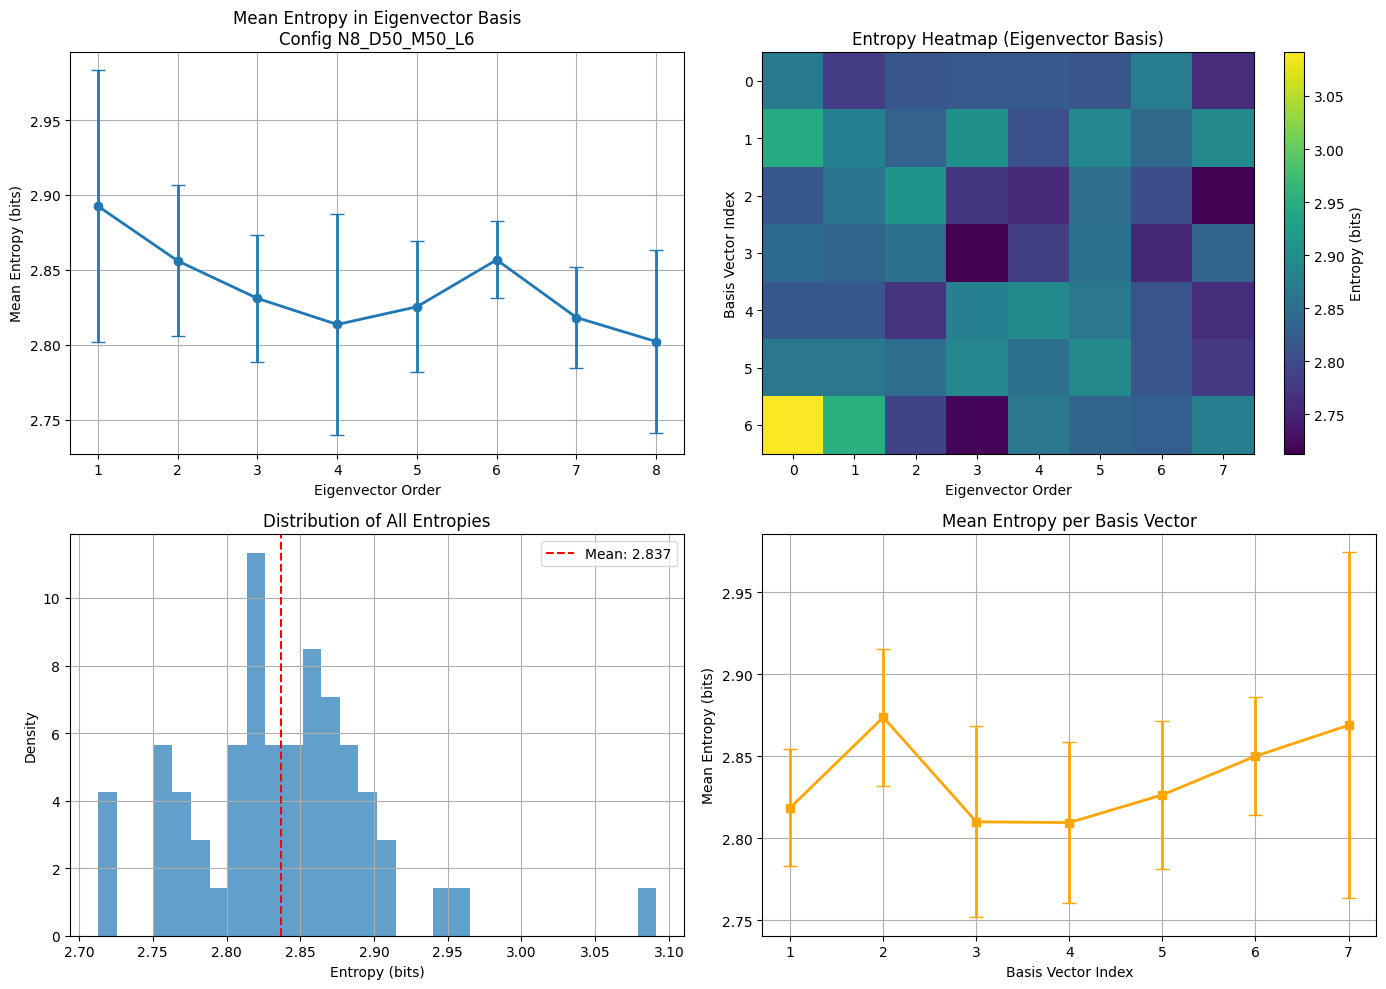

Processing experiment files:   3%|▎         | 3/97 [00:28<14:52,  9.49s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8369 ± 0.0629 bits
  Max entropy: 3.0913 bits
  Min entropy: 2.7128 bits
  Number of basis vectors used: 7

Most random eigenvector: 1st
  Mean entropy: 2.8925 ± 0.0906 bits

Least random eigenvector: 8th
  Mean entropy: 2.8020 ± 0.0614 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8369 bits
  Difference: -3.7925 bits


Computing entropy in eigenvector basis - N8_D50_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


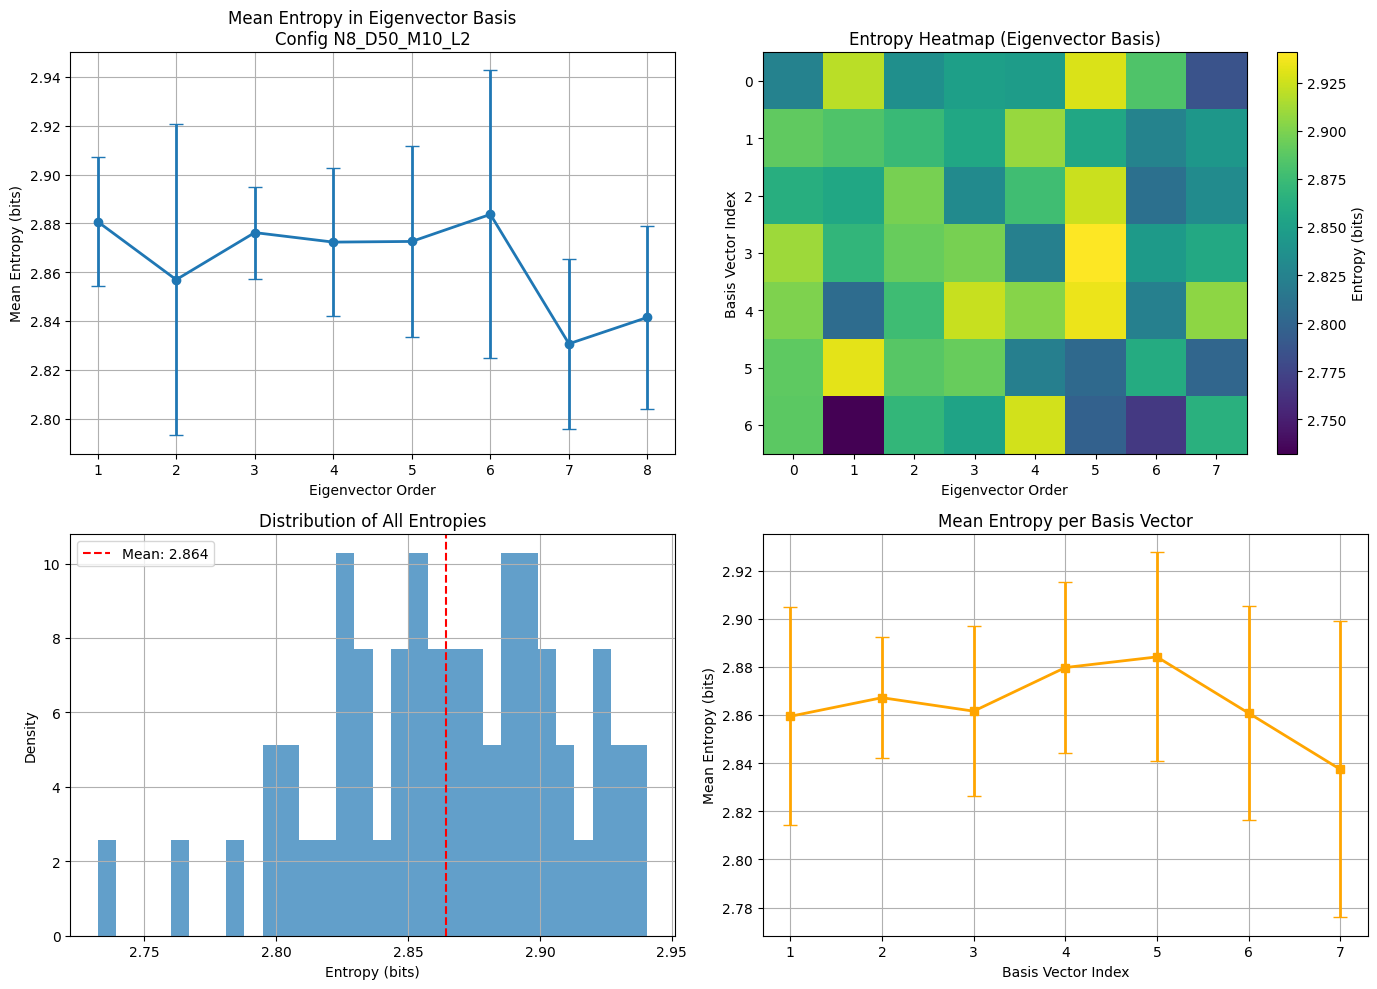

Processing experiment files:   4%|▍         | 4/97 [00:36<14:07,  9.11s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8643 ± 0.0452 bits
  Max entropy: 2.9408 bits
  Min entropy: 2.7322 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.8837 ± 0.0590 bits

Least random eigenvector: 7th
  Mean entropy: 2.8306 ± 0.0348 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8643 bits
  Difference: -3.7651 bits


Computing entropy in eigenvector basis - N8_D20_M50_L4
Using first experiment as basis, analyzing 99 remaining experiments


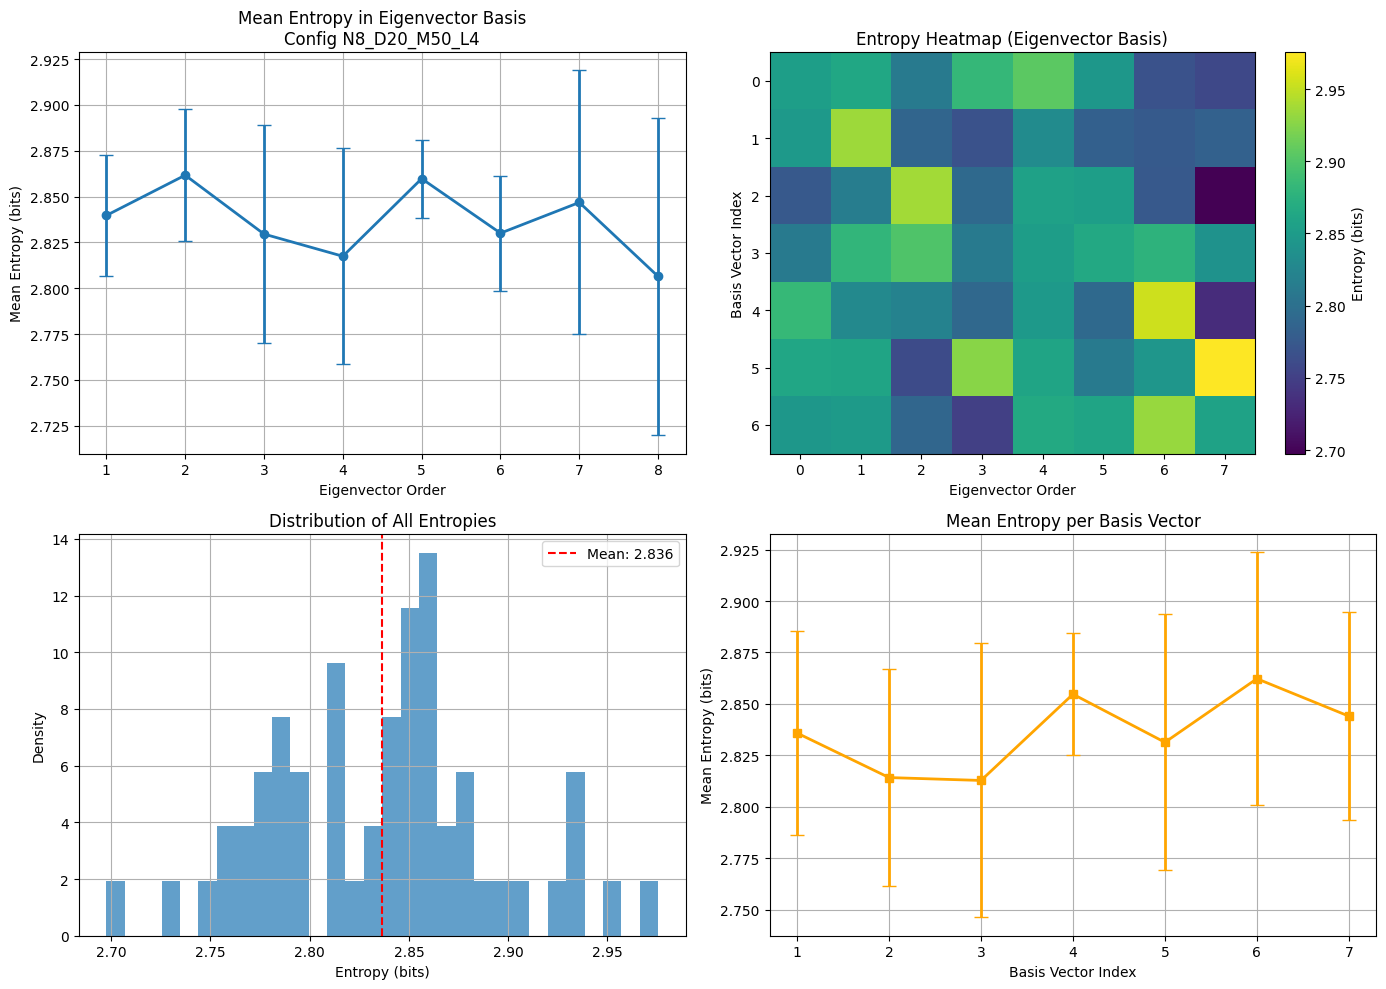

Processing experiment files:   5%|▌         | 5/97 [00:46<14:24,  9.40s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8364 ± 0.0572 bits
  Max entropy: 2.9756 bits
  Min entropy: 2.6975 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.8617 ± 0.0362 bits

Least random eigenvector: 8th
  Mean entropy: 2.8064 ± 0.0866 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8364 bits
  Difference: -3.7929 bits


Computing entropy in eigenvector basis - N8_D20_M20_L8
Using first experiment as basis, analyzing 99 remaining experiments


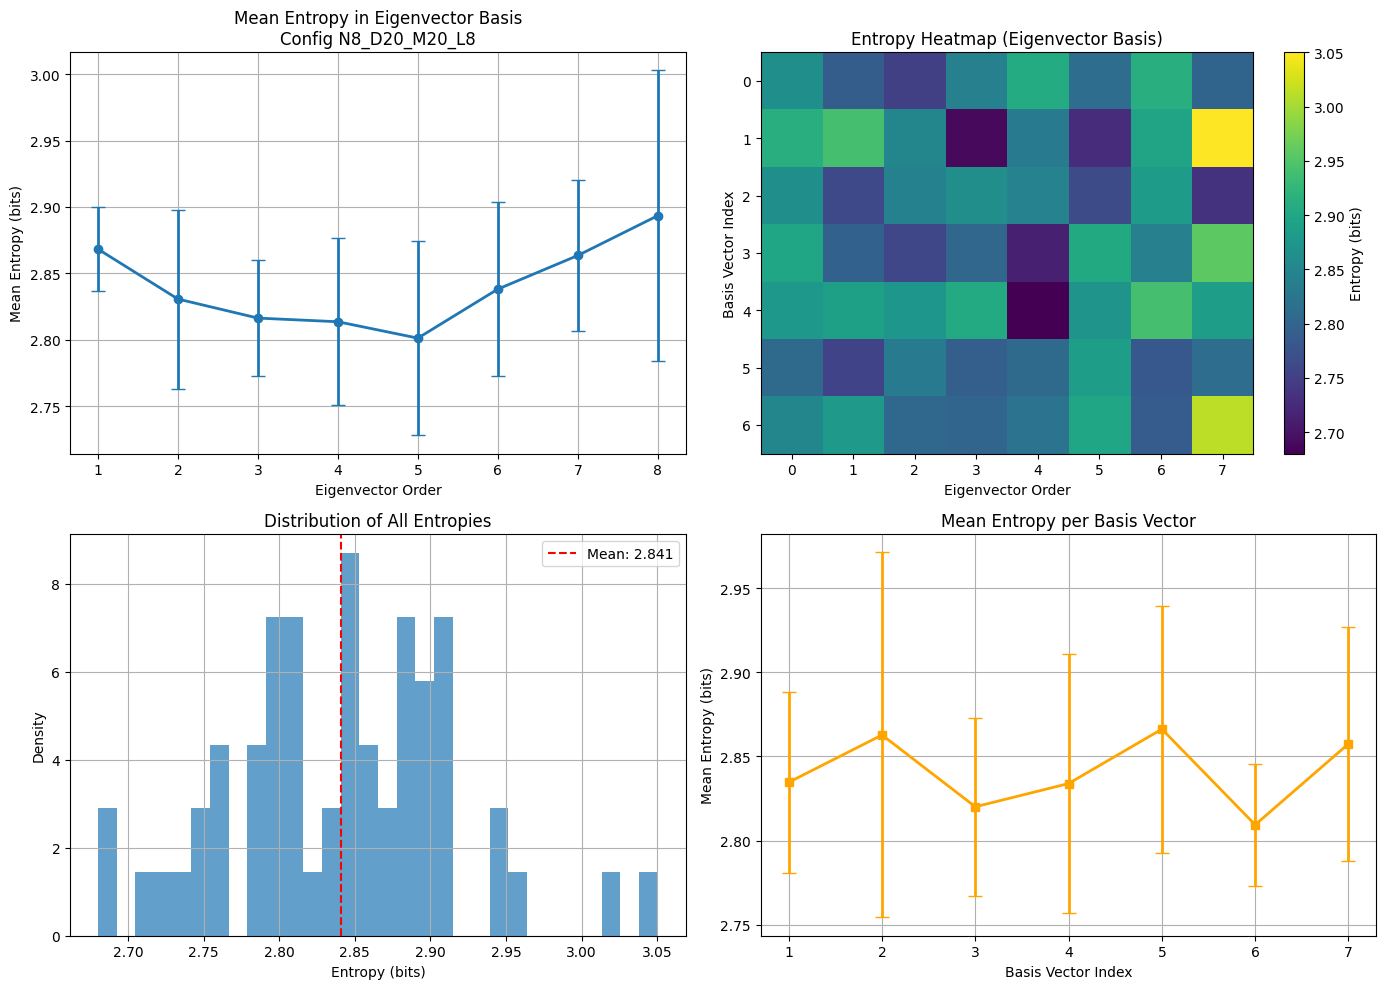

Processing experiment files:   6%|▌         | 6/97 [00:55<14:08,  9.33s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8406 ± 0.0736 bits
  Max entropy: 3.0503 bits
  Min entropy: 2.6802 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8934 ± 0.1094 bits

Least random eigenvector: 5th
  Mean entropy: 2.8013 ± 0.0732 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8406 bits
  Difference: -3.7887 bits


Computing entropy in eigenvector basis - N8_D200_M50_L2
Using first experiment as basis, analyzing 99 remaining experiments


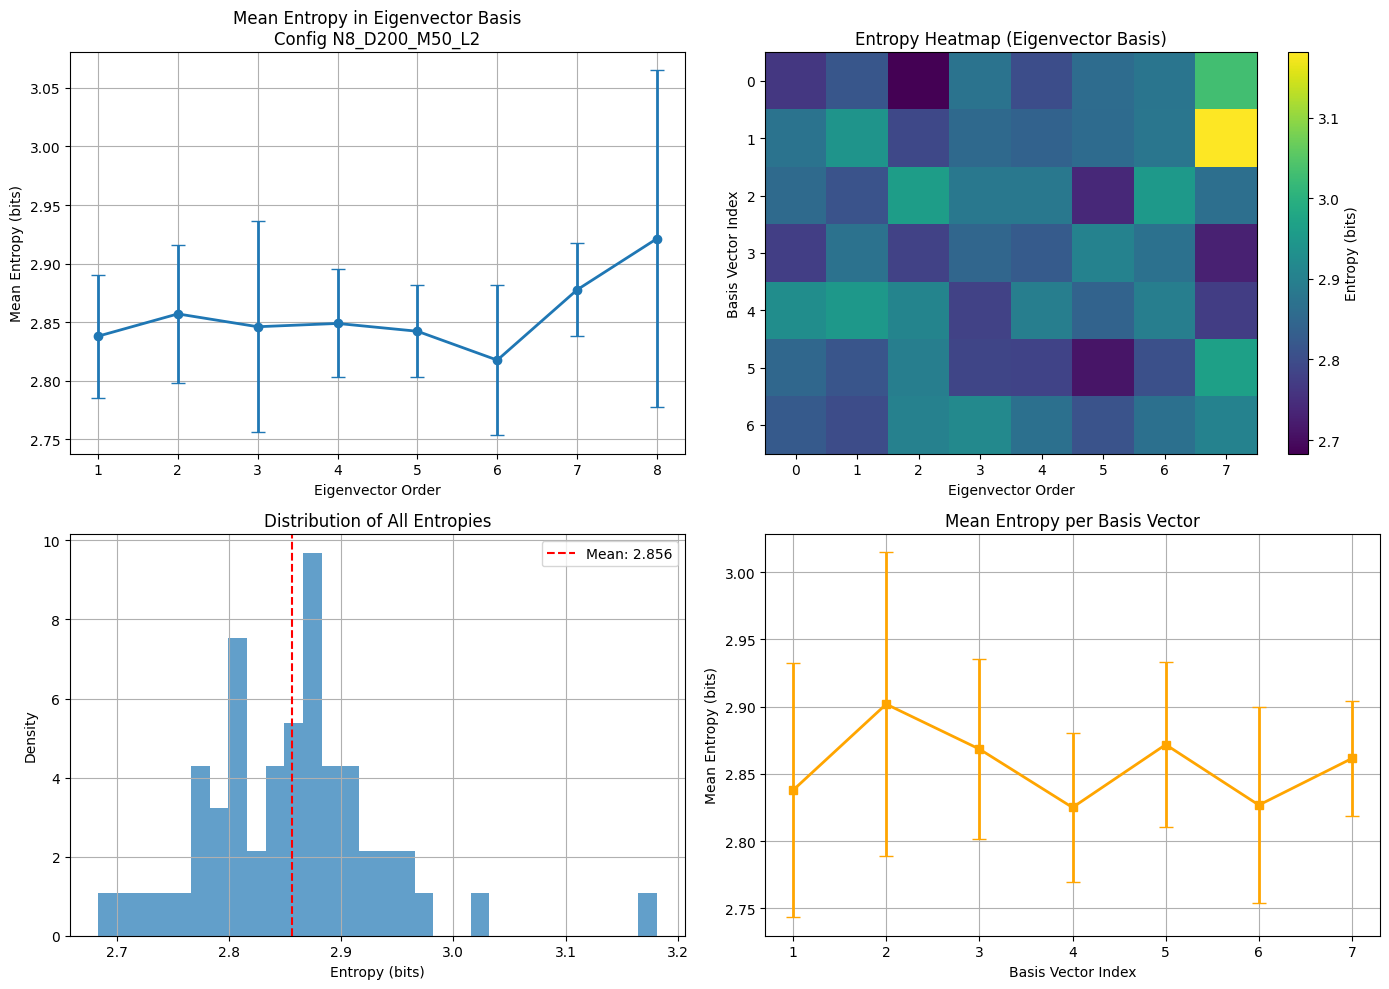

Processing experiment files:   7%|▋         | 7/97 [01:04<13:51,  9.24s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8562 ± 0.0800 bits
  Max entropy: 3.1816 bits
  Min entropy: 2.6831 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9214 ± 0.1435 bits

Least random eigenvector: 6th
  Mean entropy: 2.8177 ± 0.0642 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8562 bits
  Difference: -3.7732 bits


Computing entropy in eigenvector basis - N8_D100_M20_L6
Using first experiment as basis, analyzing 99 remaining experiments


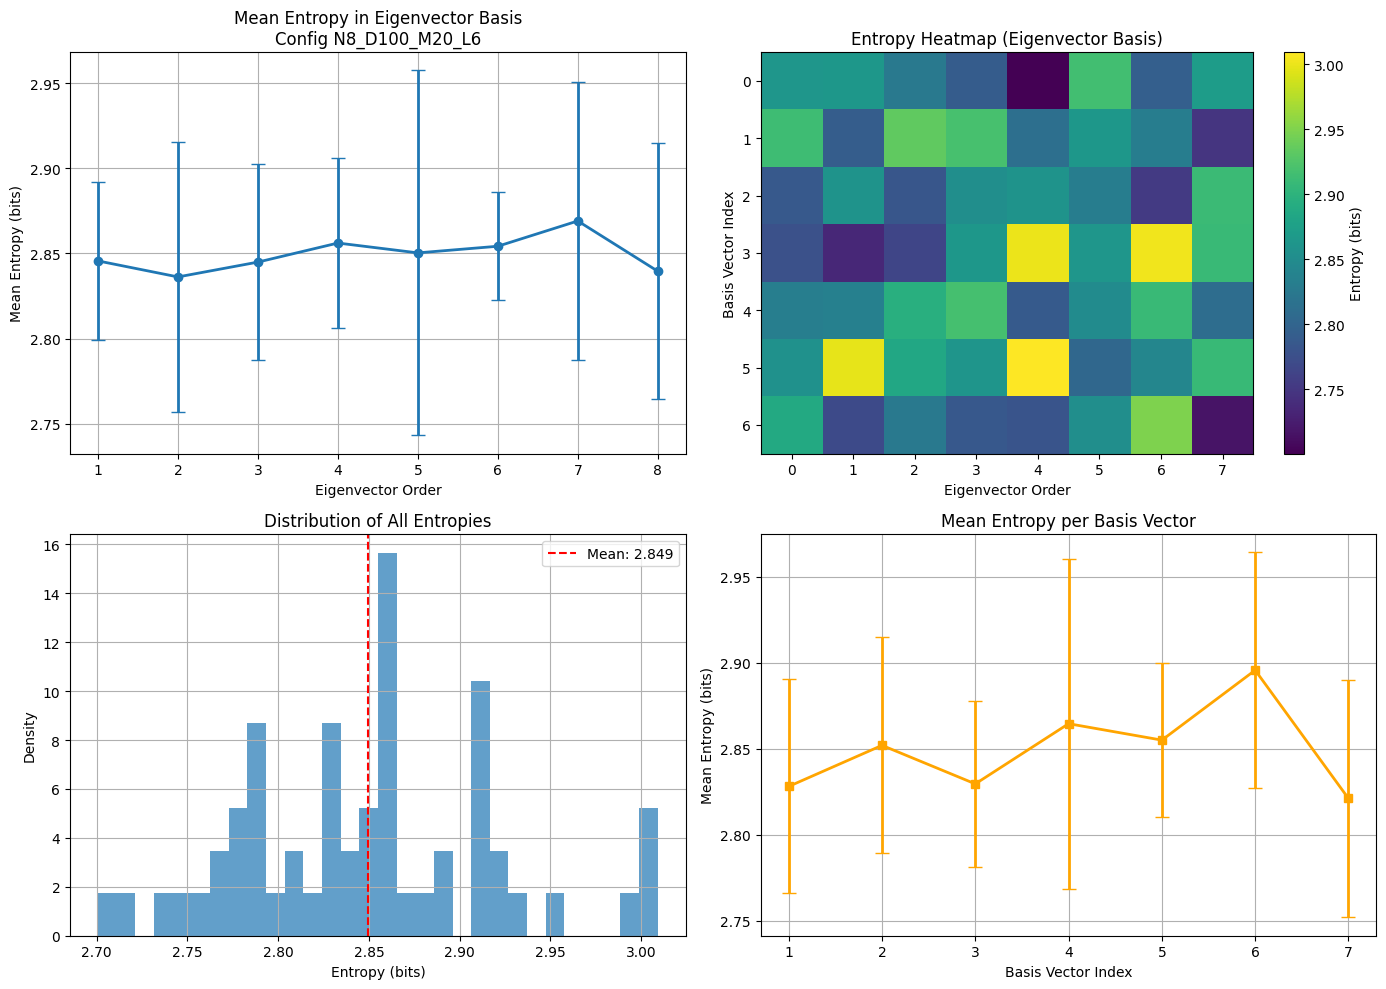

Processing experiment files:   8%|▊         | 8/97 [01:13<13:18,  8.97s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8495 ± 0.0706 bits
  Max entropy: 3.0092 bits
  Min entropy: 2.7007 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.8690 ± 0.0818 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8362 ± 0.0793 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8495 bits
  Difference: -3.7799 bits


Computing entropy in eigenvector basis - N8_D20_M10_L6
Using first experiment as basis, analyzing 99 remaining experiments


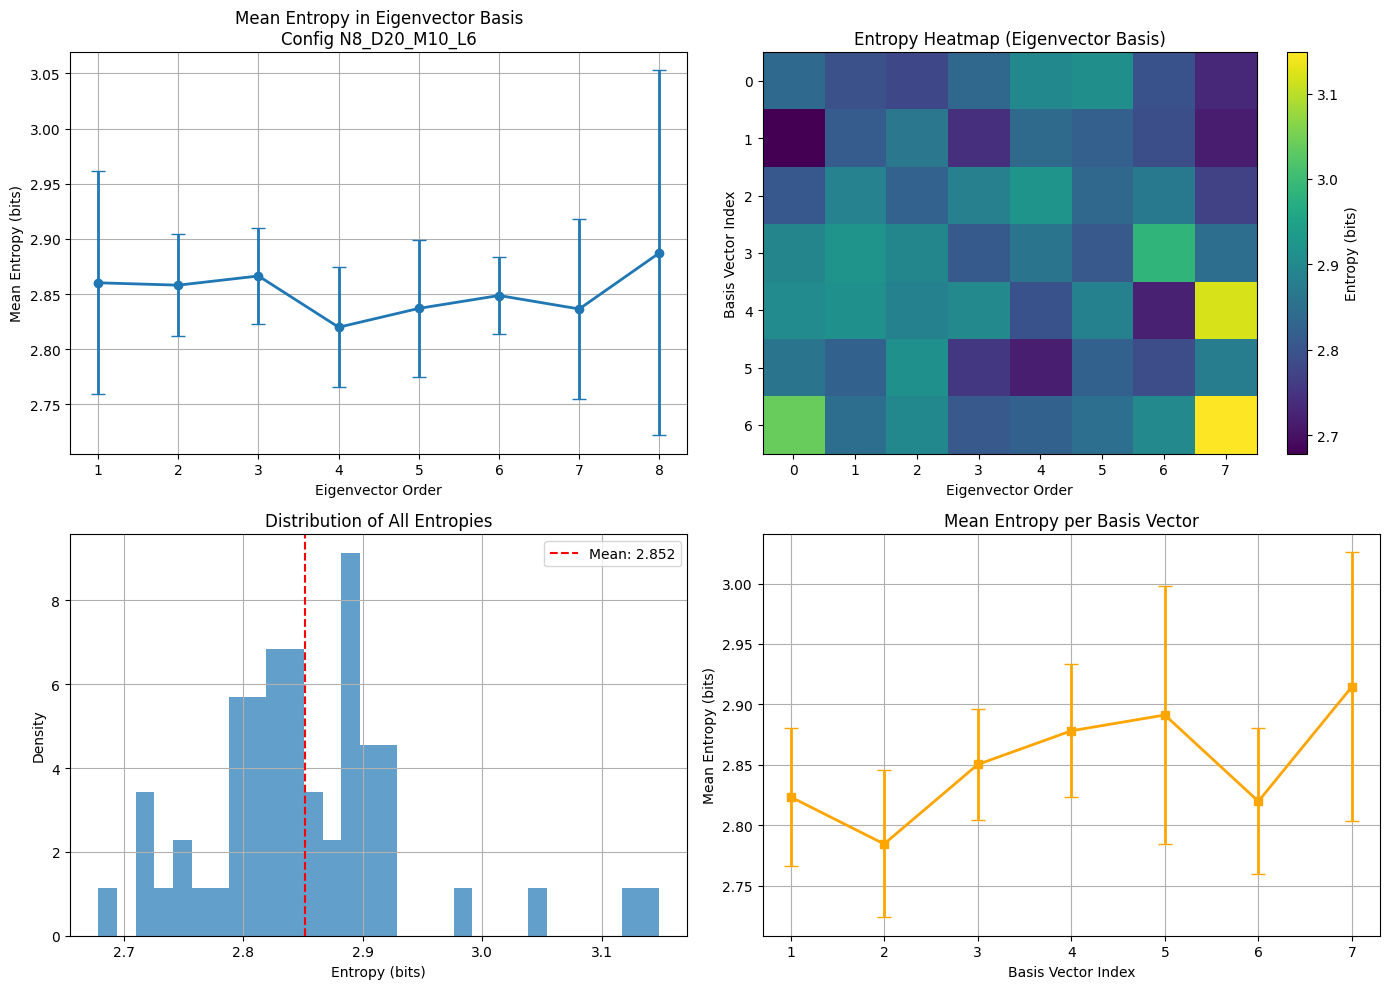

Processing experiment files:   9%|▉         | 9/97 [01:22<13:16,  9.05s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8517 ± 0.0861 bits
  Max entropy: 3.1484 bits
  Min entropy: 2.6786 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8873 ± 0.1654 bits

Least random eigenvector: 4th
  Mean entropy: 2.8199 ± 0.0546 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8517 bits
  Difference: -3.7776 bits


Computing entropy in eigenvector basis - N8_D20_M100_L6
Using first experiment as basis, analyzing 99 remaining experiments


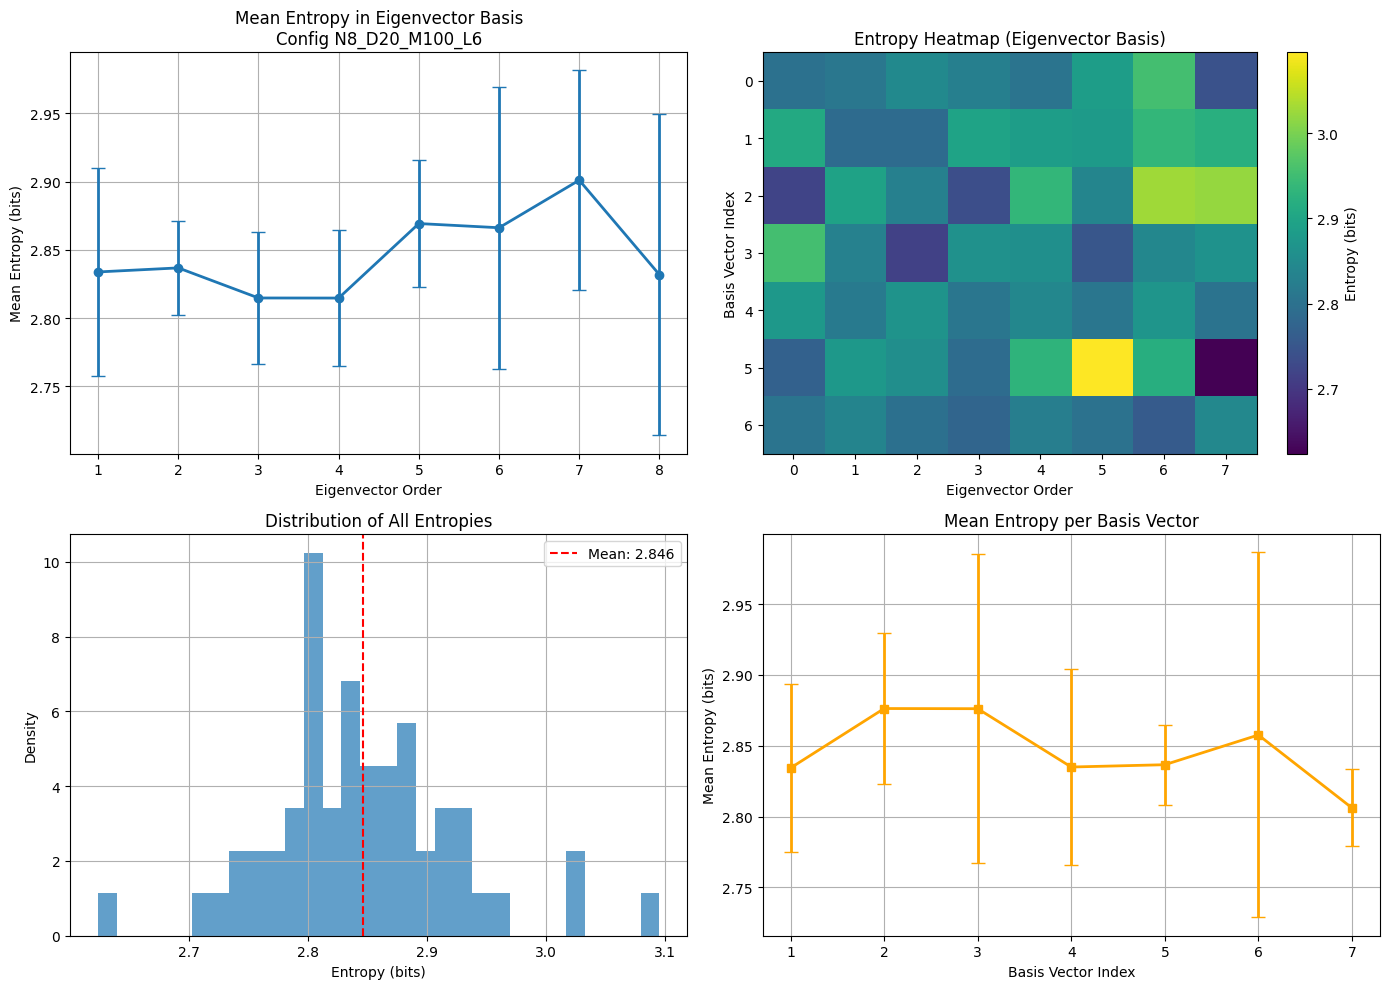

Processing experiment files:  10%|█         | 10/97 [01:31<13:10,  9.09s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8460 ± 0.0802 bits
  Max entropy: 3.0953 bits
  Min entropy: 2.6240 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.9011 ± 0.0805 bits

Least random eigenvector: 4th
  Mean entropy: 2.8146 ± 0.0496 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8460 bits
  Difference: -3.7833 bits


Computing entropy in eigenvector basis - N8_D100_M20_L2
Using first experiment as basis, analyzing 99 remaining experiments


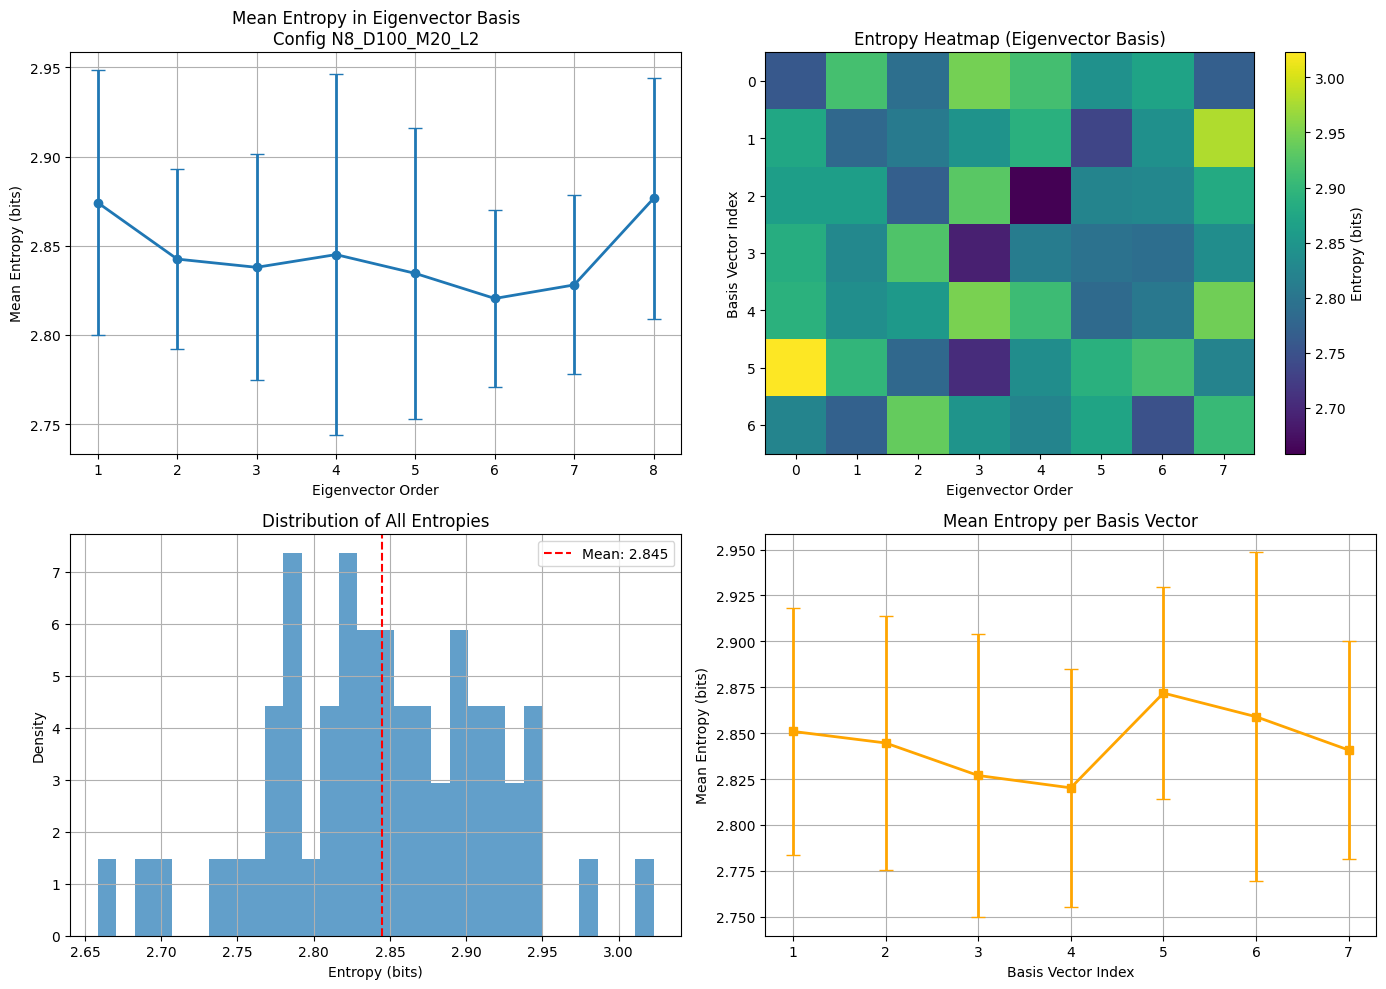

Processing experiment files:  11%|█▏        | 11/97 [01:39<12:37,  8.81s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8449 ± 0.0720 bits
  Max entropy: 3.0229 bits
  Min entropy: 2.6585 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8766 ± 0.0674 bits

Least random eigenvector: 6th
  Mean entropy: 2.8204 ± 0.0499 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8449 bits
  Difference: -3.7845 bits


Computing entropy in eigenvector basis - N8_D200_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


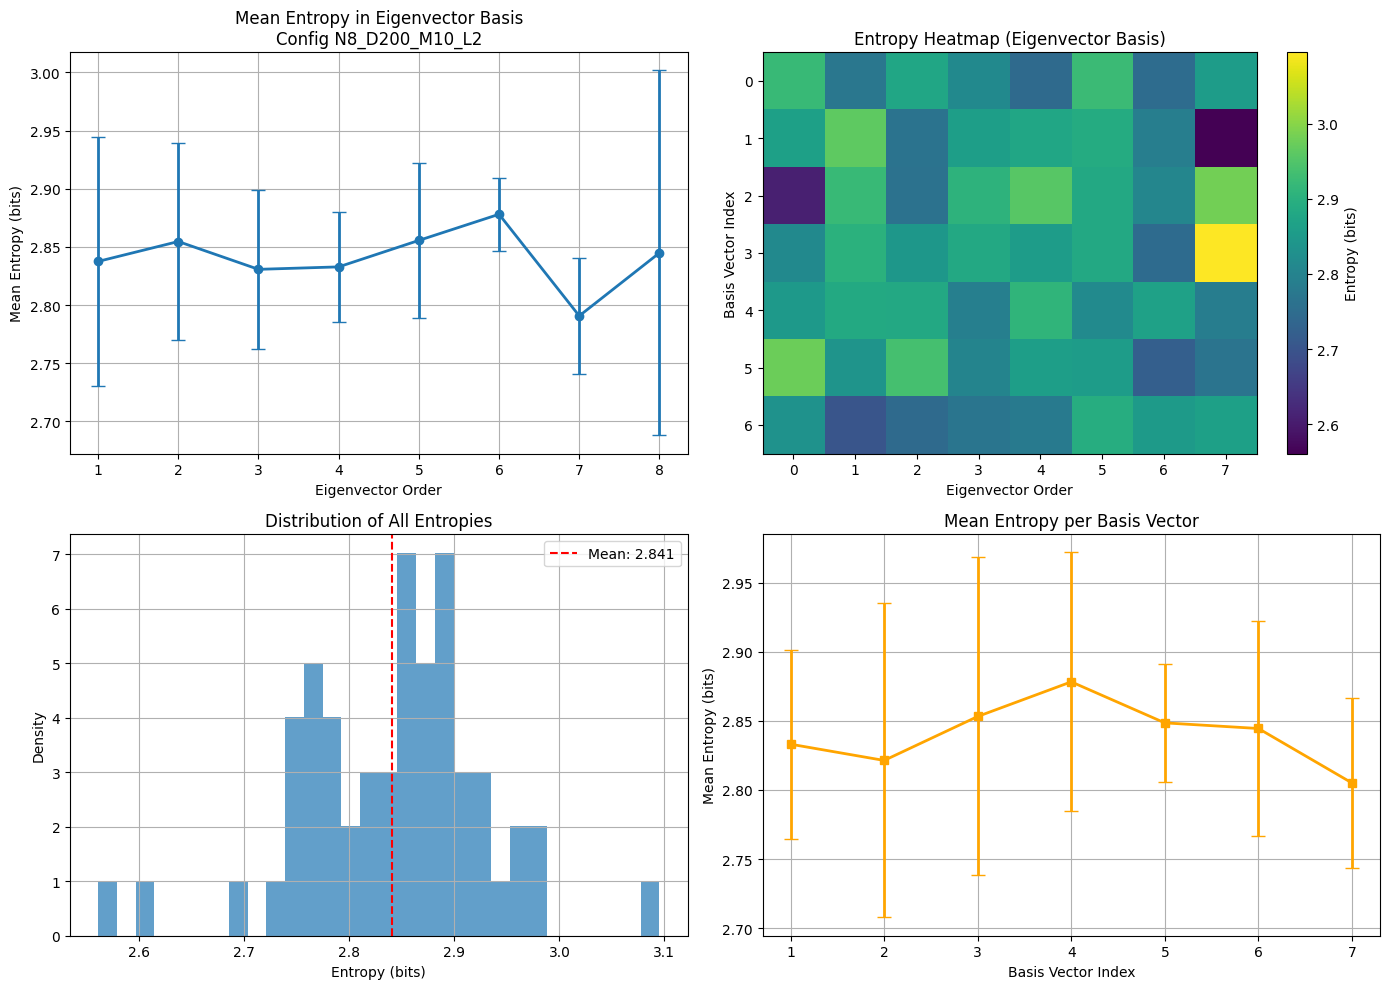

Processing experiment files:  12%|█▏        | 12/97 [01:49<12:42,  8.97s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8406 ± 0.0884 bits
  Max entropy: 3.0952 bits
  Min entropy: 2.5609 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.8781 ± 0.0316 bits

Least random eigenvector: 7th
  Mean entropy: 2.7907 ± 0.0501 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8406 bits
  Difference: -3.7887 bits


Computing entropy in eigenvector basis - N8_D20_M20_L6
Using first experiment as basis, analyzing 99 remaining experiments


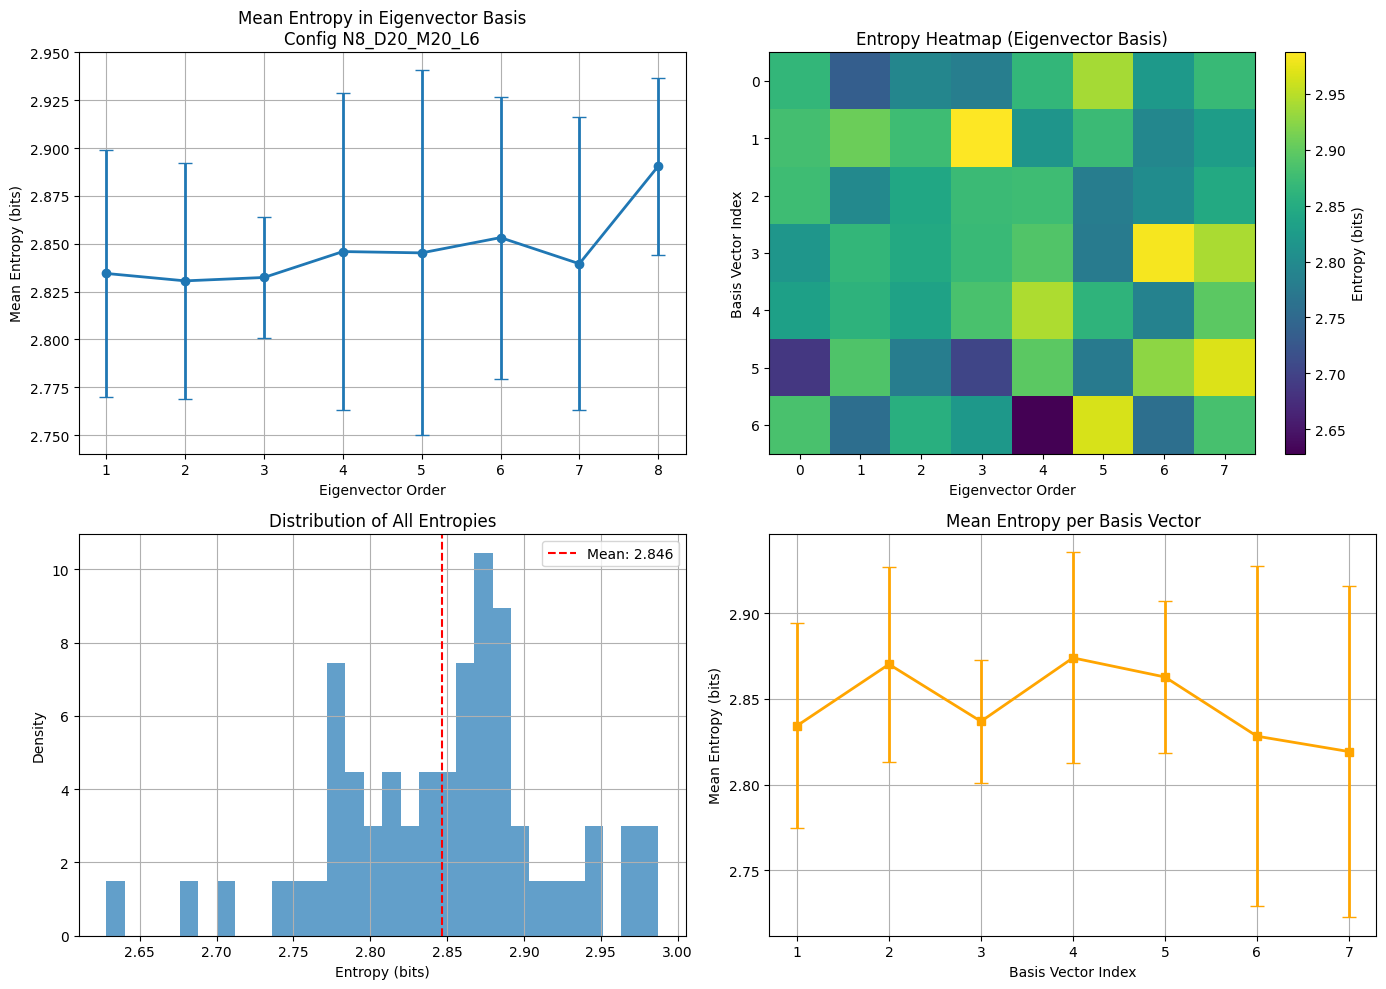

Processing experiment files:  13%|█▎        | 13/97 [01:58<12:39,  9.05s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8465 ± 0.0716 bits
  Max entropy: 2.9874 bits
  Min entropy: 2.6282 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8905 ± 0.0462 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8306 ± 0.0617 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8465 bits
  Difference: -3.7829 bits


Computing entropy in eigenvector basis - N8_D50_M50_L2
Using first experiment as basis, analyzing 99 remaining experiments


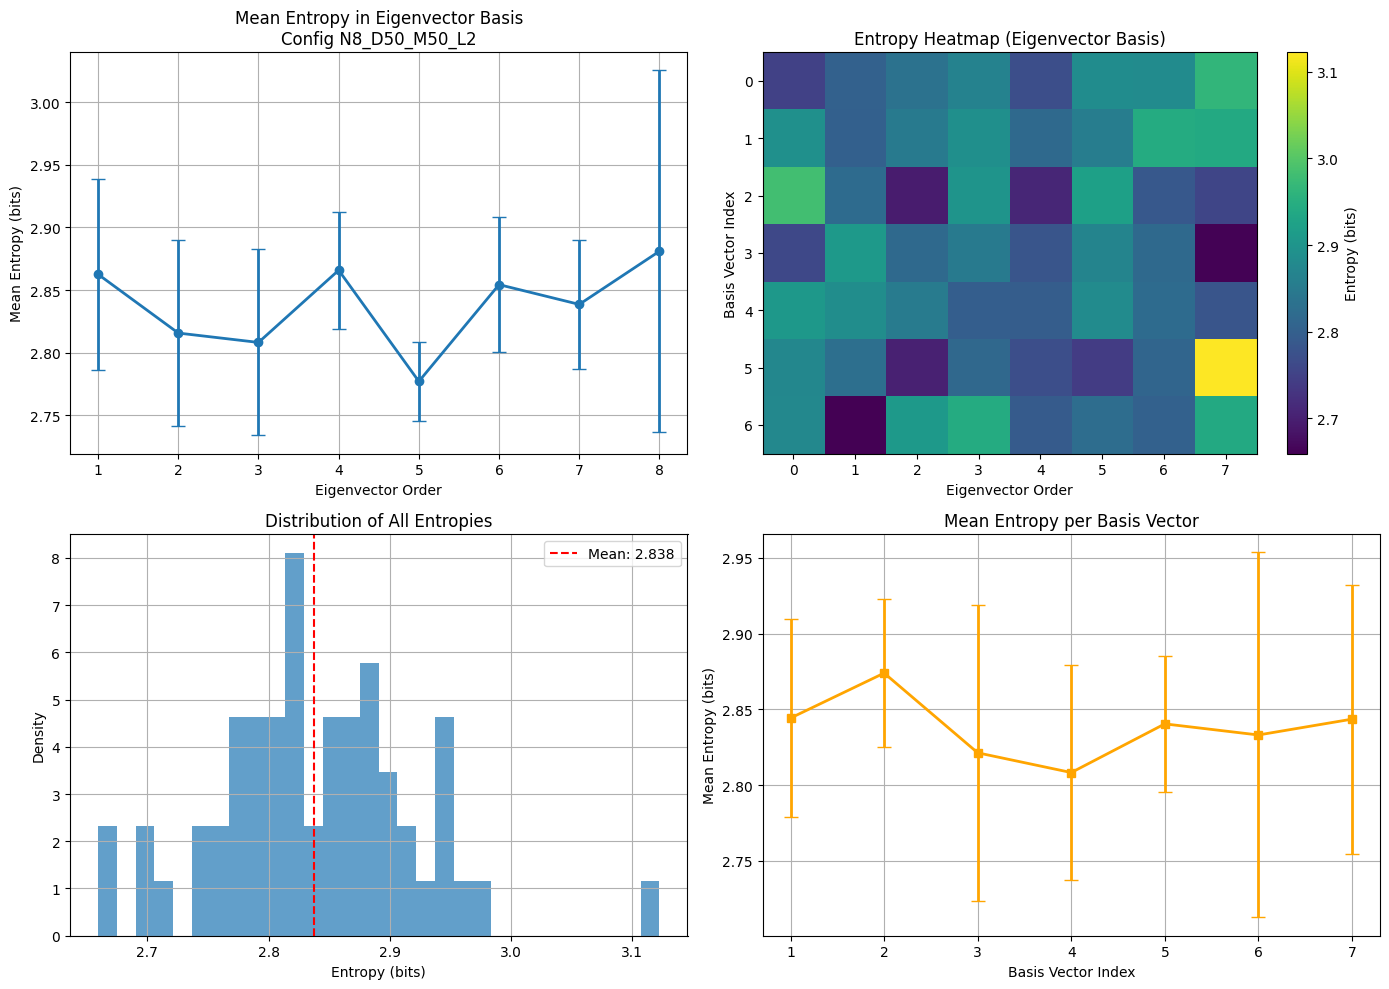

Processing experiment files:  14%|█▍        | 14/97 [02:07<12:32,  9.07s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8379 ± 0.0829 bits
  Max entropy: 3.1225 bits
  Min entropy: 2.6594 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8810 ± 0.1444 bits

Least random eigenvector: 5th
  Mean entropy: 2.7770 ± 0.0316 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8379 bits
  Difference: -3.7915 bits


Computing entropy in eigenvector basis - N8_D50_M50_L4
Using first experiment as basis, analyzing 99 remaining experiments


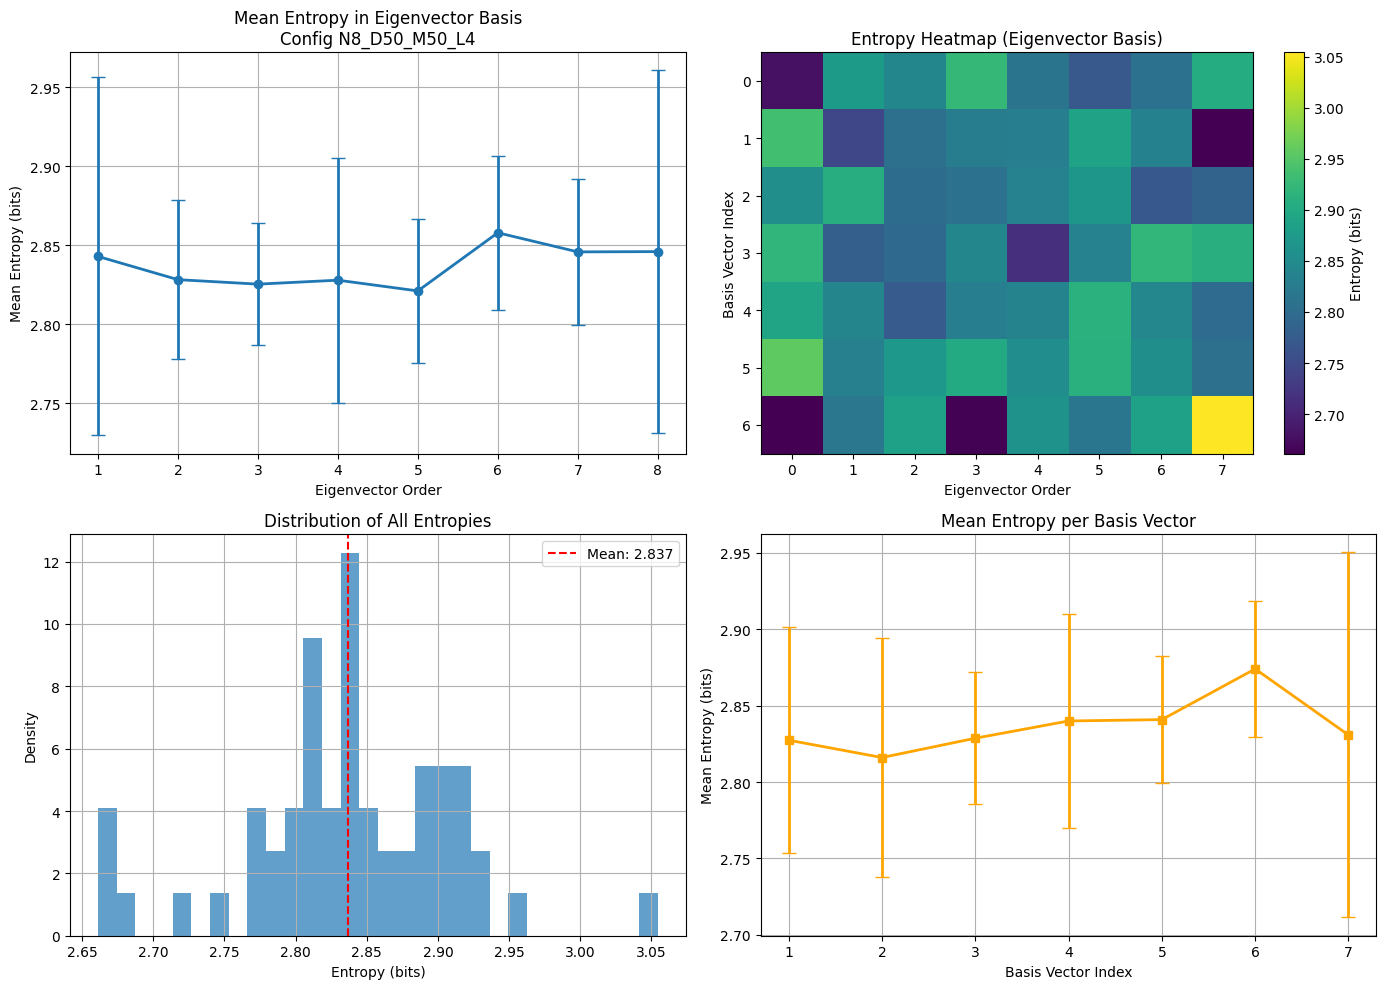

Processing experiment files:  15%|█▌        | 15/97 [02:15<12:05,  8.84s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8368 ± 0.0740 bits
  Max entropy: 3.0544 bits
  Min entropy: 2.6613 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.8578 ± 0.0487 bits

Least random eigenvector: 5th
  Mean entropy: 2.8210 ± 0.0455 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8368 bits
  Difference: -3.7926 bits


Computing entropy in eigenvector basis - N8_D100_M10_L6
Using first experiment as basis, analyzing 99 remaining experiments


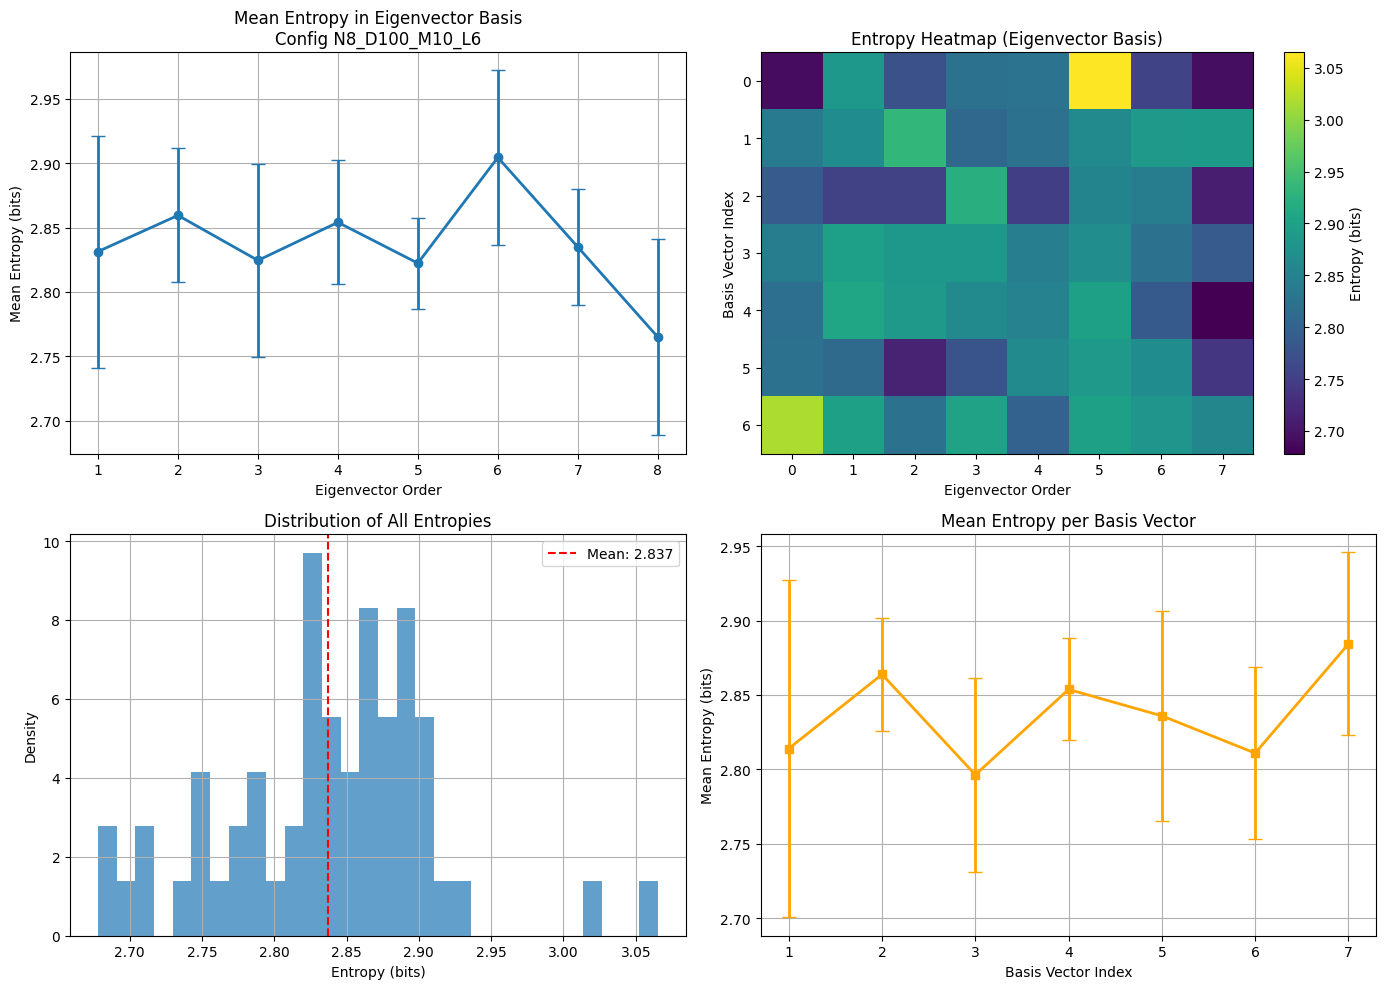

Processing experiment files:  16%|█▋        | 16/97 [02:25<12:20,  9.15s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8370 ± 0.0736 bits
  Max entropy: 3.0652 bits
  Min entropy: 2.6781 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.9044 ± 0.0676 bits

Least random eigenvector: 8th
  Mean entropy: 2.7650 ± 0.0764 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8370 bits
  Difference: -3.7924 bits


Computing entropy in eigenvector basis - N8_D50_M20_L6
Using first experiment as basis, analyzing 99 remaining experiments


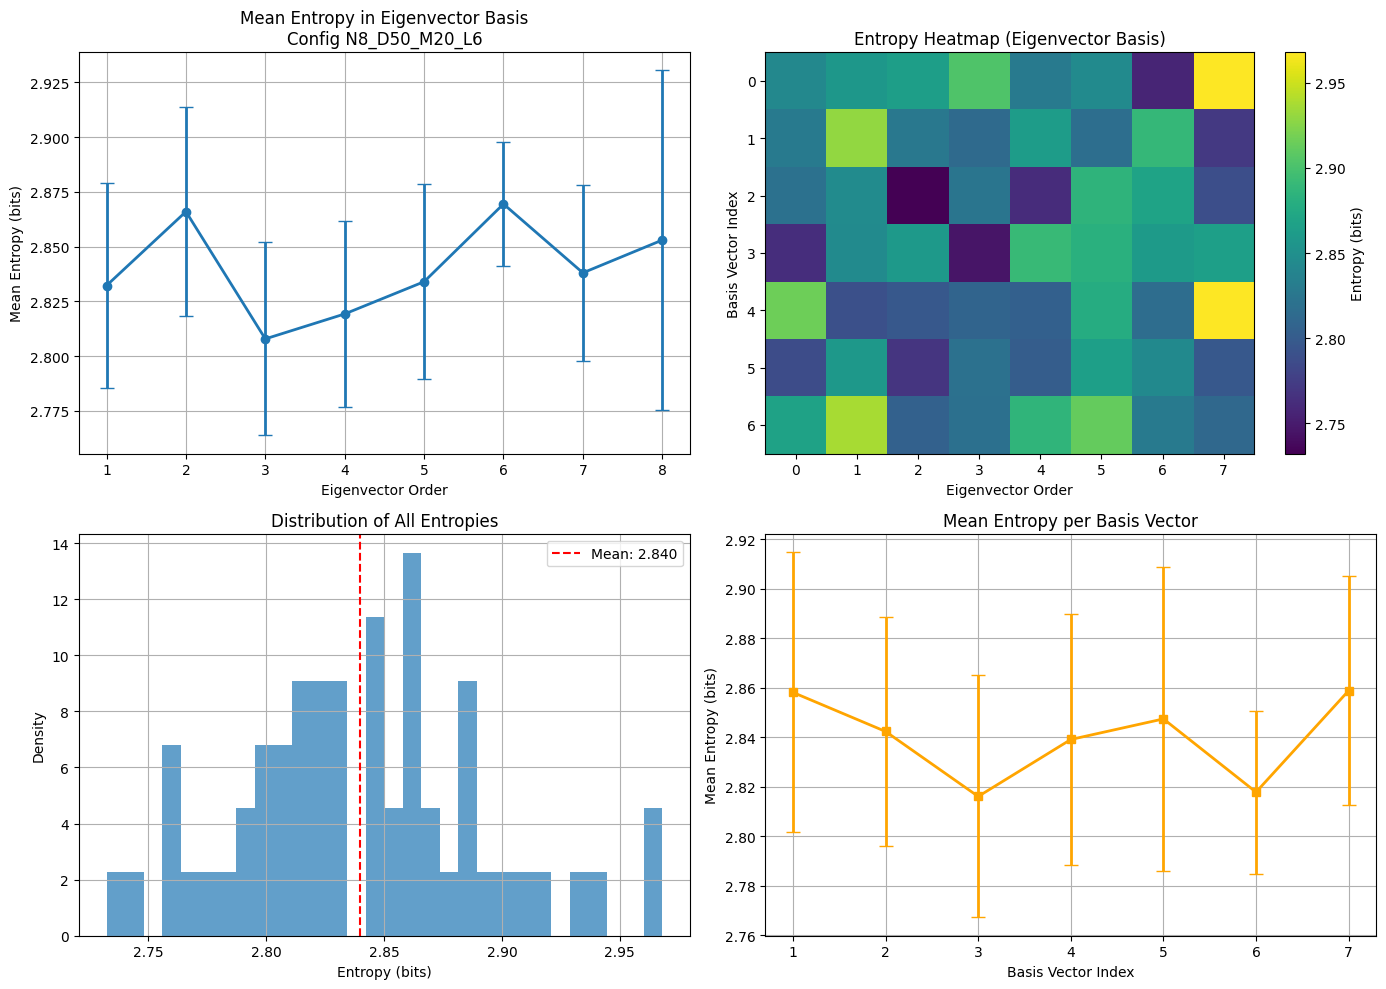

Processing experiment files:  18%|█▊        | 17/97 [02:35<12:28,  9.35s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8400 ± 0.0523 bits
  Max entropy: 2.9680 bits
  Min entropy: 2.7323 bits
  Number of basis vectors used: 7

Most random eigenvector: 6th
  Mean entropy: 2.8695 ± 0.0284 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8078 ± 0.0441 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8400 bits
  Difference: -3.7894 bits


Computing entropy in eigenvector basis - N8_D1000_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


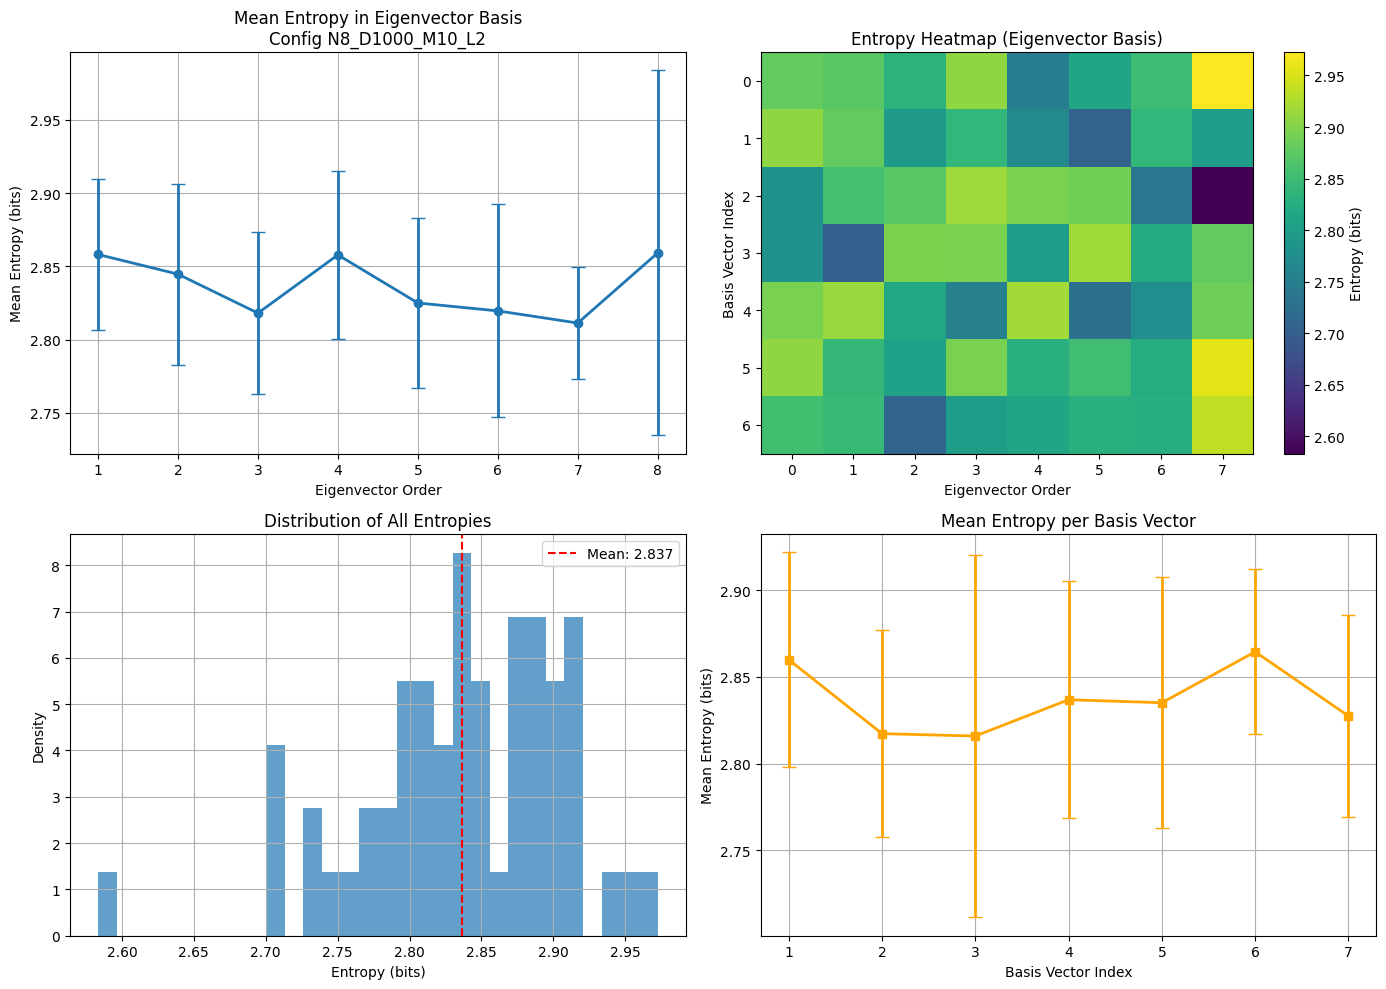

Processing experiment files:  19%|█▊        | 18/97 [02:43<11:52,  9.01s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8367 ± 0.0719 bits
  Max entropy: 2.9727 bits
  Min entropy: 2.5834 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8592 ± 0.1247 bits

Least random eigenvector: 7th
  Mean entropy: 2.8113 ± 0.0384 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8367 bits
  Difference: -3.7926 bits


Computing entropy in eigenvector basis - N8_D20_M50_L6
Using first experiment as basis, analyzing 99 remaining experiments


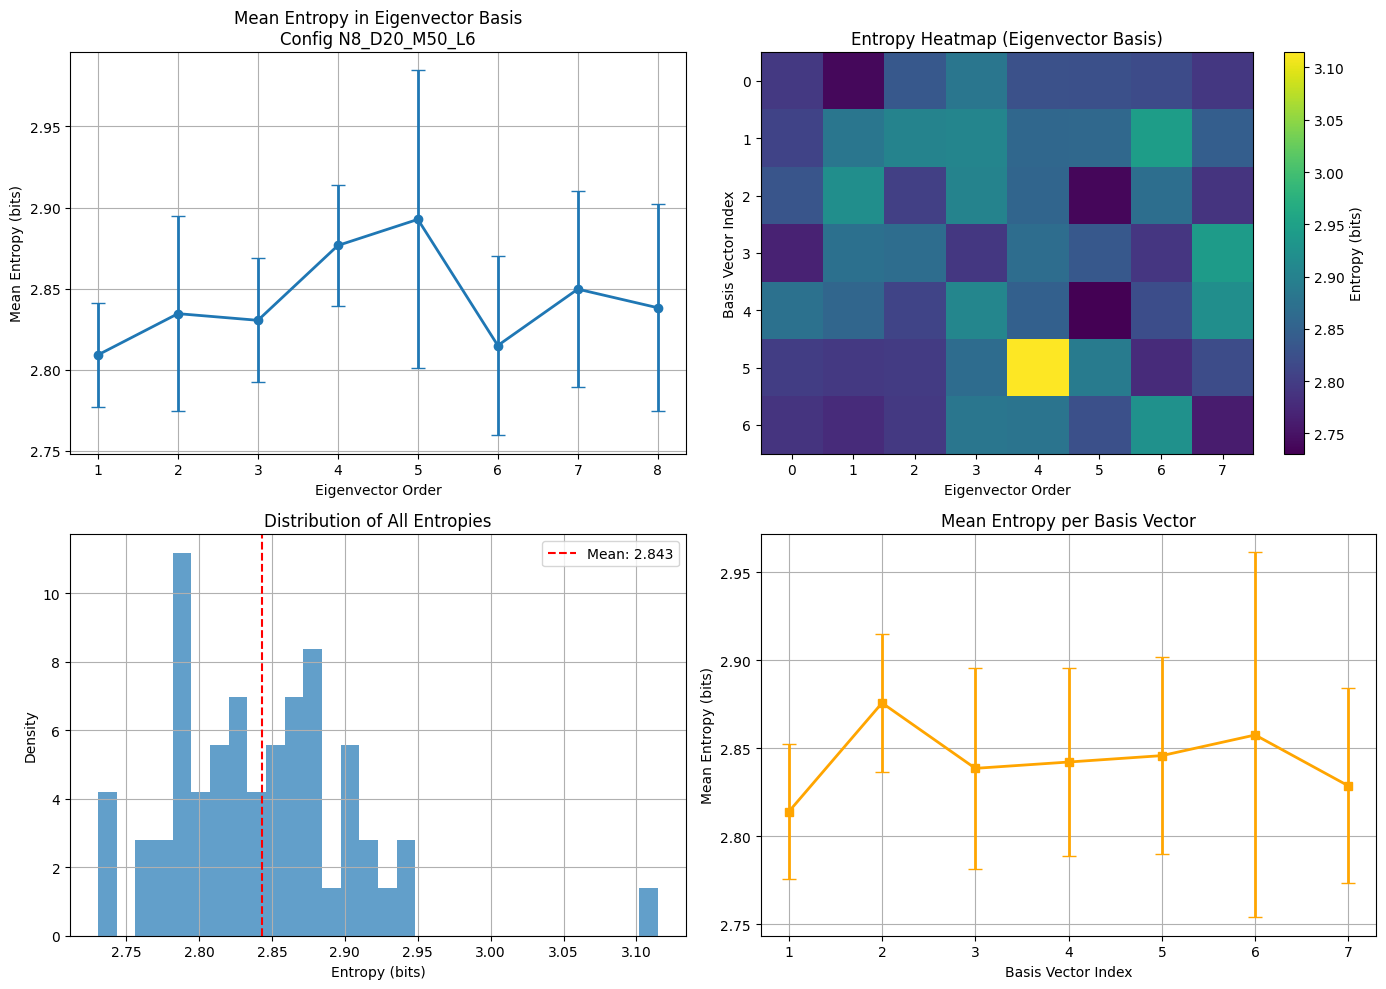

Processing experiment files:  20%|█▉        | 19/97 [02:51<11:22,  8.75s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8433 ± 0.0638 bits
  Max entropy: 3.1146 bits
  Min entropy: 2.7307 bits
  Number of basis vectors used: 7

Most random eigenvector: 5th
  Mean entropy: 2.8927 ± 0.0919 bits

Least random eigenvector: 1st
  Mean entropy: 2.8091 ± 0.0319 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8433 bits
  Difference: -3.7861 bits


Computing entropy in eigenvector basis - N8_D50_M20_L4
Using first experiment as basis, analyzing 99 remaining experiments


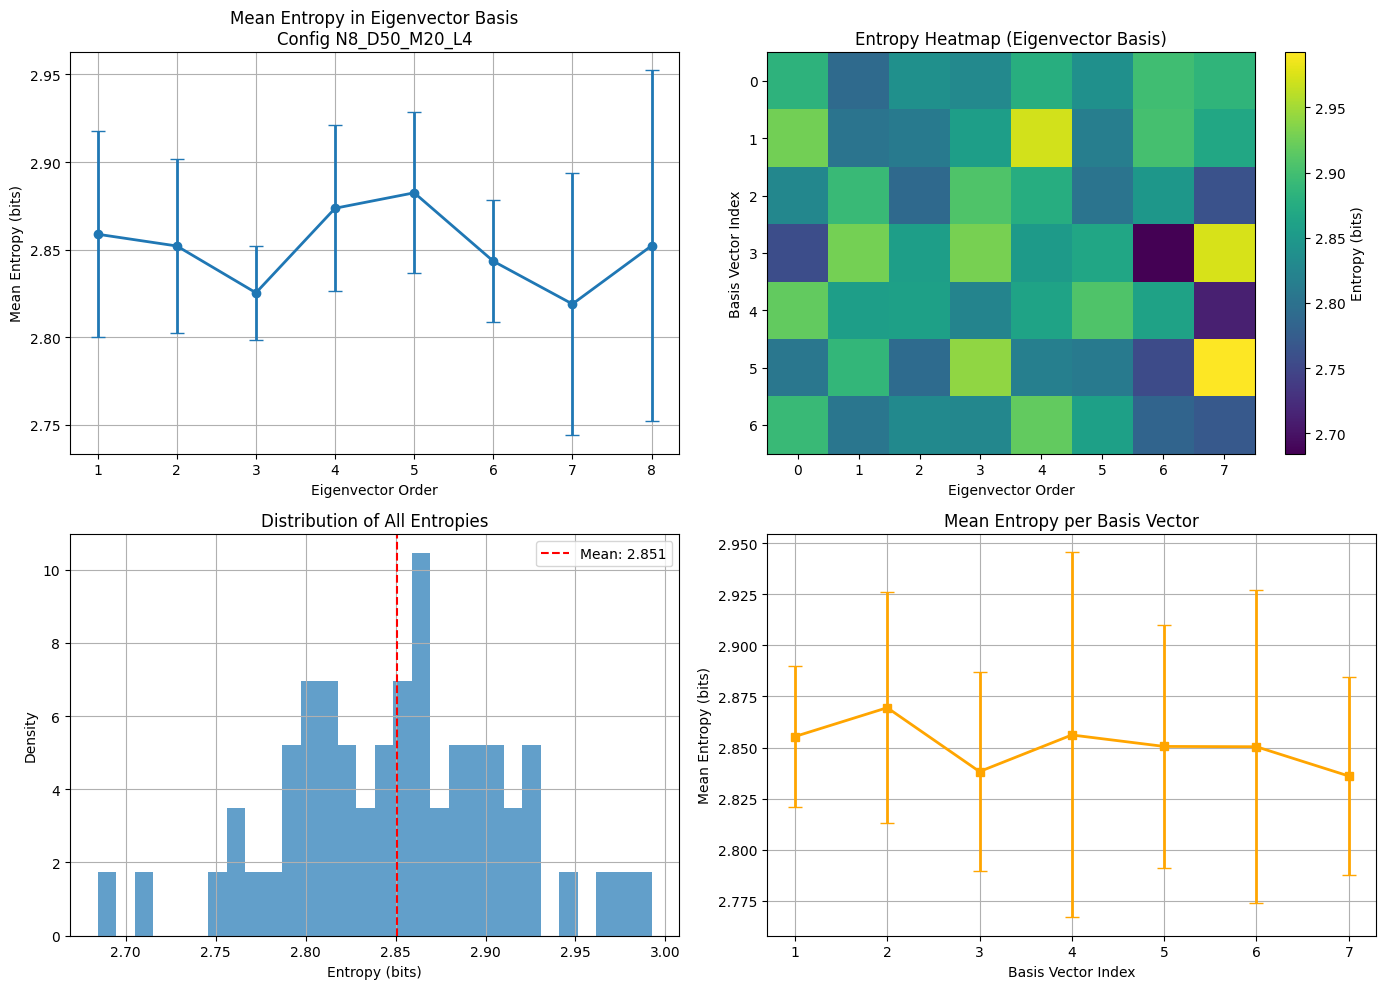

Processing experiment files:  21%|██        | 20/97 [03:01<11:23,  8.88s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8509 ± 0.0624 bits
  Max entropy: 2.9923 bits
  Min entropy: 2.6845 bits
  Number of basis vectors used: 7

Most random eigenvector: 5th
  Mean entropy: 2.8825 ± 0.0460 bits

Least random eigenvector: 7th
  Mean entropy: 2.8190 ± 0.0750 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8509 bits
  Difference: -3.7785 bits


Computing entropy in eigenvector basis - N8_D50_M200_L2
Using first experiment as basis, analyzing 99 remaining experiments


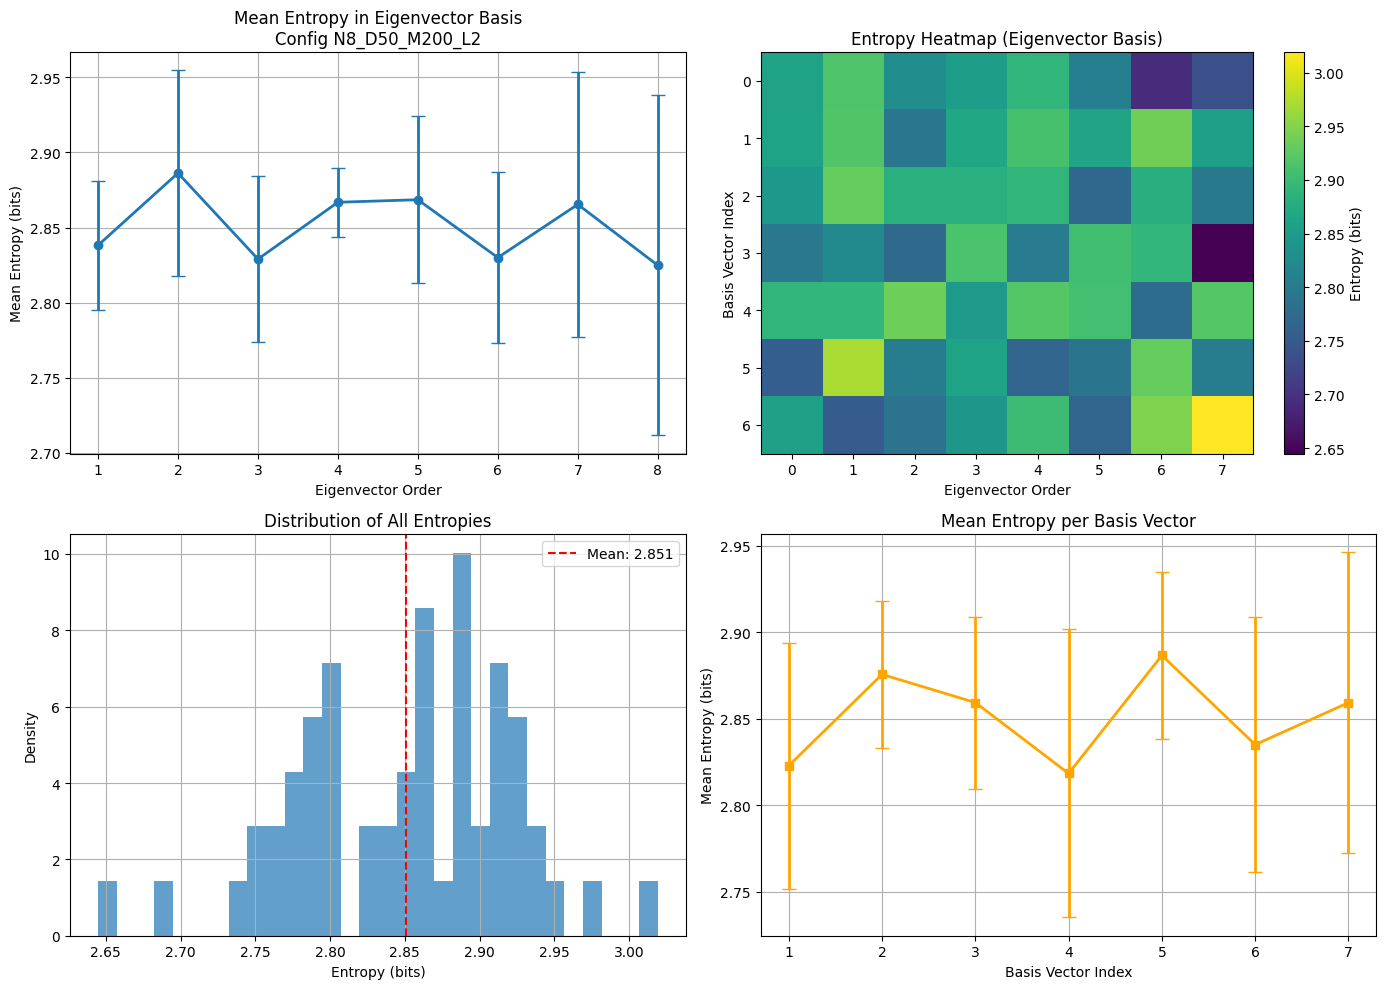

Processing experiment files:  22%|██▏       | 21/97 [03:08<10:45,  8.49s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8511 ± 0.0714 bits
  Max entropy: 3.0192 bits
  Min entropy: 2.6448 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.8862 ± 0.0683 bits

Least random eigenvector: 8th
  Mean entropy: 2.8249 ± 0.1132 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8511 bits
  Difference: -3.7782 bits


Computing entropy in eigenvector basis - N8_D500_M20_L2
Using first experiment as basis, analyzing 99 remaining experiments


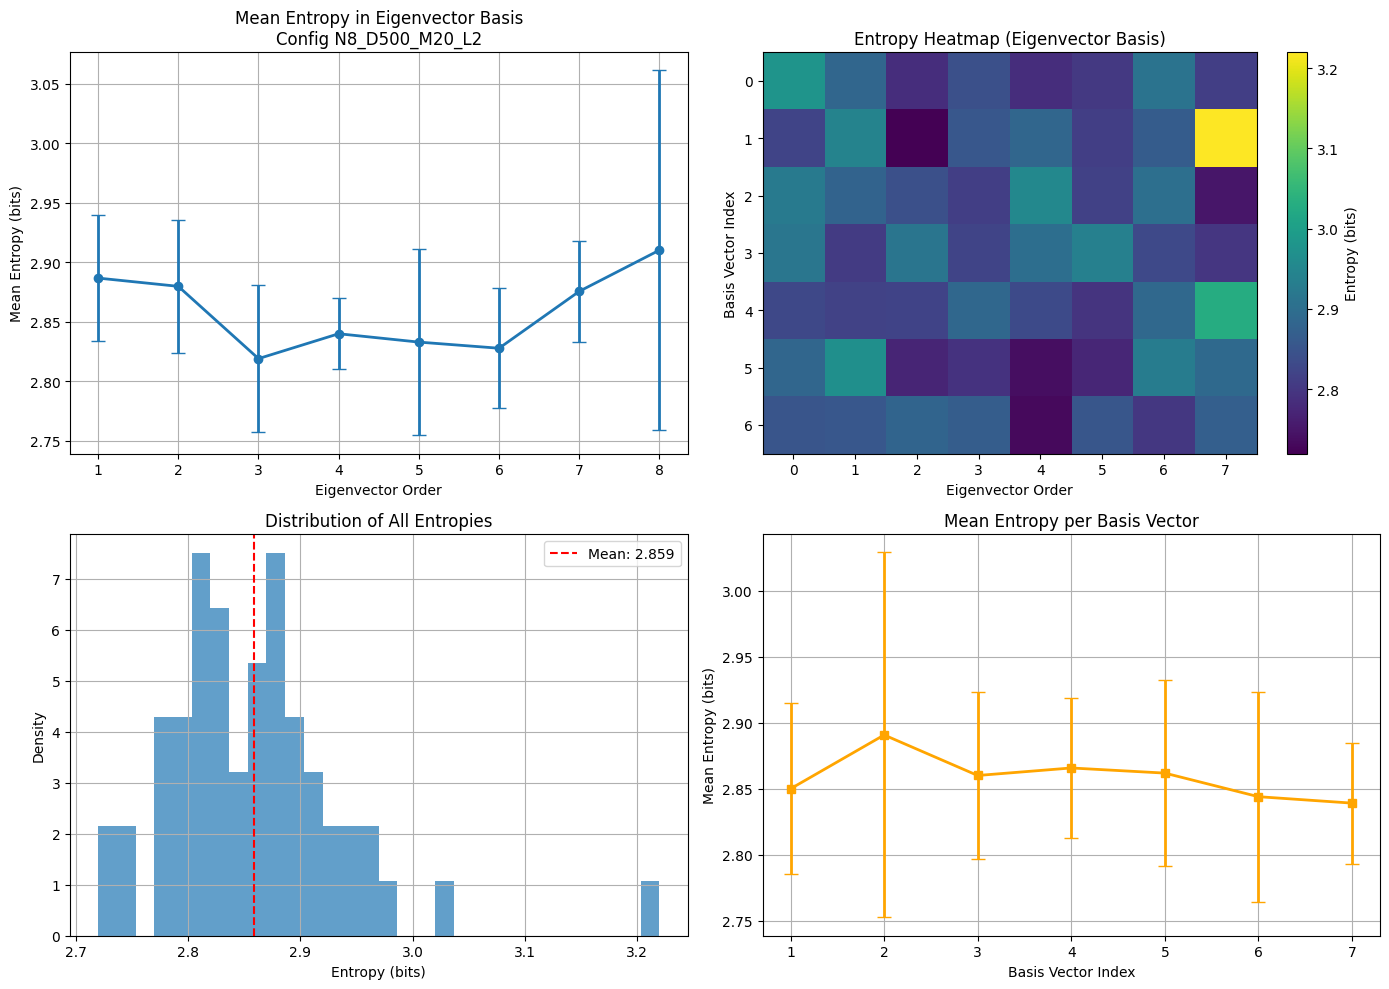

Processing experiment files:  23%|██▎       | 22/97 [03:15<10:08,  8.11s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8589 ± 0.0803 bits
  Max entropy: 3.2198 bits
  Min entropy: 2.7198 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9101 ± 0.1510 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8190 ± 0.0617 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8589 bits
  Difference: -3.7704 bits


Computing entropy in eigenvector basis - N8_D50_M10_L8
Using first experiment as basis, analyzing 99 remaining experiments


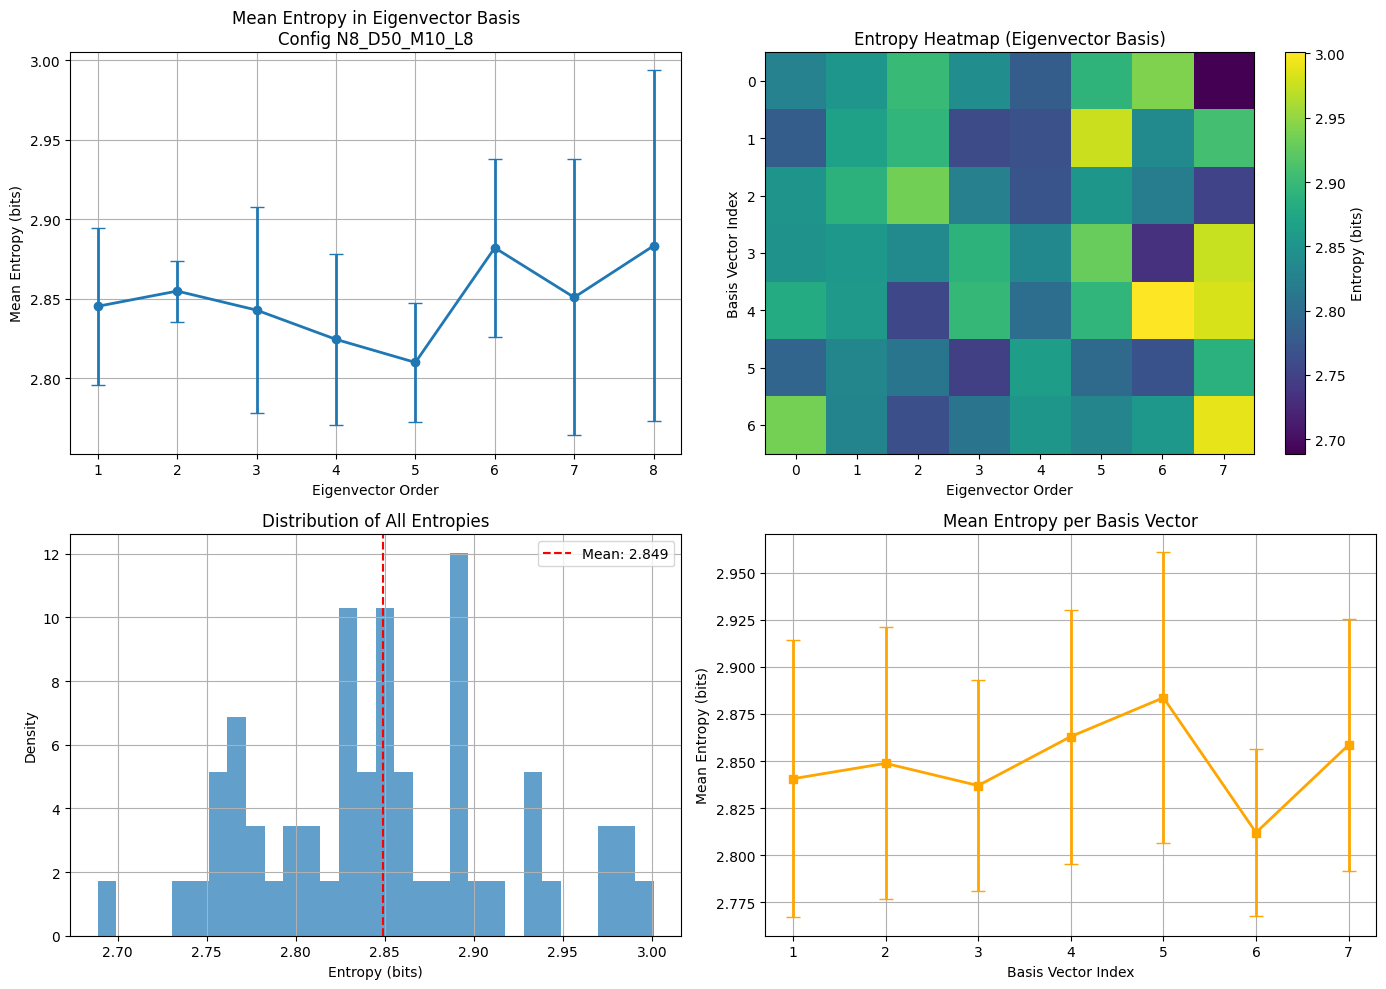

Processing experiment files:  24%|██▎       | 23/97 [03:23<09:59,  8.11s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8491 ± 0.0694 bits
  Max entropy: 3.0010 bits
  Min entropy: 2.6889 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8832 ± 0.1103 bits

Least random eigenvector: 5th
  Mean entropy: 2.8099 ± 0.0374 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8491 bits
  Difference: -3.7802 bits


Computing entropy in eigenvector basis - N8_D200_M20_L2
Using first experiment as basis, analyzing 99 remaining experiments


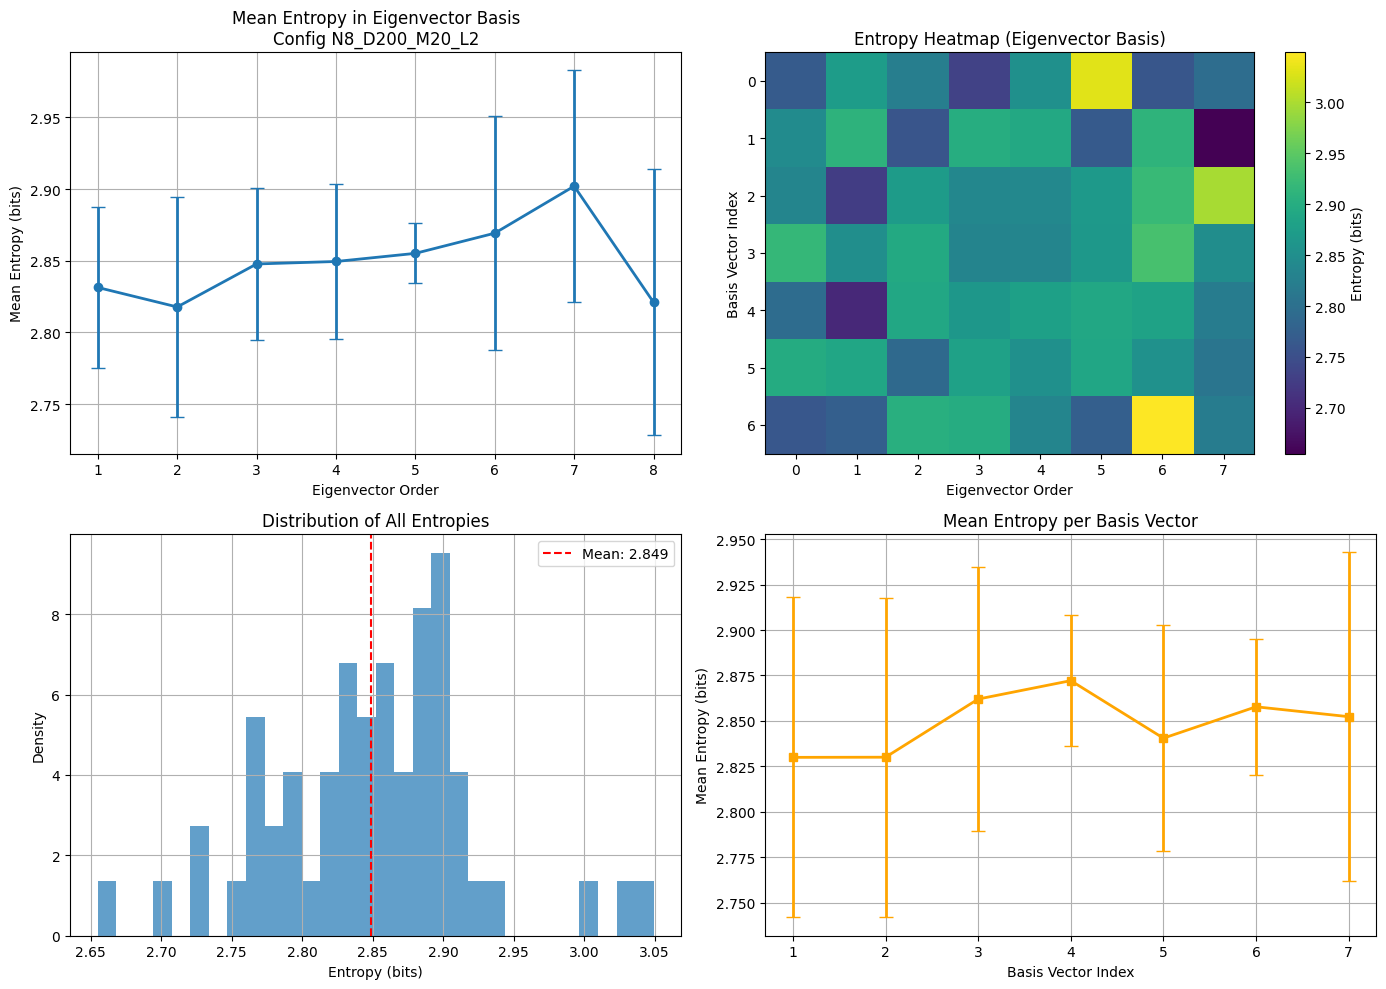

Processing experiment files:  25%|██▍       | 24/97 [03:32<09:55,  8.15s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8492 ± 0.0728 bits
  Max entropy: 3.0492 bits
  Min entropy: 2.6552 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.9020 ± 0.0807 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8178 ± 0.0769 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8492 bits
  Difference: -3.7801 bits


Computing entropy in eigenvector basis - N8_D20_M50_L2
Using first experiment as basis, analyzing 99 remaining experiments


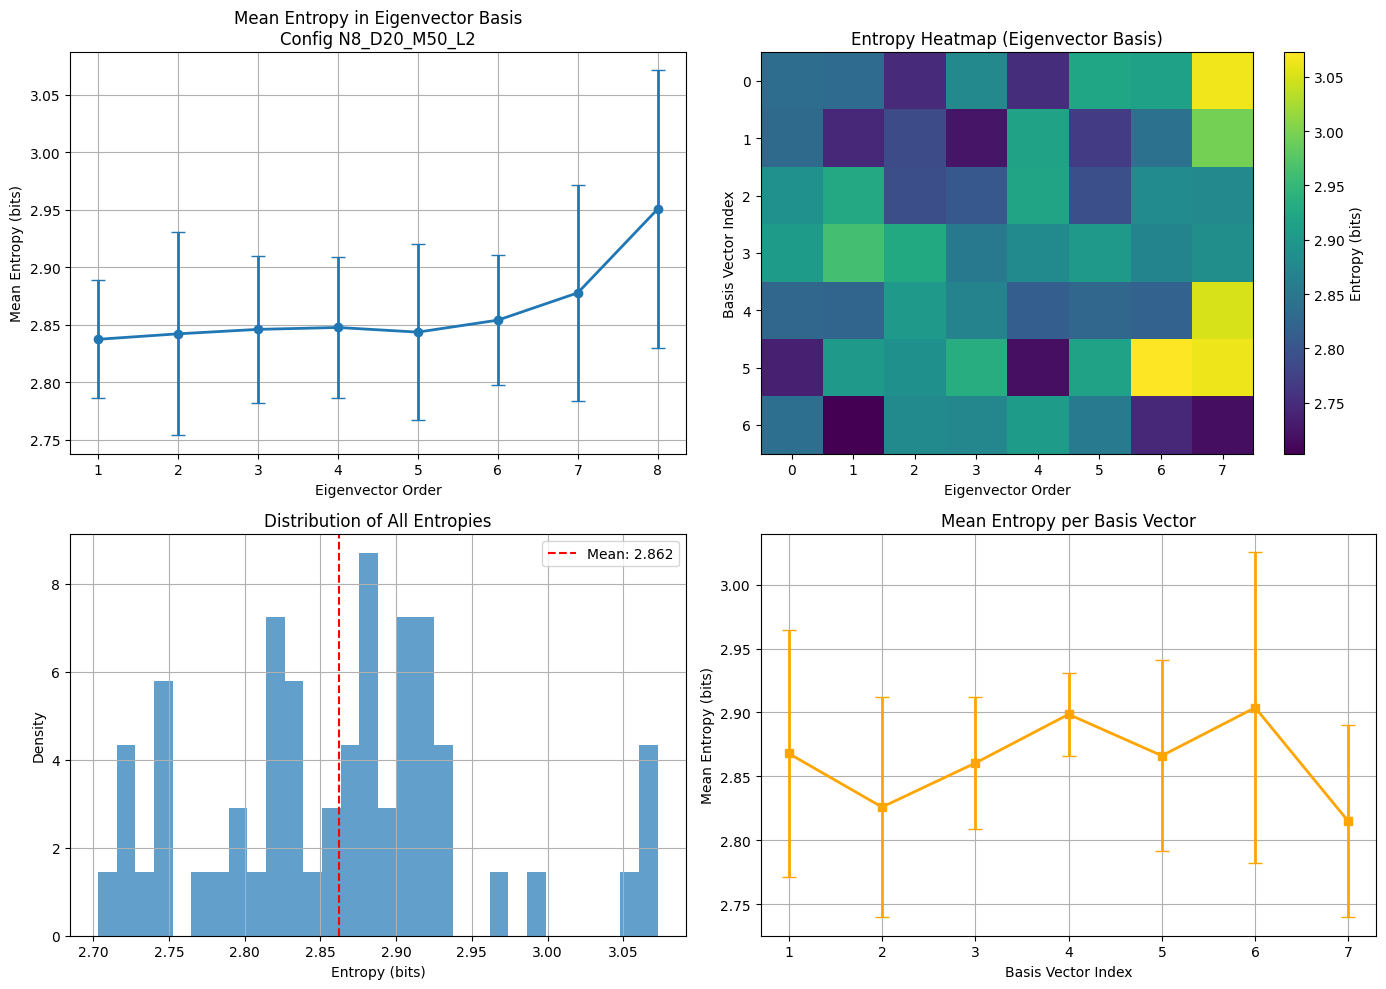

Processing experiment files:  26%|██▌       | 25/97 [03:40<09:47,  8.16s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8624 ± 0.0871 bits
  Max entropy: 3.0728 bits
  Min entropy: 2.7031 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9507 ± 0.1205 bits

Least random eigenvector: 1st
  Mean entropy: 2.8374 ± 0.0512 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8624 bits
  Difference: -3.7669 bits


Computing entropy in eigenvector basis - N8_D20_M100_L2
Using first experiment as basis, analyzing 99 remaining experiments


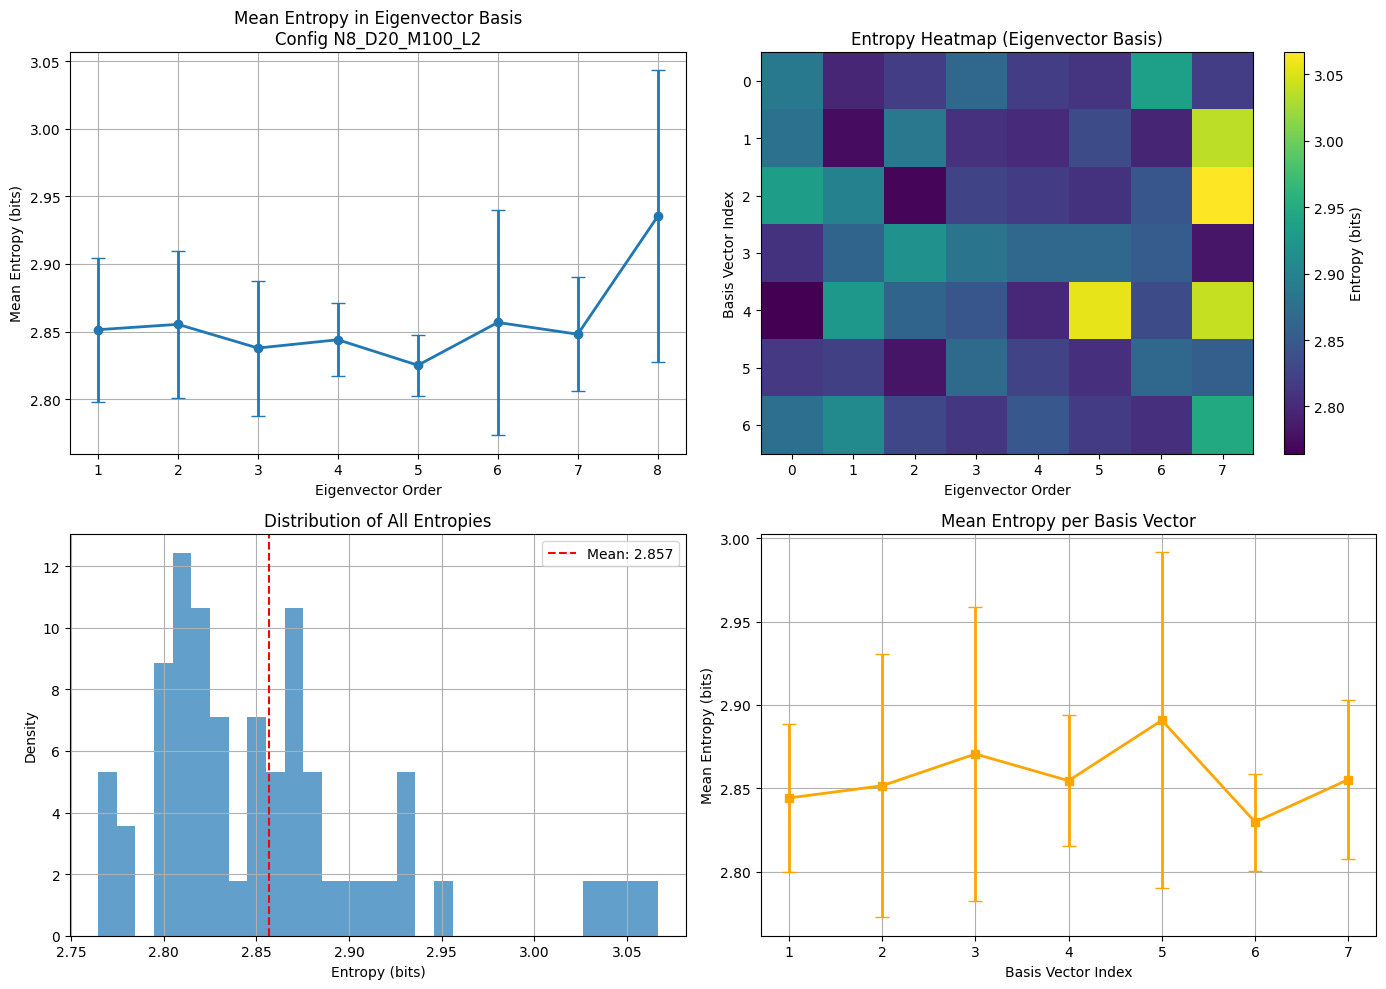

Processing experiment files:  27%|██▋       | 26/97 [03:47<09:22,  7.93s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8567 ± 0.0687 bits
  Max entropy: 3.0666 bits
  Min entropy: 2.7645 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9353 ± 0.1080 bits

Least random eigenvector: 5th
  Mean entropy: 2.8251 ± 0.0224 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8567 bits
  Difference: -3.7727 bits


Computing entropy in eigenvector basis - N8_D50_M10_L10
Using first experiment as basis, analyzing 99 remaining experiments


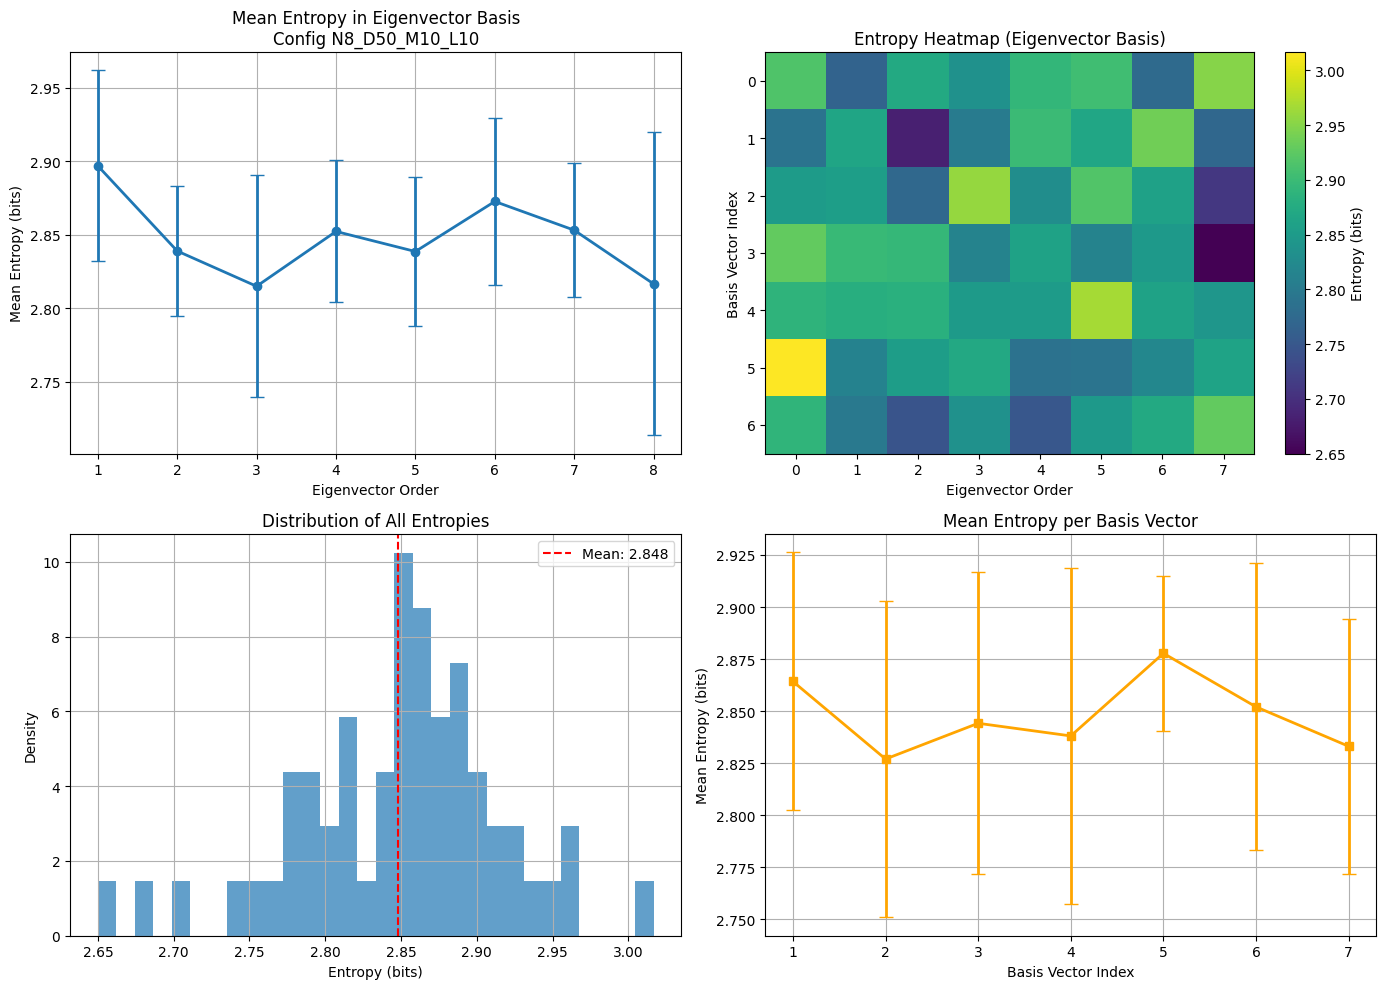

Processing experiment files:  28%|██▊       | 27/97 [03:55<09:18,  7.97s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8481 ± 0.0689 bits
  Max entropy: 3.0167 bits
  Min entropy: 2.6499 bits
  Number of basis vectors used: 7

Most random eigenvector: 1st
  Mean entropy: 2.8969 ± 0.0649 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8150 ± 0.0755 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8481 bits
  Difference: -3.7813 bits


Computing entropy in eigenvector basis - N8_D100_M50_L4
Using first experiment as basis, analyzing 99 remaining experiments


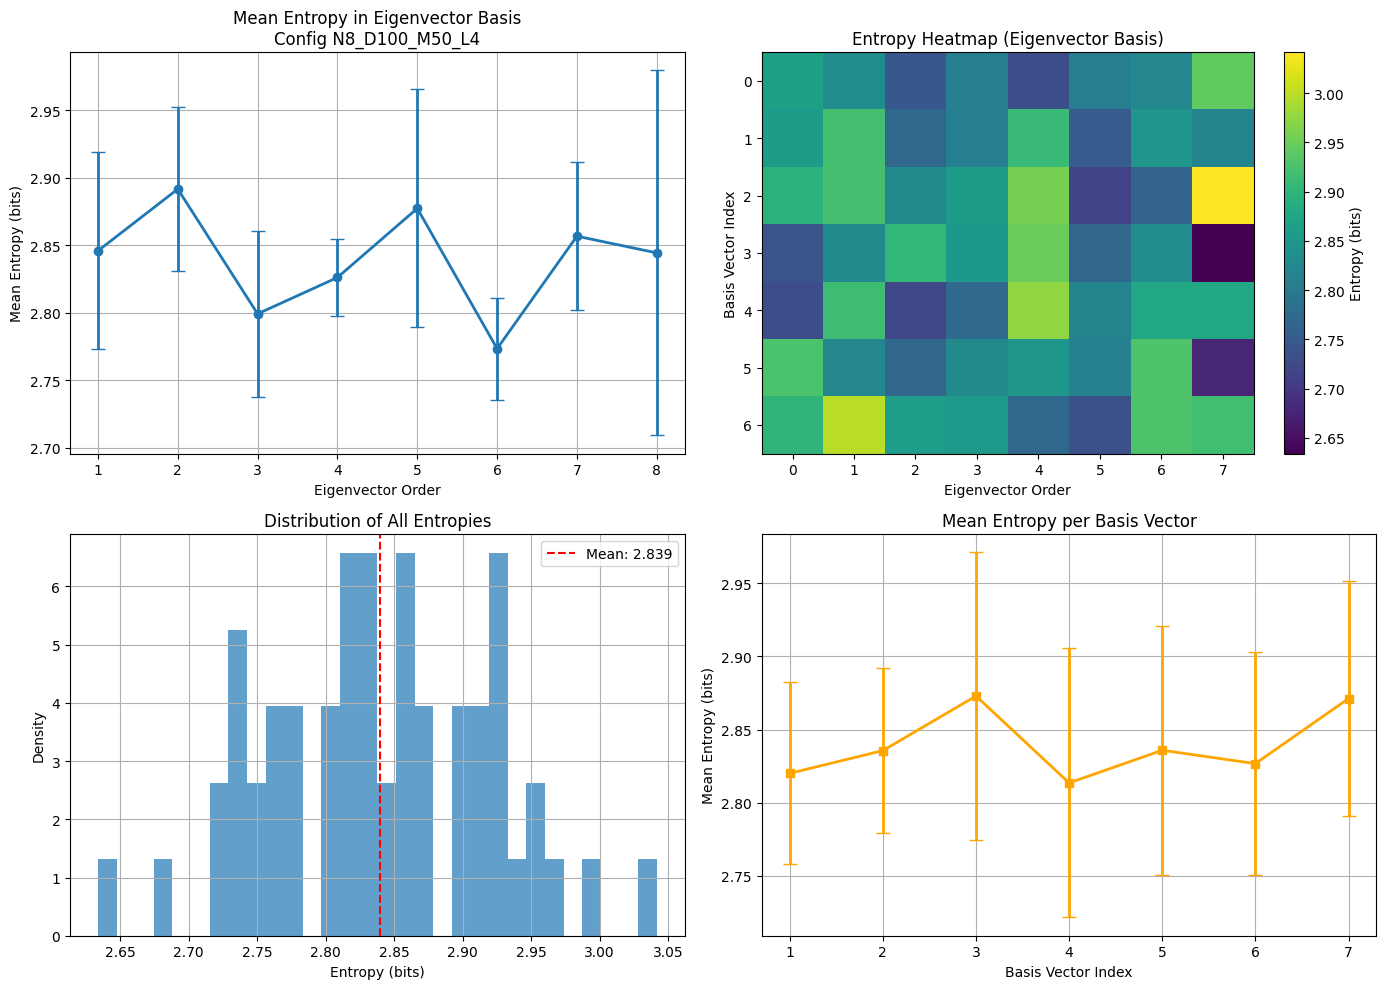

Processing experiment files:  29%|██▉       | 28/97 [04:04<09:17,  8.08s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8394 ± 0.0828 bits
  Max entropy: 3.0417 bits
  Min entropy: 2.6339 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.8917 ± 0.0609 bits

Least random eigenvector: 6th
  Mean entropy: 2.7735 ± 0.0377 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8394 bits
  Difference: -3.7900 bits


Computing entropy in eigenvector basis - N8_D20_M10_L12
Using first experiment as basis, analyzing 99 remaining experiments


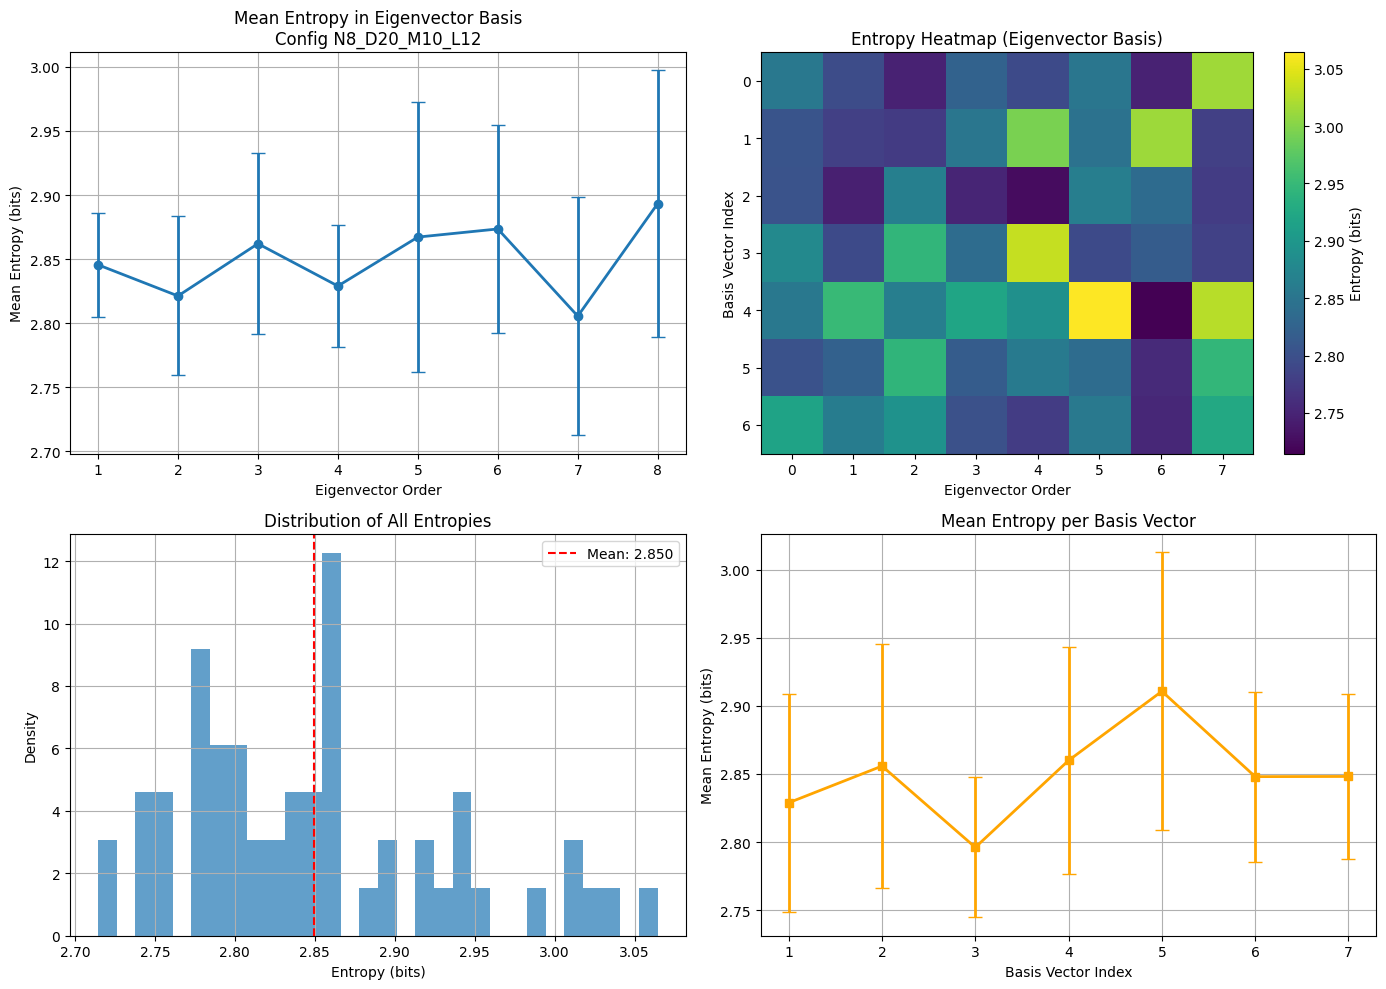

Processing experiment files:  30%|██▉       | 29/97 [04:11<09:03,  8.00s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8496 ± 0.0837 bits
  Max entropy: 3.0644 bits
  Min entropy: 2.7145 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8933 ± 0.1040 bits

Least random eigenvector: 7th
  Mean entropy: 2.8054 ± 0.0931 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8496 bits
  Difference: -3.7797 bits


Computing entropy in eigenvector basis - N8_D20_M200_L2
Using first experiment as basis, analyzing 99 remaining experiments


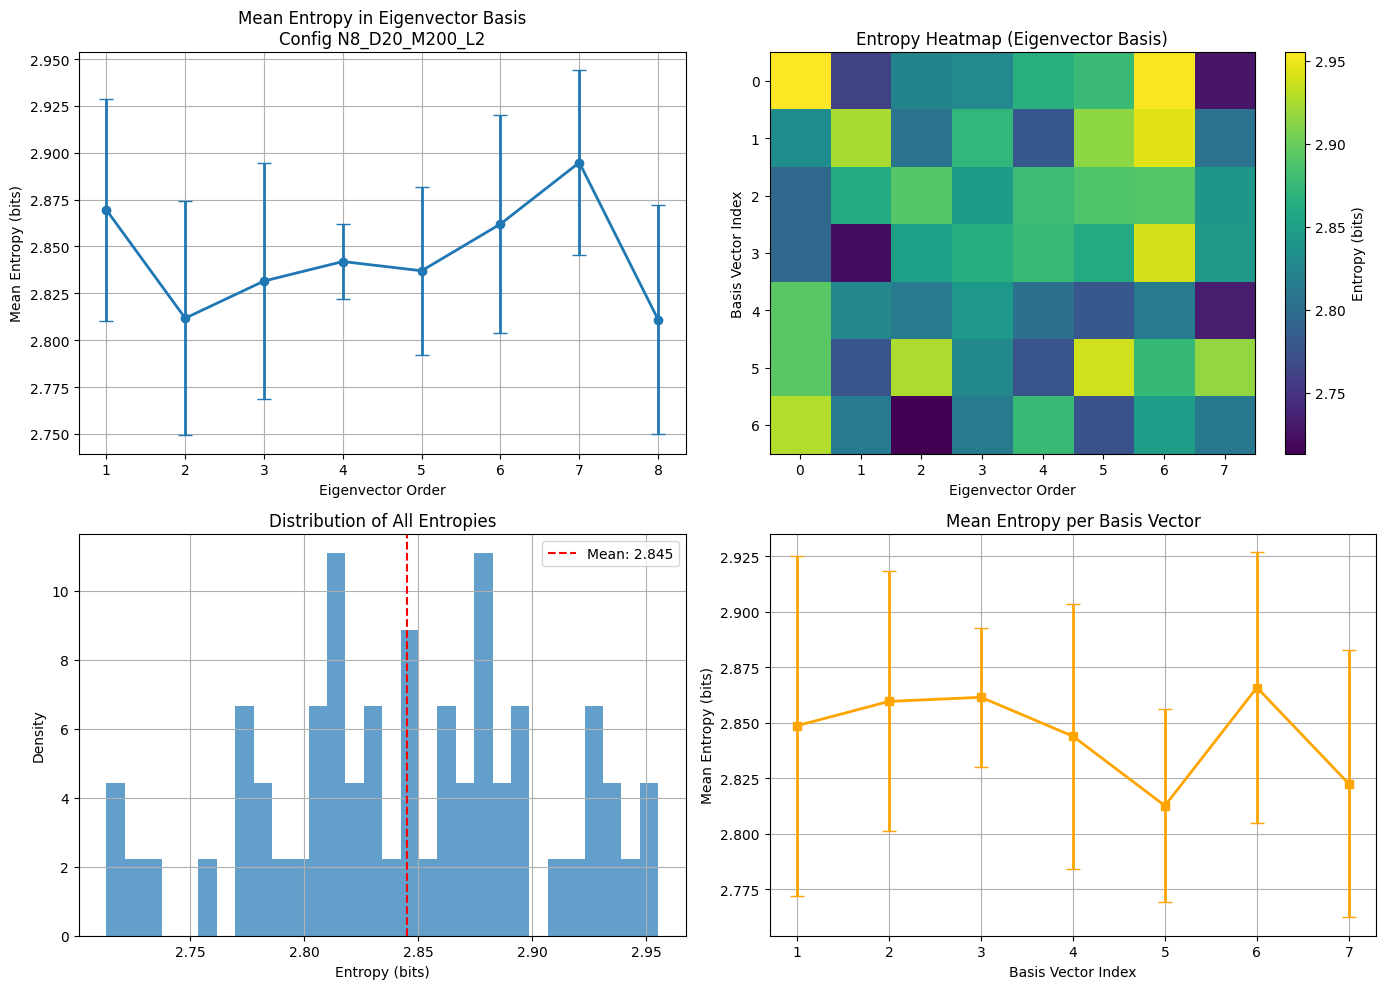

Processing experiment files:  31%|███       | 30/97 [04:19<08:40,  7.78s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8450 ± 0.0605 bits
  Max entropy: 2.9551 bits
  Min entropy: 2.7134 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.8948 ± 0.0492 bits

Least random eigenvector: 8th
  Mean entropy: 2.8110 ± 0.0610 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8450 bits
  Difference: -3.7844 bits


Computing entropy in eigenvector basis - N8_D20_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


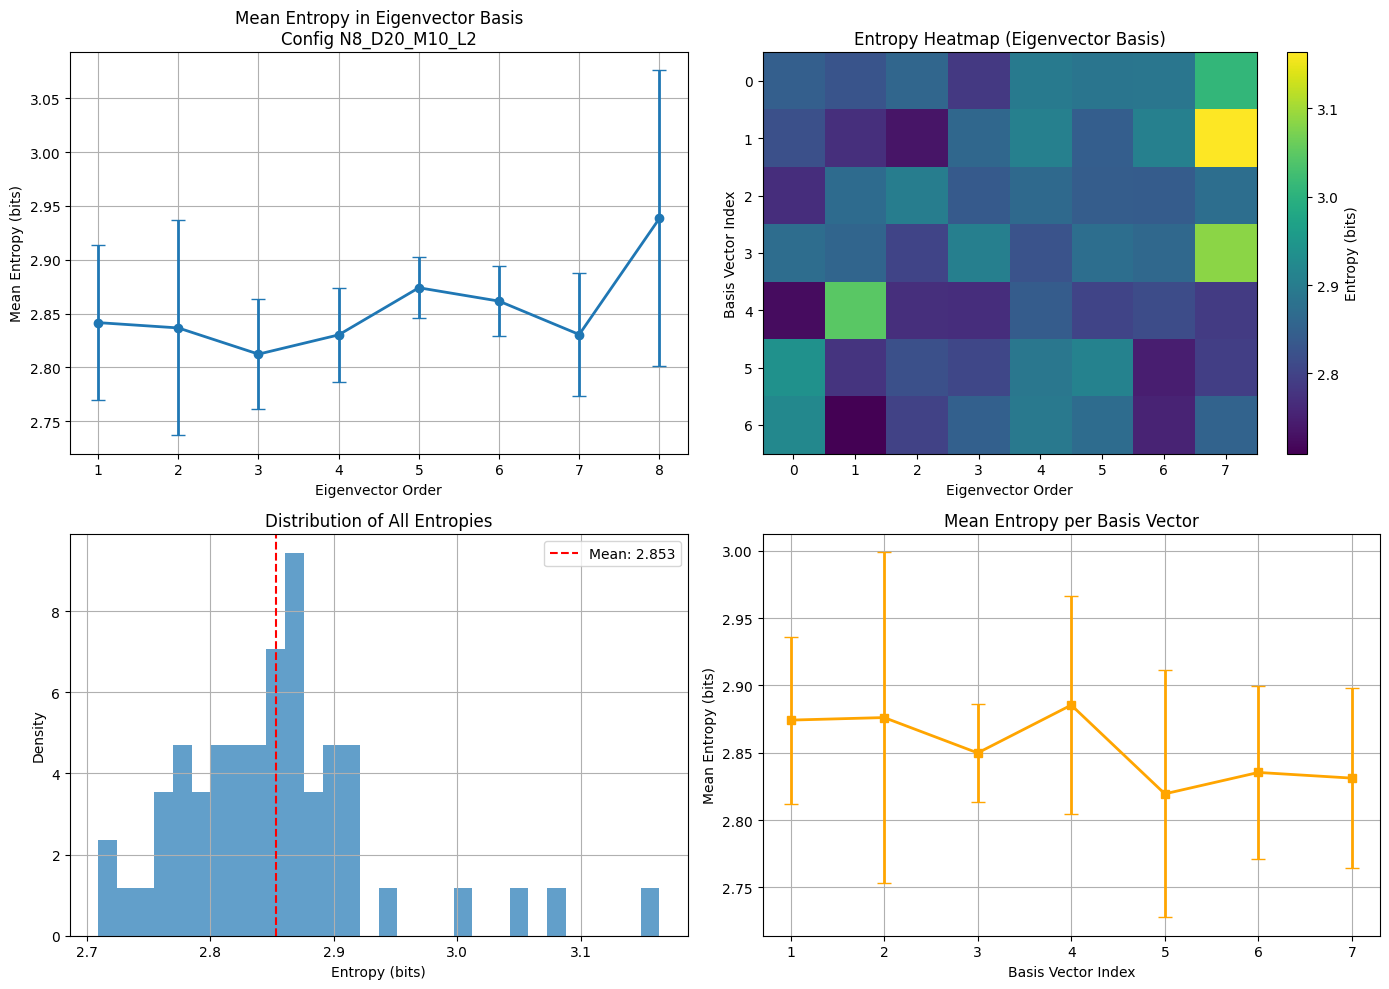

Processing experiment files:  32%|███▏      | 31/97 [04:27<08:39,  7.87s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8531 ± 0.0827 bits
  Max entropy: 3.1638 bits
  Min entropy: 2.7091 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9384 ± 0.1375 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8122 ± 0.0512 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8531 bits
  Difference: -3.7763 bits


Computing entropy in eigenvector basis - N8_D100_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


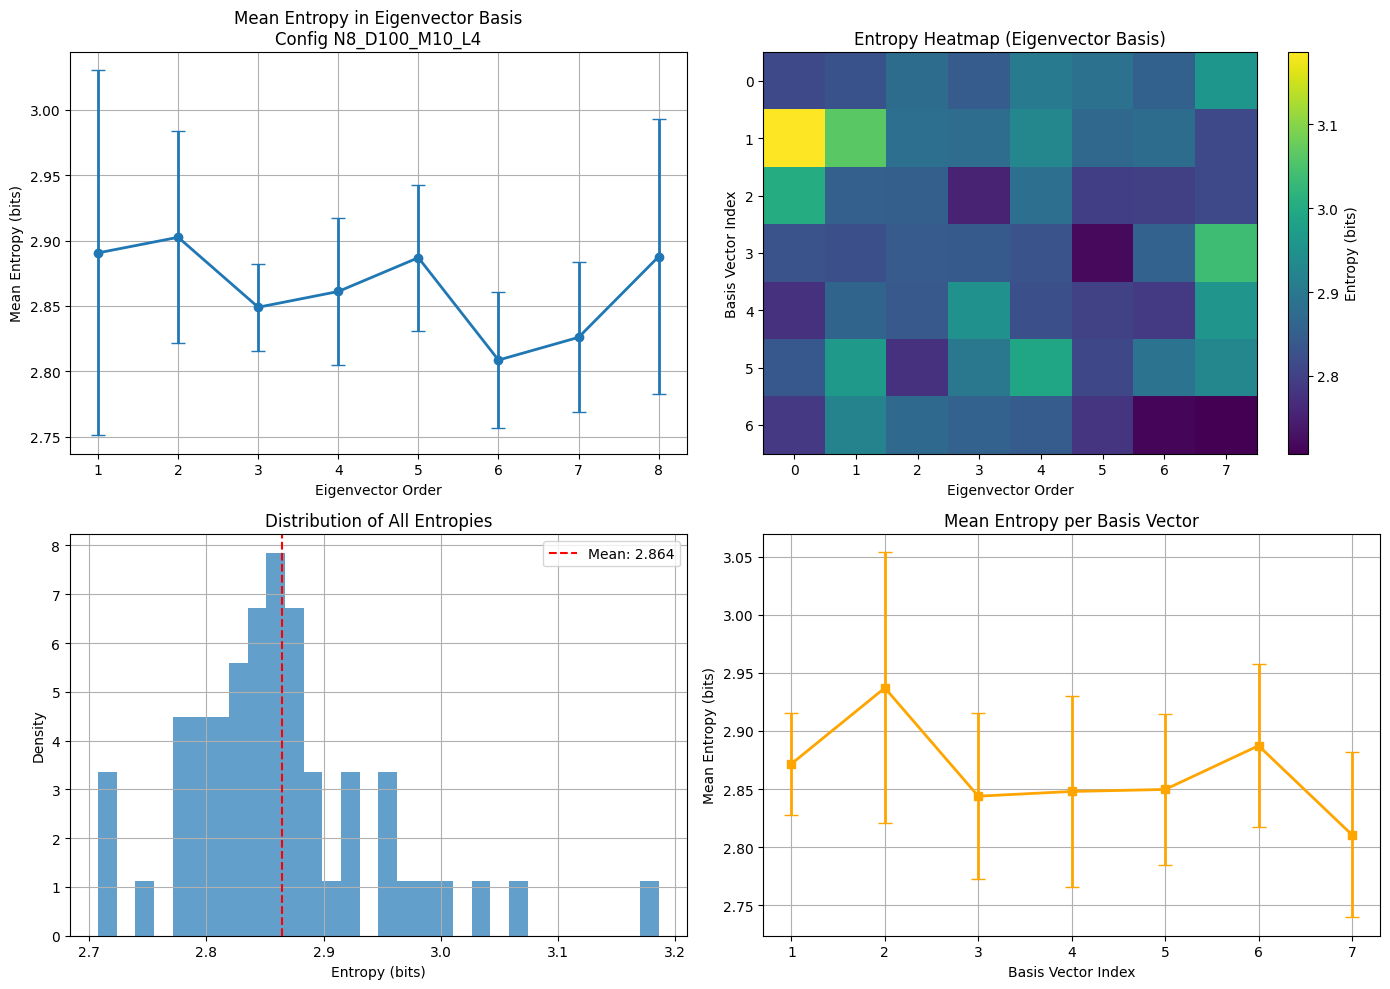

Processing experiment files:  33%|███▎      | 32/97 [04:35<08:32,  7.89s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8641 ± 0.0855 bits
  Max entropy: 3.1859 bits
  Min entropy: 2.7075 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.9025 ± 0.0810 bits

Least random eigenvector: 6th
  Mean entropy: 2.8086 ± 0.0517 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8641 bits
  Difference: -3.7653 bits


Computing entropy in eigenvector basis - N8_D50_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


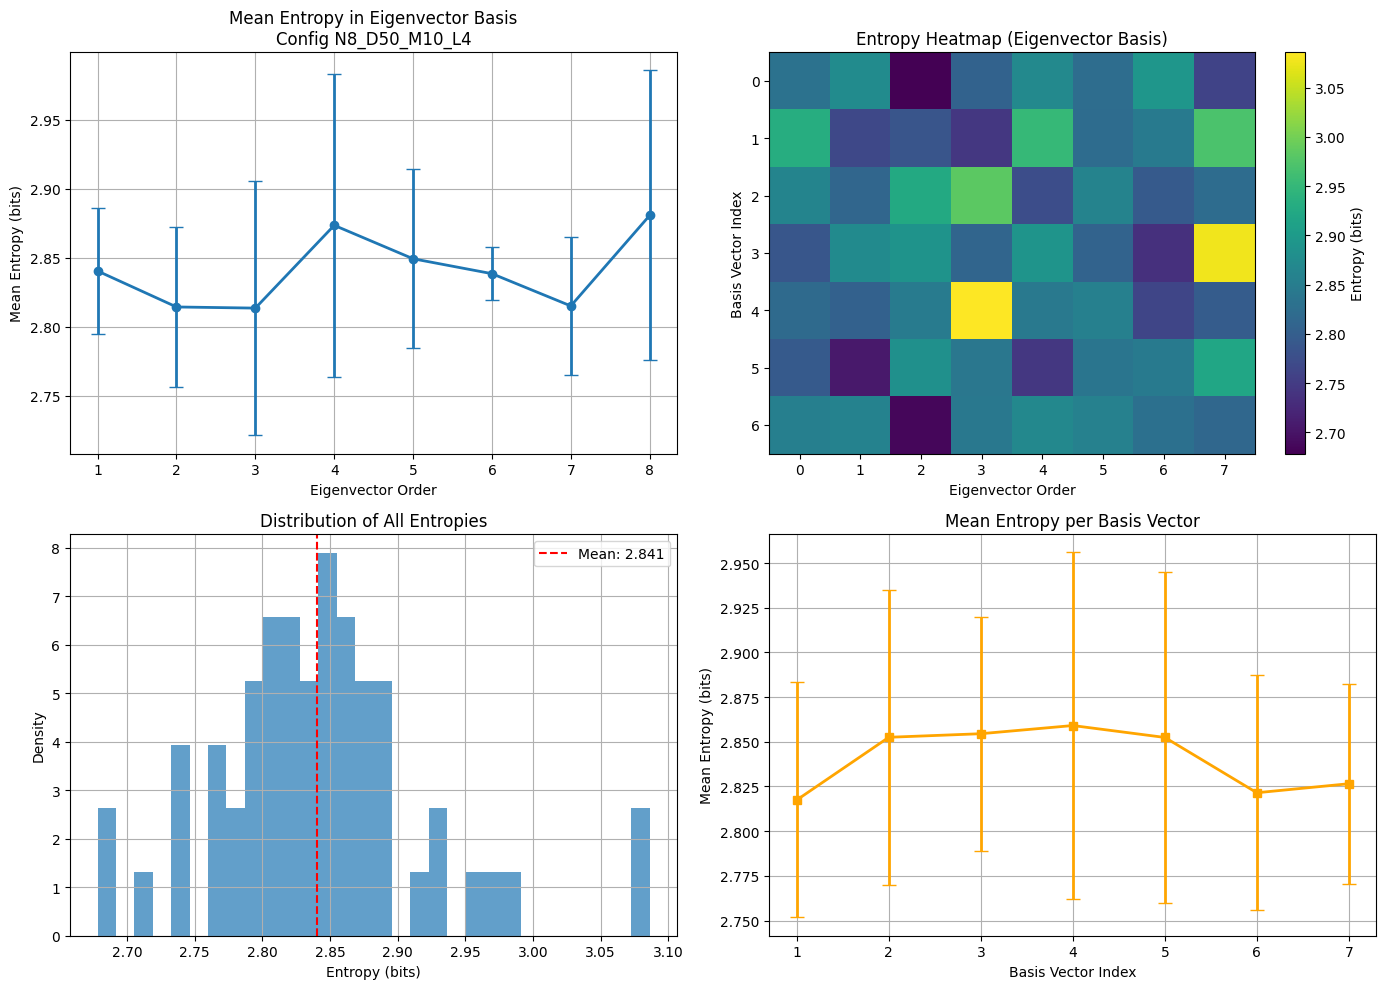

Processing experiment files:  34%|███▍      | 33/97 [04:43<08:28,  7.95s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8406 ± 0.0782 bits
  Max entropy: 3.0862 bits
  Min entropy: 2.6784 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8806 ± 0.1051 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8135 ± 0.0922 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8406 bits
  Difference: -3.7888 bits


Computing entropy in eigenvector basis - N8_D100_M20_L4
Using first experiment as basis, analyzing 99 remaining experiments


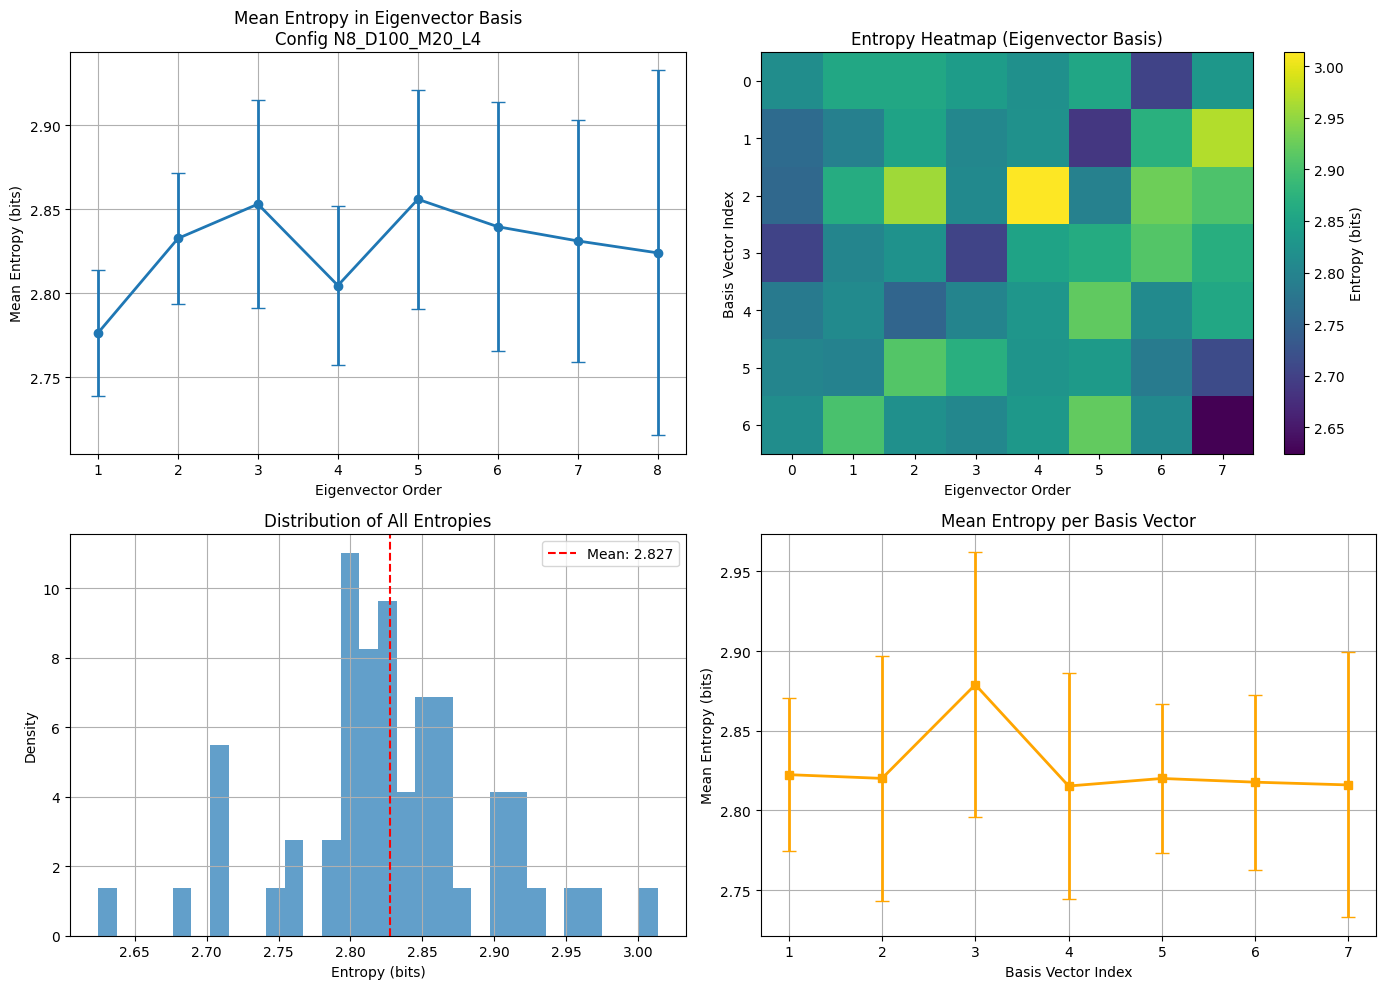

Processing experiment files:  35%|███▌      | 34/97 [04:50<08:01,  7.64s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8273 ± 0.0712 bits
  Max entropy: 3.0137 bits
  Min entropy: 2.6244 bits
  Number of basis vectors used: 7

Most random eigenvector: 5th
  Mean entropy: 2.8560 ± 0.0651 bits

Least random eigenvector: 1st
  Mean entropy: 2.7764 ± 0.0376 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8273 bits
  Difference: -3.8021 bits


Computing entropy in eigenvector basis - N8_D50_M100_L4
Using first experiment as basis, analyzing 99 remaining experiments


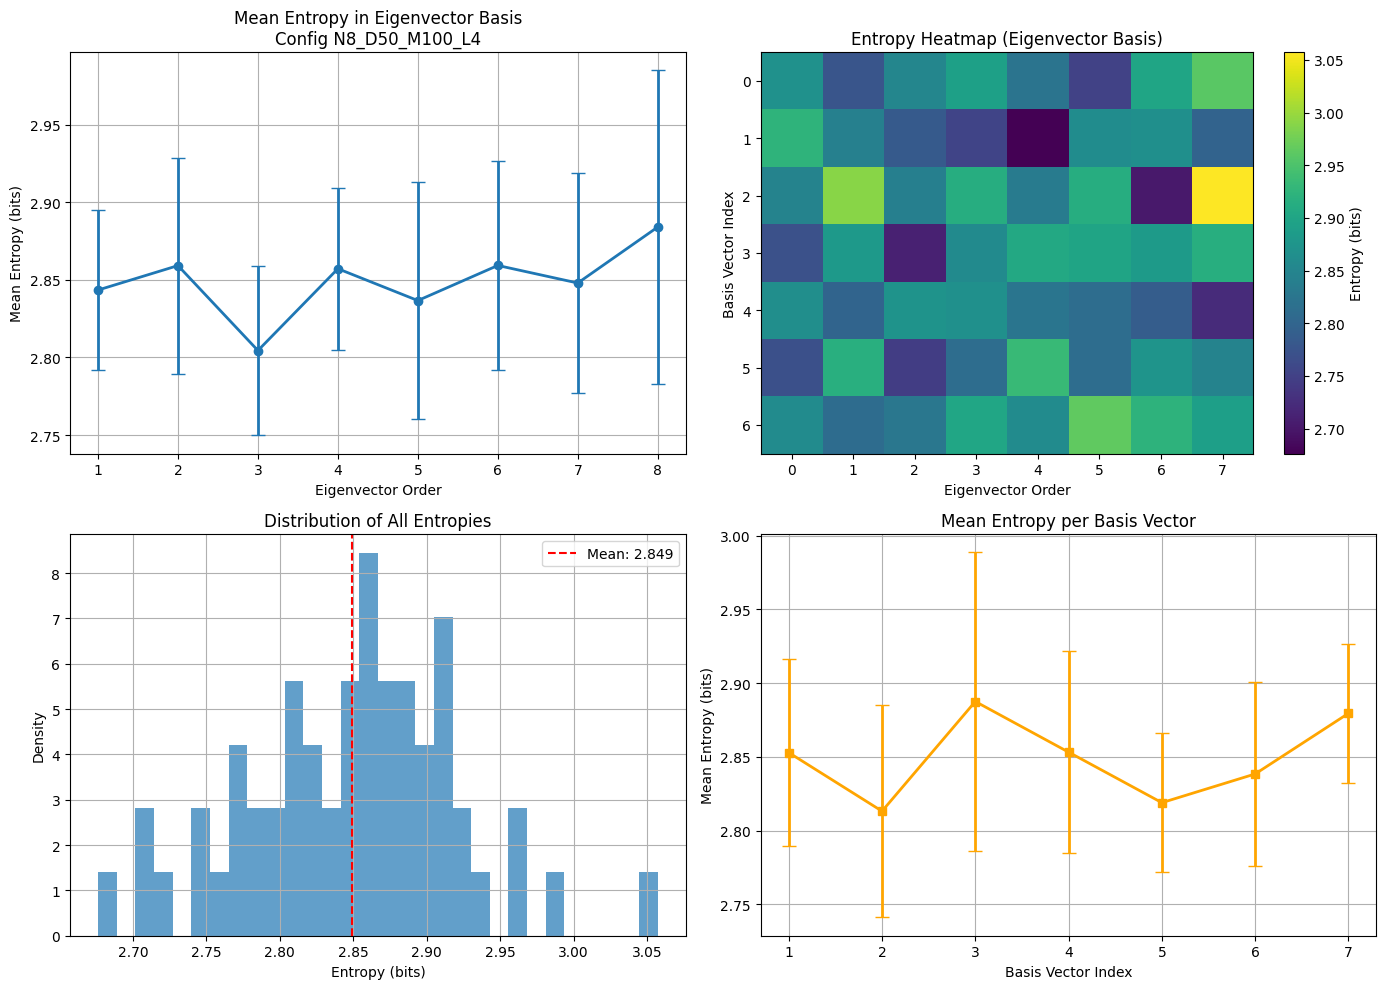

Processing experiment files:  36%|███▌      | 35/97 [04:57<07:49,  7.57s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8491 ± 0.0729 bits
  Max entropy: 3.0573 bits
  Min entropy: 2.6762 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8841 ± 0.1010 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8045 ± 0.0547 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8491 bits
  Difference: -3.7803 bits


Computing entropy in eigenvector basis - N8_D20_M200_L4
Using first experiment as basis, analyzing 99 remaining experiments


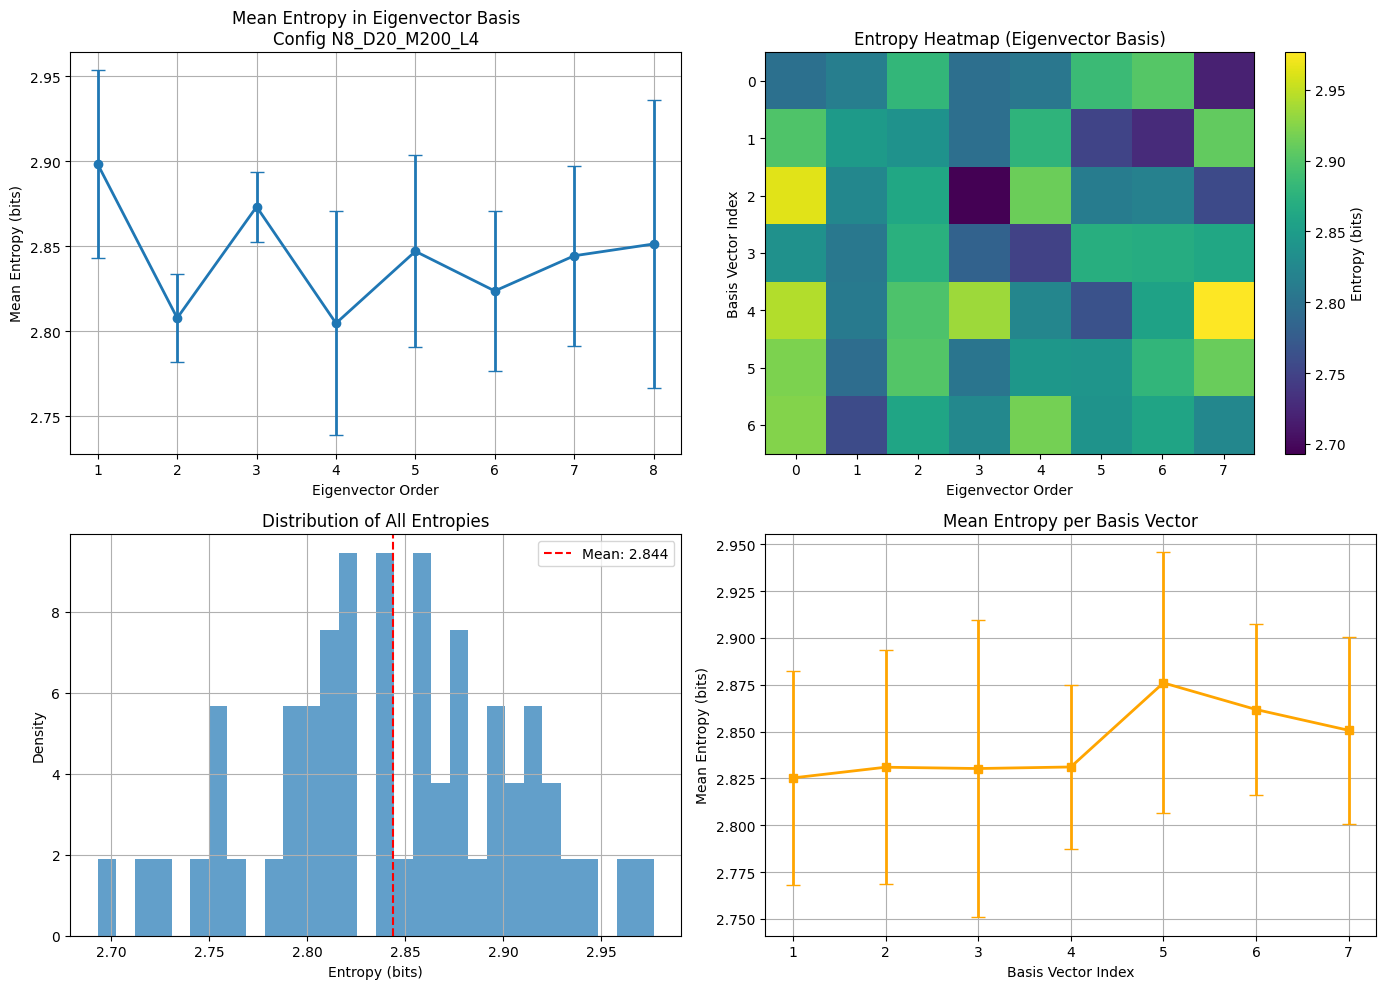

Processing experiment files:  37%|███▋      | 36/97 [05:05<07:51,  7.72s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8437 ± 0.0622 bits
  Max entropy: 2.9767 bits
  Min entropy: 2.6931 bits
  Number of basis vectors used: 7

Most random eigenvector: 1st
  Mean entropy: 2.8981 ± 0.0553 bits

Least random eigenvector: 4th
  Mean entropy: 2.8046 ± 0.0659 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8437 bits
  Difference: -3.7856 bits


Computing entropy in eigenvector basis - N8_D100_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


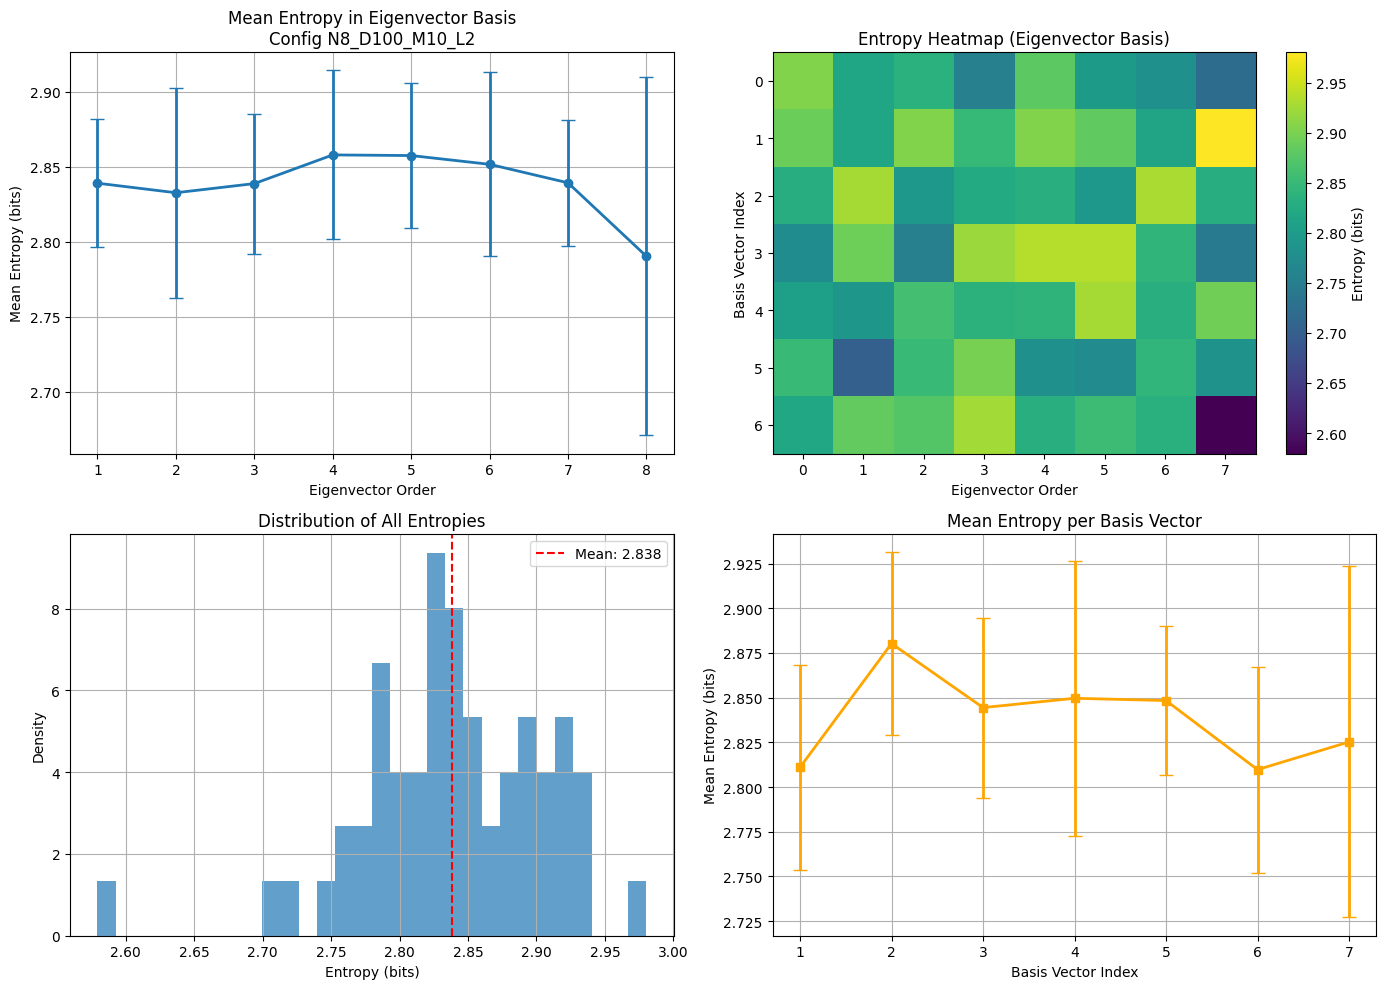

Processing experiment files:  38%|███▊      | 37/97 [05:14<07:58,  7.97s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8384 ± 0.0684 bits
  Max entropy: 2.9803 bits
  Min entropy: 2.5794 bits
  Number of basis vectors used: 7

Most random eigenvector: 4th
  Mean entropy: 2.8579 ± 0.0563 bits

Least random eigenvector: 8th
  Mean entropy: 2.7903 ± 0.1193 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8384 bits
  Difference: -3.7910 bits


Computing entropy in eigenvector basis - N8_D50_M10_L6
Using first experiment as basis, analyzing 99 remaining experiments


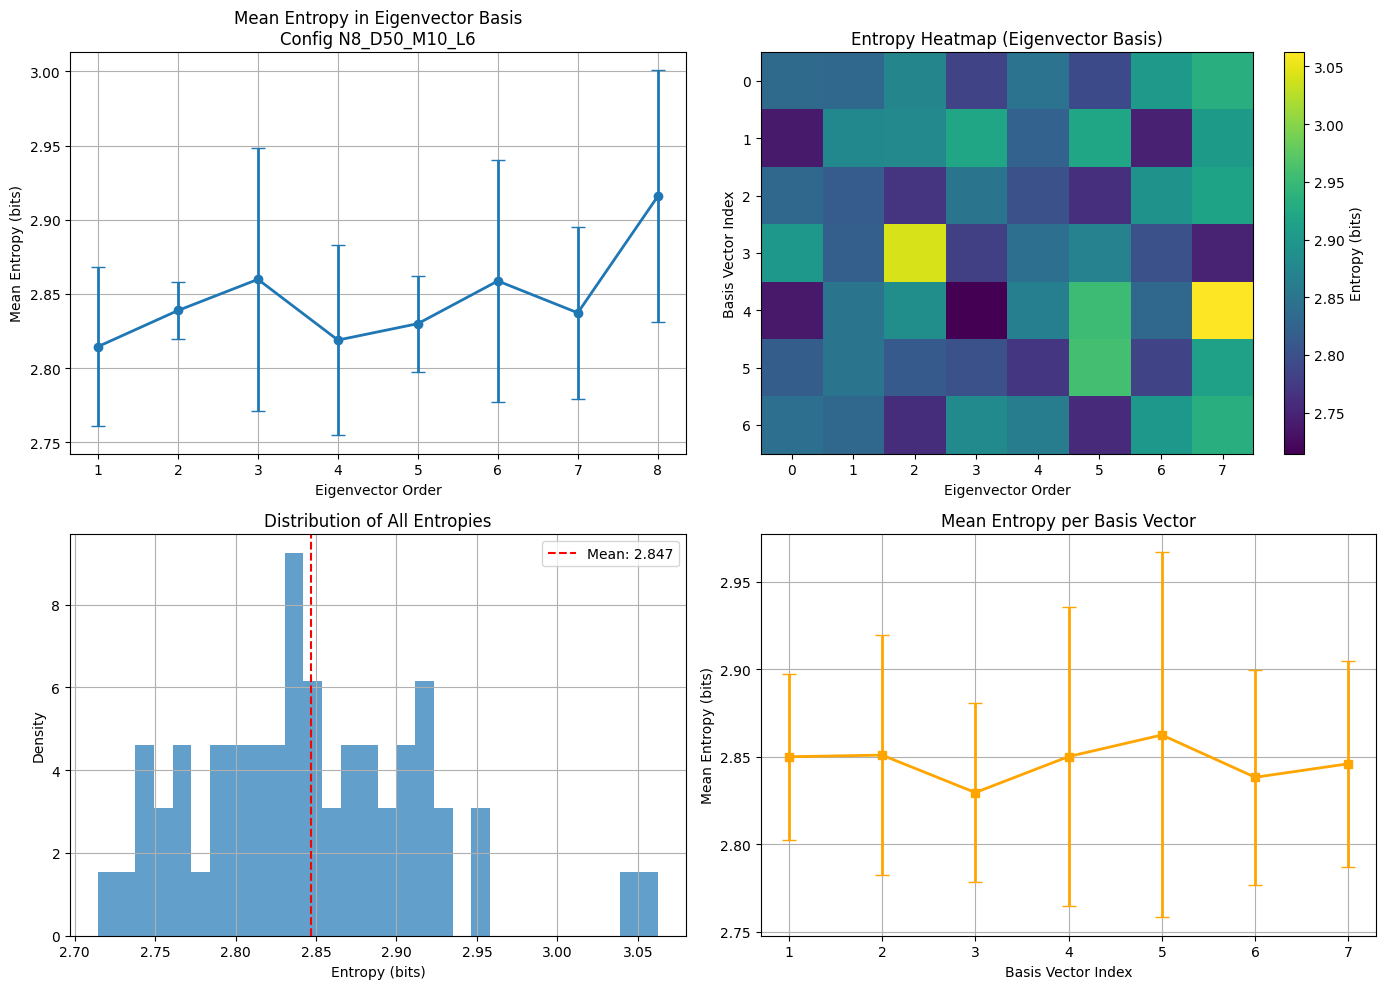

Processing experiment files:  39%|███▉      | 38/97 [05:21<07:38,  7.78s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8467 ± 0.0714 bits
  Max entropy: 3.0624 bits
  Min entropy: 2.7145 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9158 ± 0.0849 bits

Least random eigenvector: 1st
  Mean entropy: 2.8145 ± 0.0537 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8467 bits
  Difference: -3.7826 bits


Computing entropy in eigenvector basis - N8_D20_M20_L4
Using first experiment as basis, analyzing 99 remaining experiments


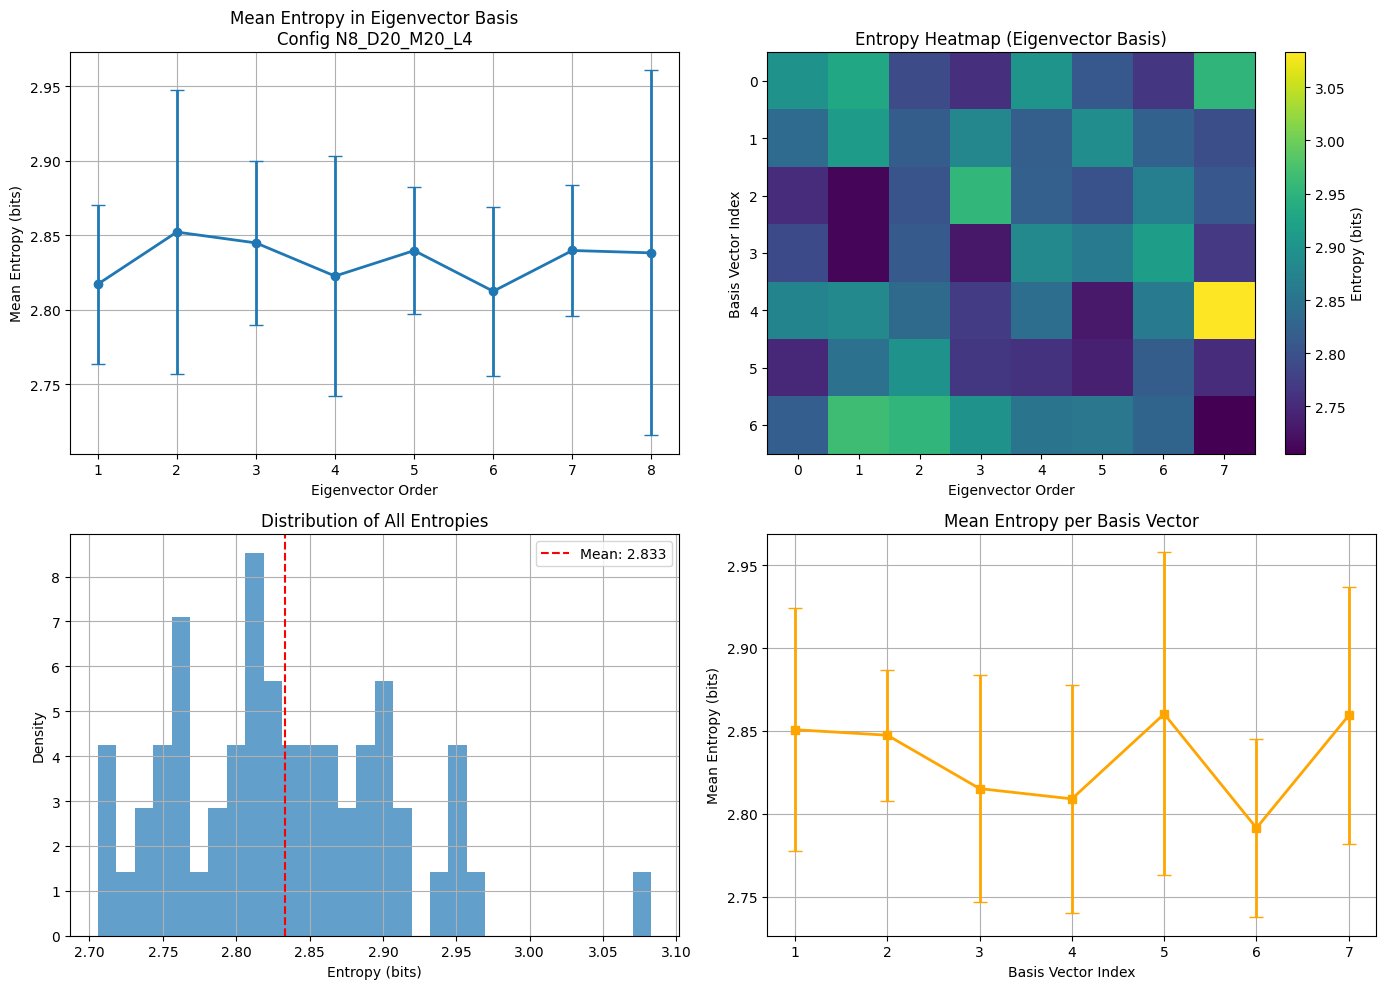

Processing experiment files:  40%|████      | 39/97 [05:30<07:44,  8.02s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8334 ± 0.0749 bits
  Max entropy: 3.0830 bits
  Min entropy: 2.7056 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.8522 ± 0.0954 bits

Least random eigenvector: 6th
  Mean entropy: 2.8124 ± 0.0568 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8334 bits
  Difference: -3.7960 bits


Computing entropy in eigenvector basis - N8_D200_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


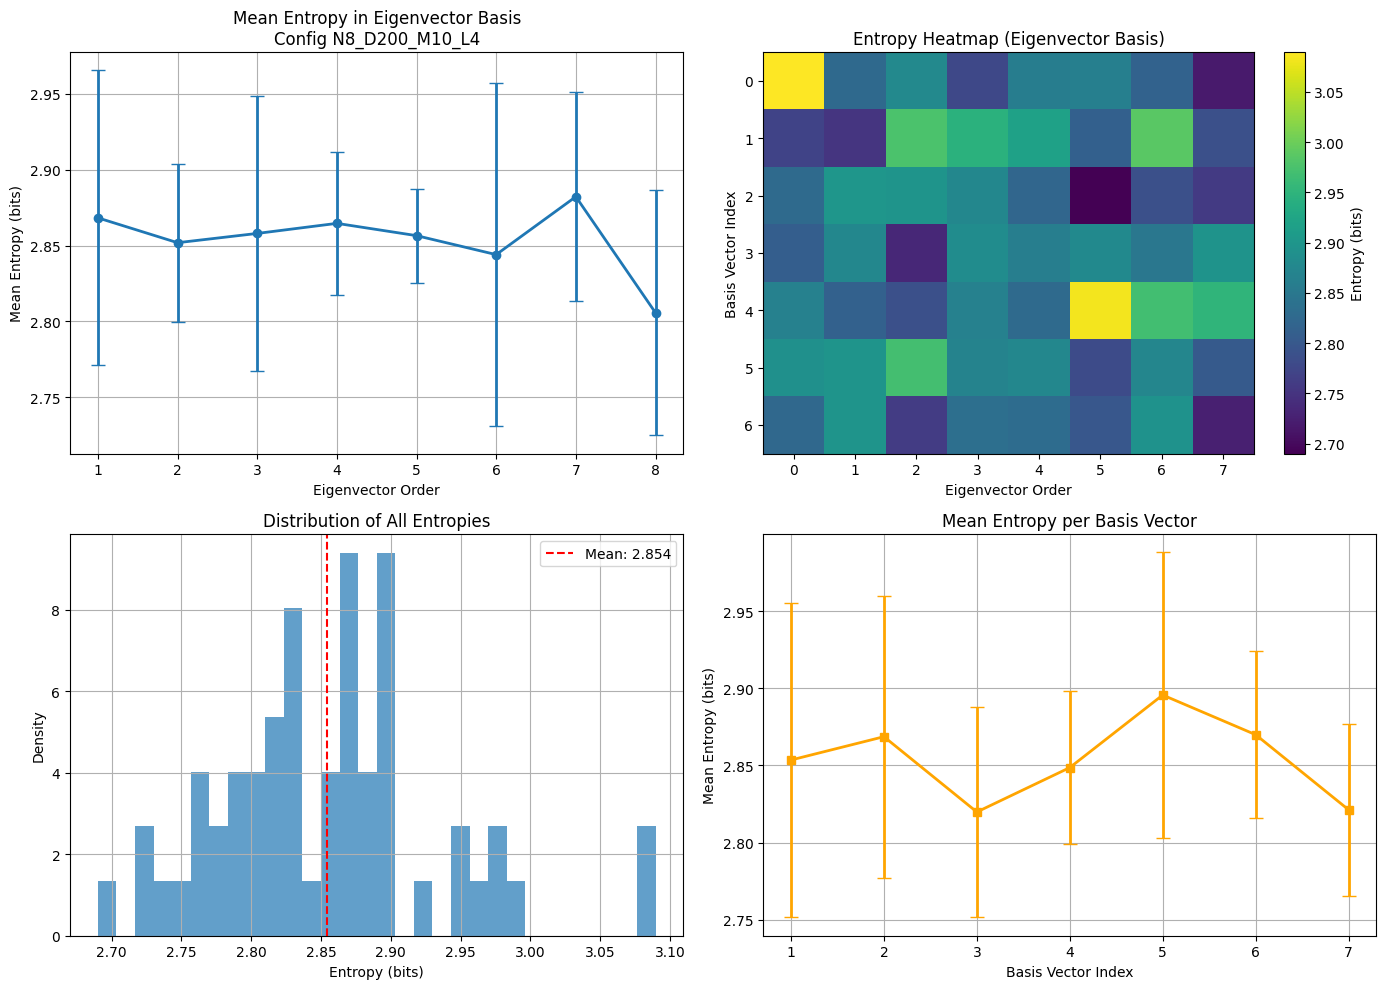

Processing experiment files:  41%|████      | 40/97 [05:38<07:45,  8.17s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8539 ± 0.0800 bits
  Max entropy: 3.0896 bits
  Min entropy: 2.6902 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.8823 ± 0.0690 bits

Least random eigenvector: 8th
  Mean entropy: 2.8057 ± 0.0808 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8539 bits
  Difference: -3.7754 bits


Computing entropy in eigenvector basis - N8_D100_M100_L2
Using first experiment as basis, analyzing 99 remaining experiments


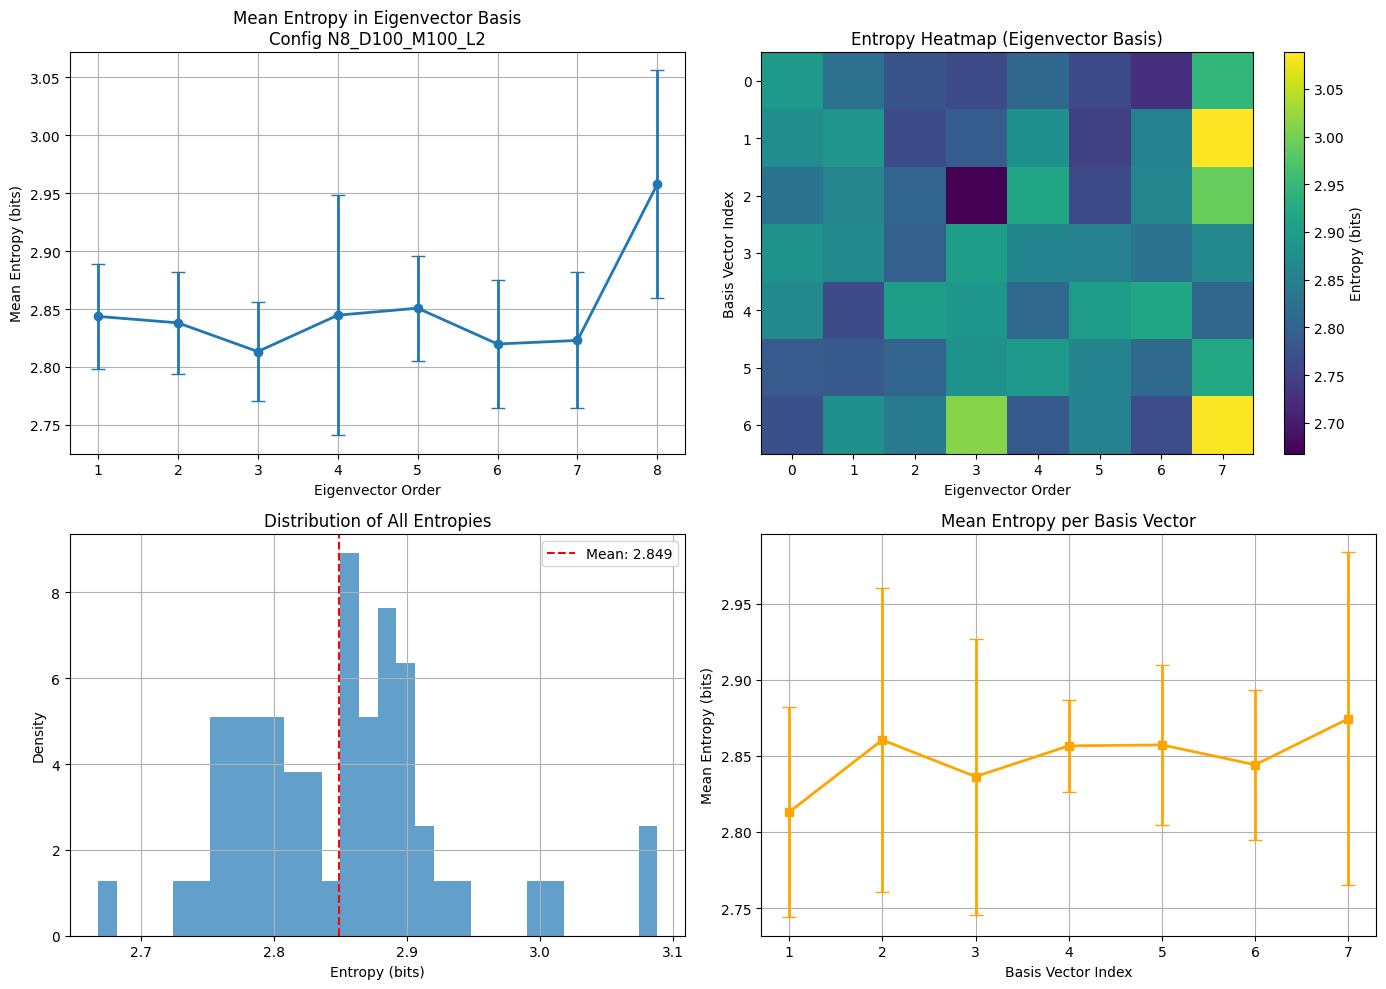

Processing experiment files:  42%|████▏     | 41/97 [05:46<07:31,  8.05s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8489 ± 0.0787 bits
  Max entropy: 3.0886 bits
  Min entropy: 2.6676 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9578 ± 0.0982 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8133 ± 0.0425 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8489 bits
  Difference: -3.7805 bits


Computing entropy in eigenvector basis - N8_D20_M50_L8
Using first experiment as basis, analyzing 99 remaining experiments


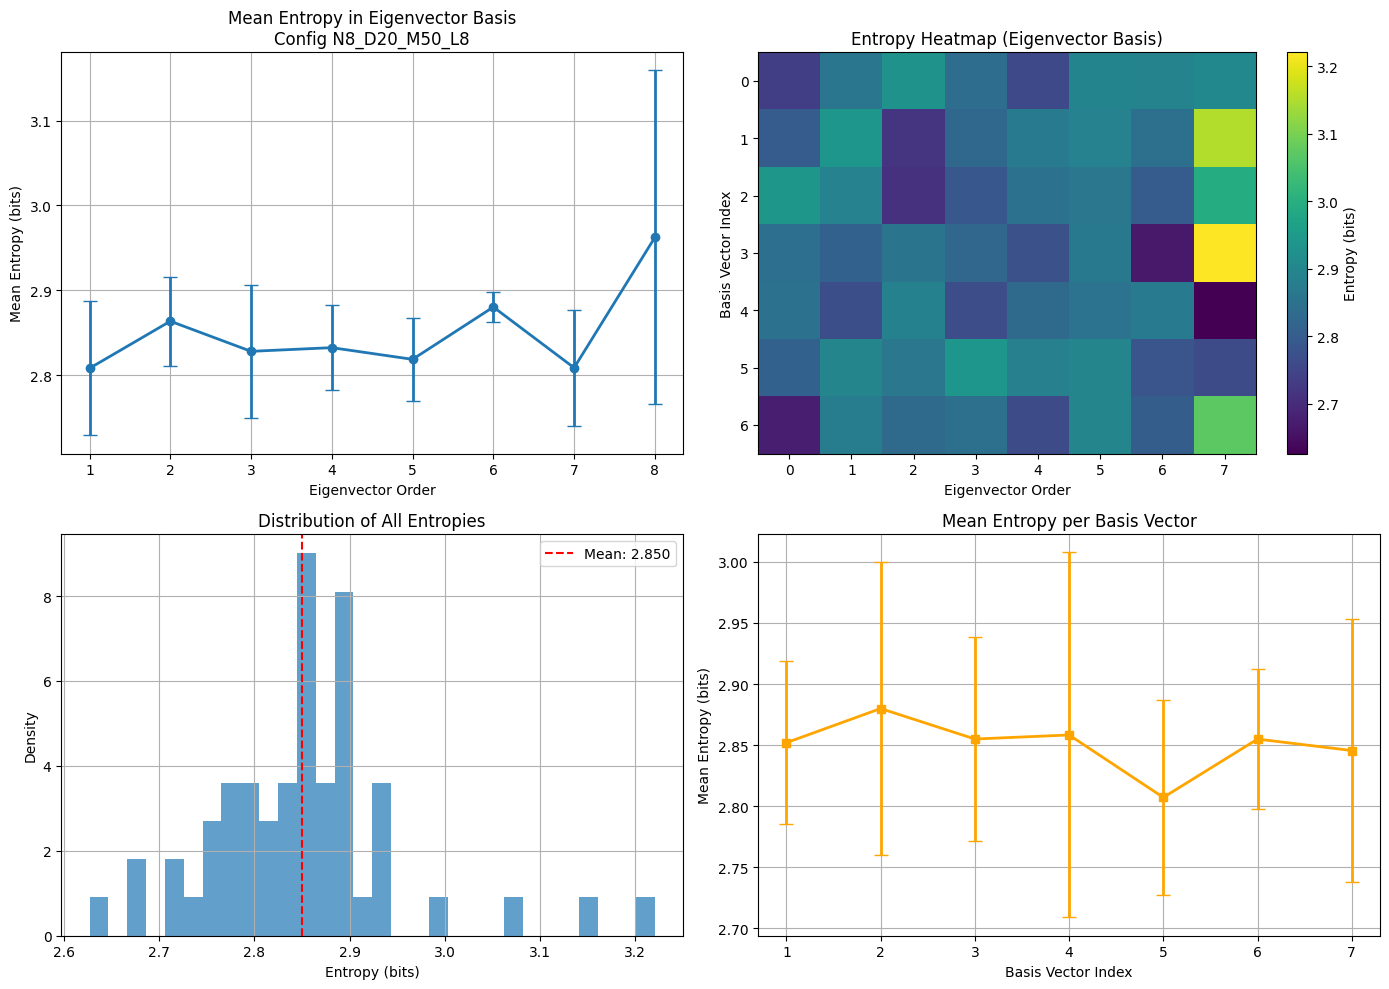

Processing experiment files:  43%|████▎     | 42/97 [05:54<07:29,  8.17s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8504 ± 0.1016 bits
  Max entropy: 3.2213 bits
  Min entropy: 2.6265 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9624 ± 0.1968 bits

Least random eigenvector: 1st
  Mean entropy: 2.8082 ± 0.0790 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8504 bits
  Difference: -3.7790 bits


Computing entropy in eigenvector basis - N8_D500_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


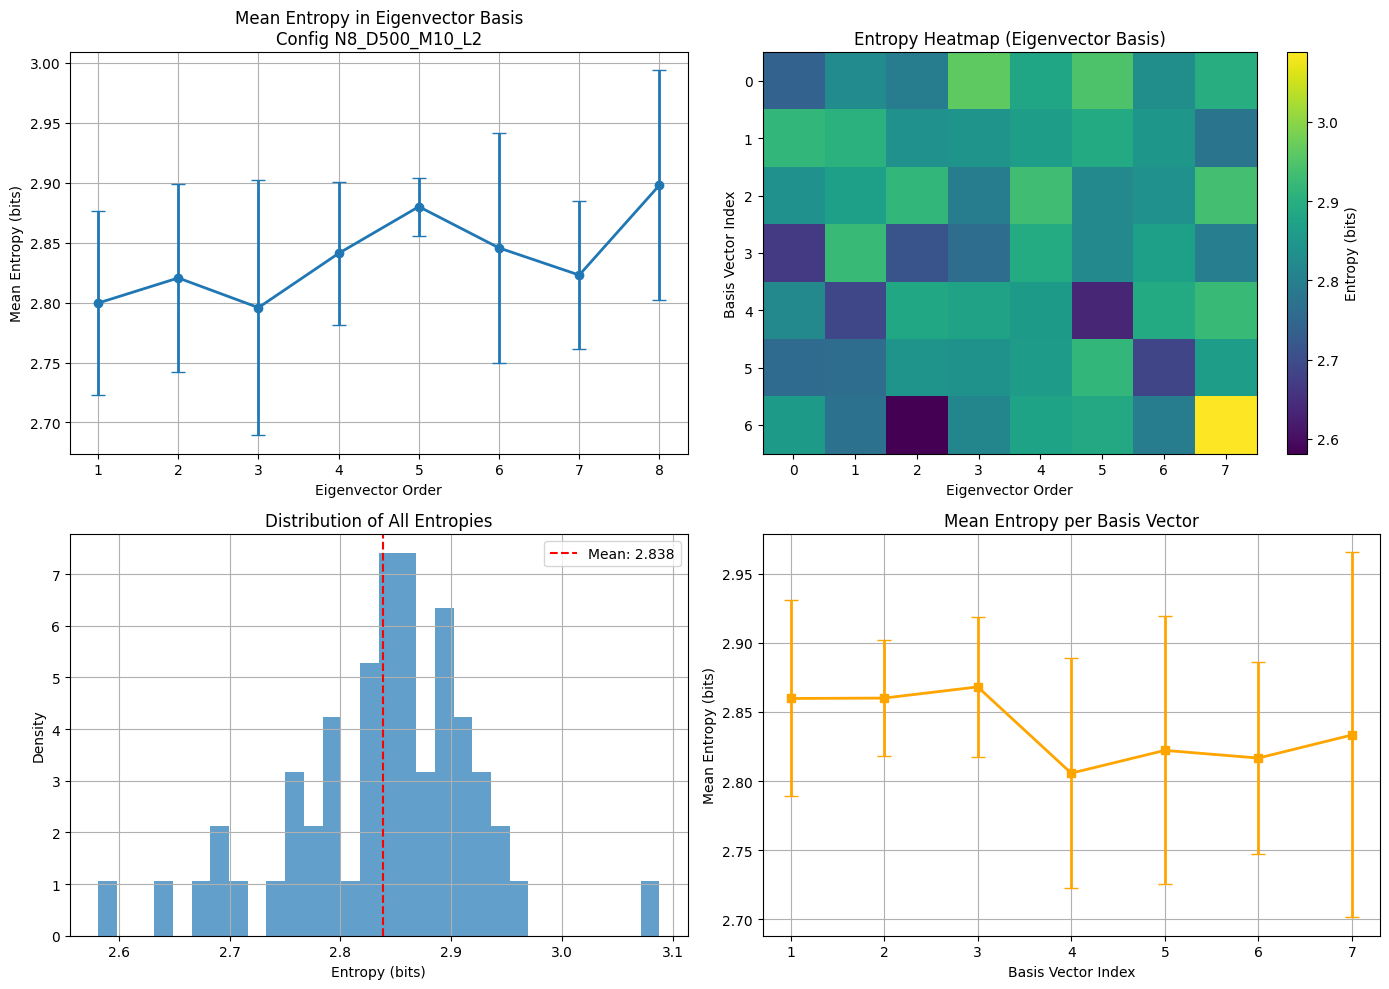

Processing experiment files:  44%|████▍     | 43/97 [06:03<07:29,  8.32s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8380 ± 0.0859 bits
  Max entropy: 3.0880 bits
  Min entropy: 2.5812 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8980 ± 0.0957 bits

Least random eigenvector: 3rd
  Mean entropy: 2.7958 ± 0.1066 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8380 bits
  Difference: -3.7914 bits


Computing entropy in eigenvector basis - N8_D100_M10_L8
Using first experiment as basis, analyzing 99 remaining experiments


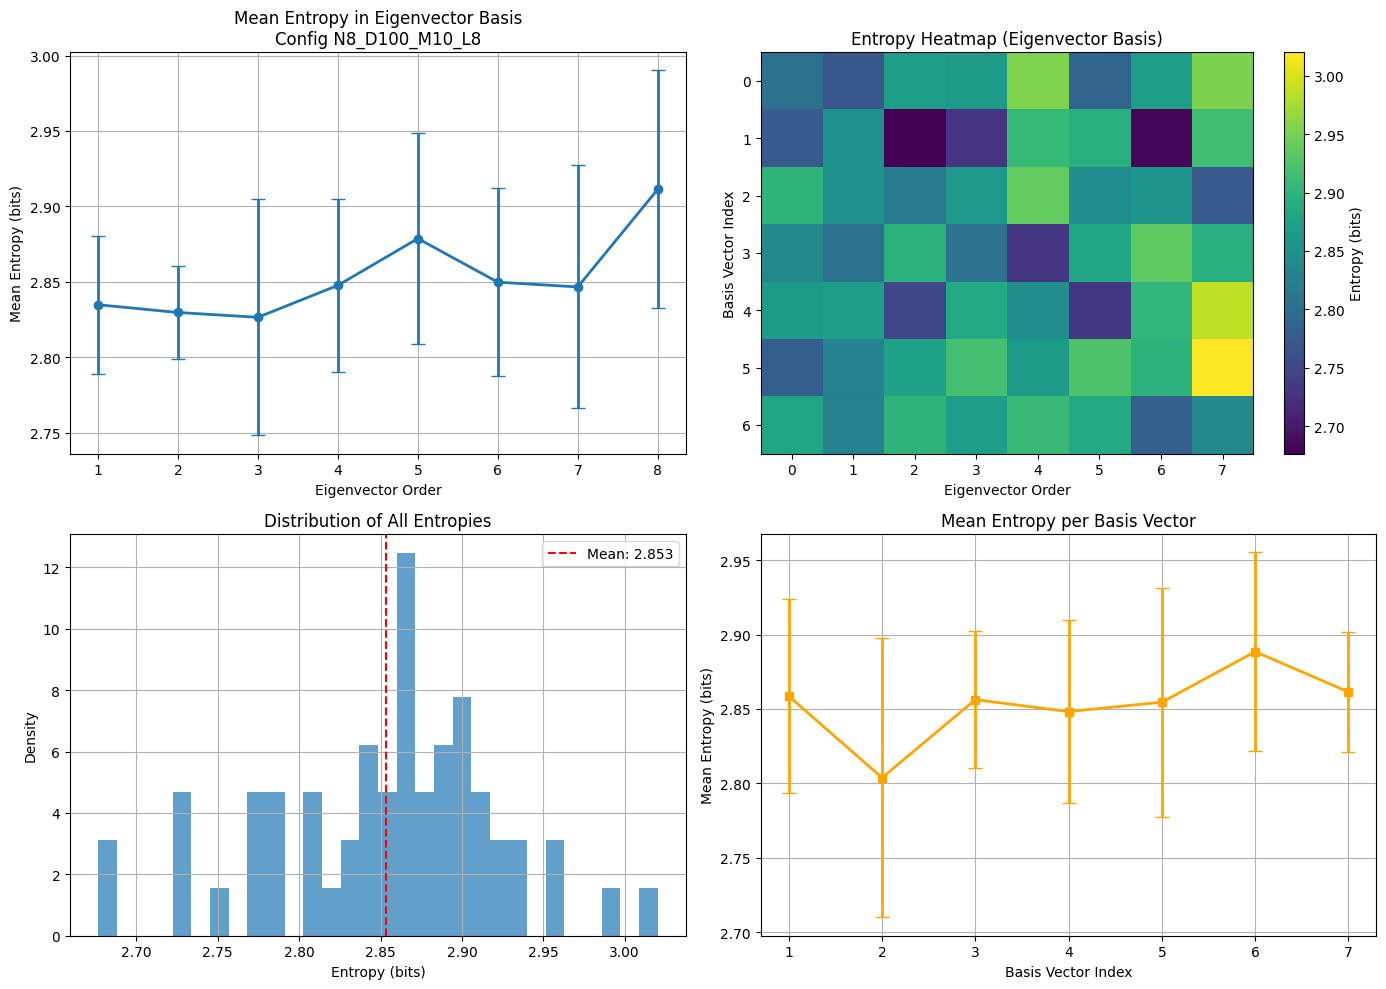

Processing experiment files:  45%|████▌     | 44/97 [06:11<07:21,  8.33s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8531 ± 0.0704 bits
  Max entropy: 3.0203 bits
  Min entropy: 2.6764 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9113 ± 0.0788 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8264 ± 0.0783 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8531 bits
  Difference: -3.7763 bits


Computing entropy in eigenvector basis - N8_D20_M20_L10
Using first experiment as basis, analyzing 99 remaining experiments


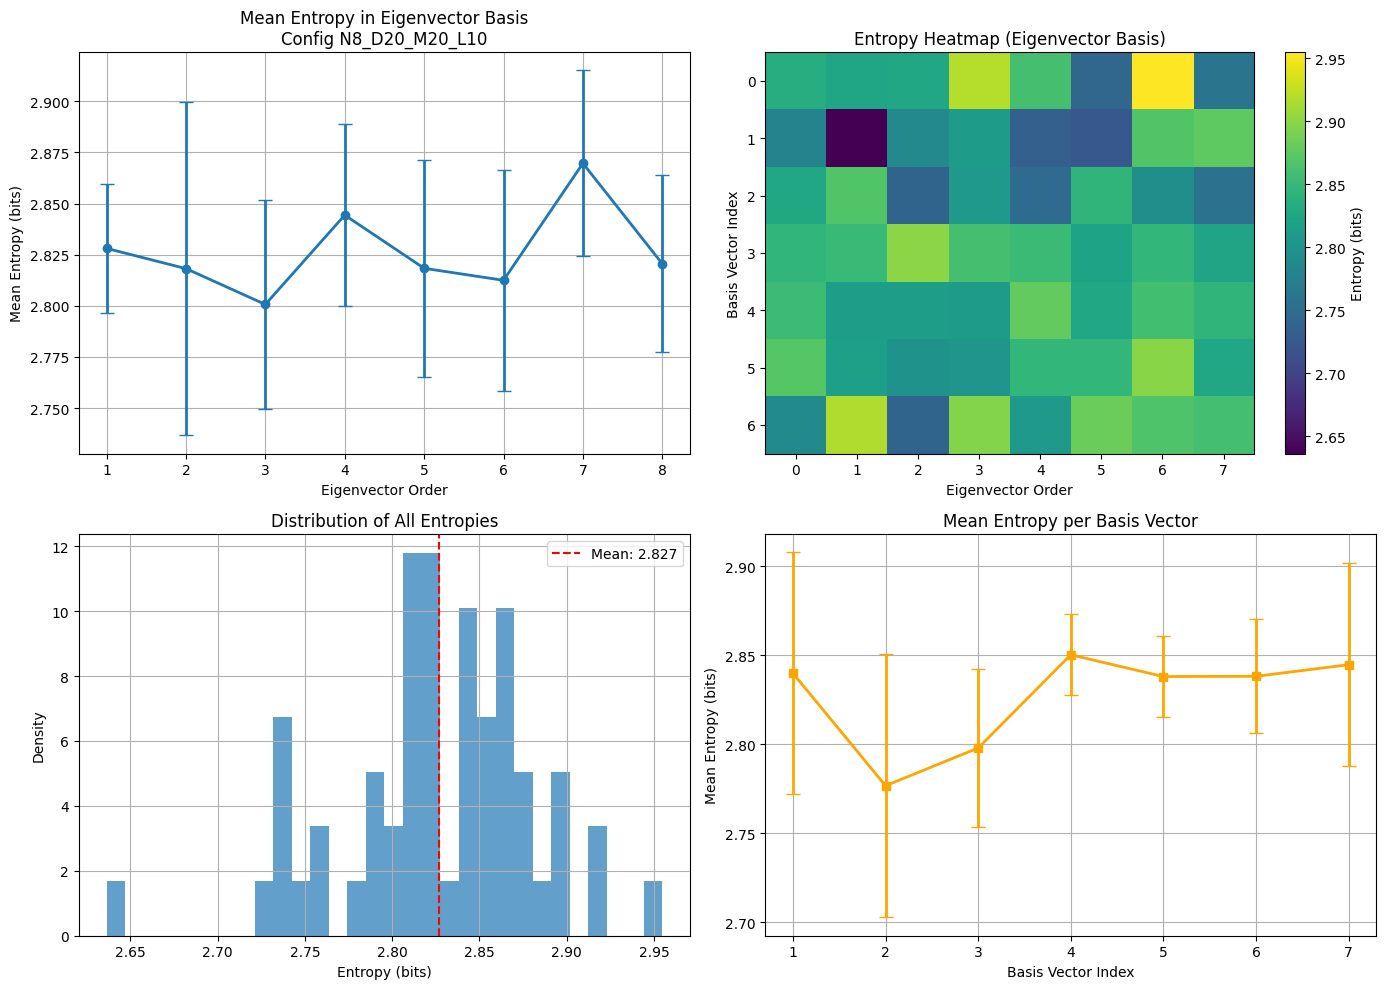

Processing experiment files:  46%|████▋     | 45/97 [06:18<06:53,  7.95s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8266 ± 0.0561 bits
  Max entropy: 2.9547 bits
  Min entropy: 2.6364 bits
  Number of basis vectors used: 7

Most random eigenvector: 7th
  Mean entropy: 2.8697 ± 0.0454 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8007 ± 0.0512 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8266 bits
  Difference: -3.8028 bits


Computing entropy in eigenvector basis - N8_D20_M500_L2
Using first experiment as basis, analyzing 99 remaining experiments


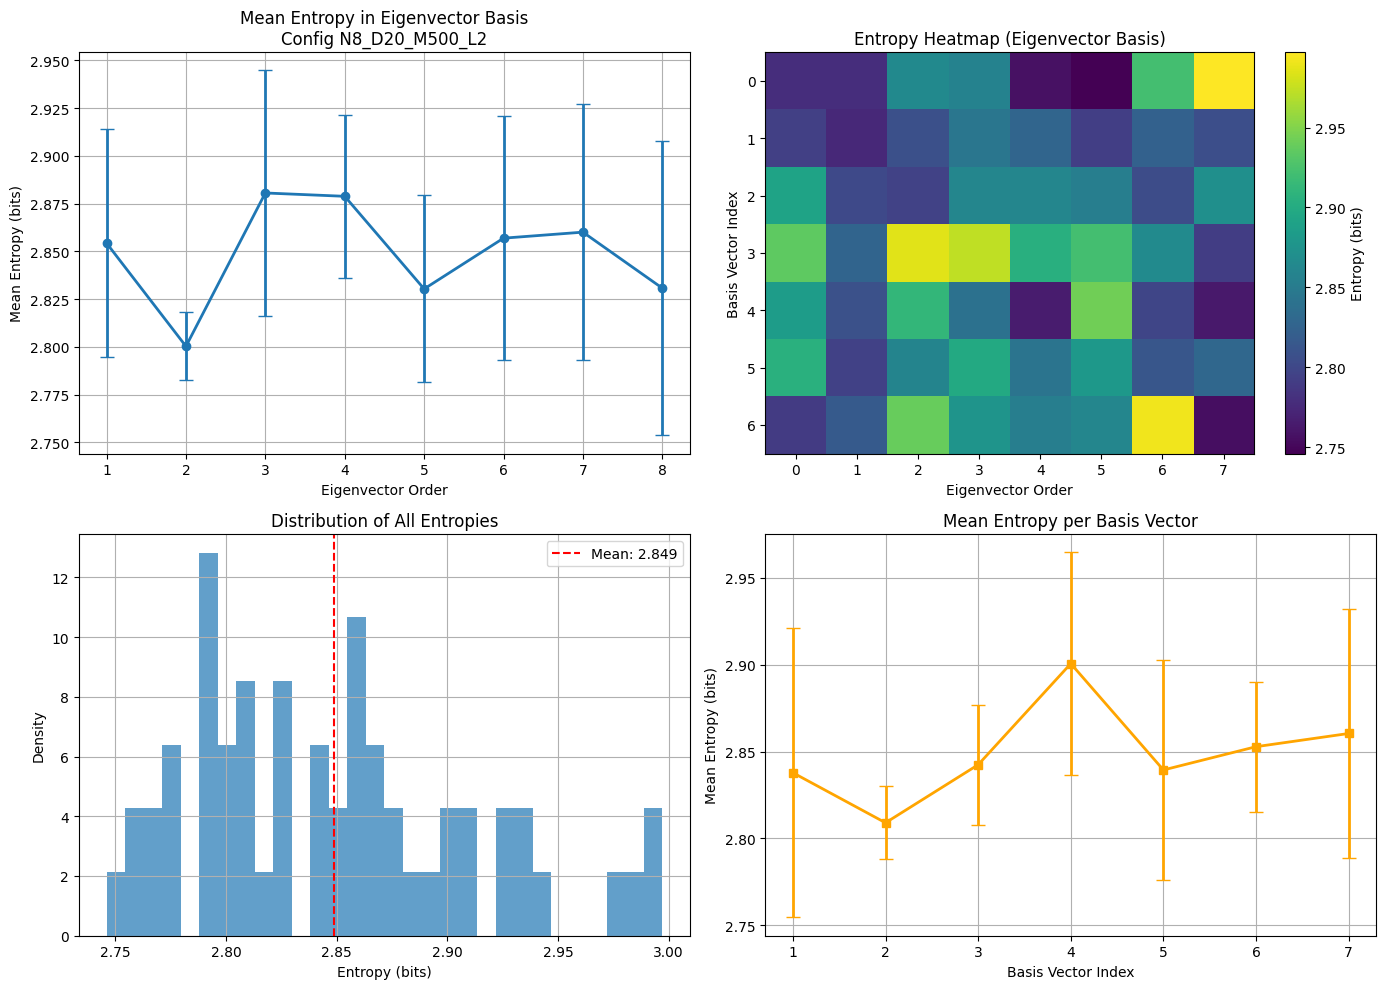

Processing experiment files:  47%|████▋     | 46/97 [06:26<06:37,  7.79s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8490 ± 0.0631 bits
  Max entropy: 2.9972 bits
  Min entropy: 2.7461 bits
  Number of basis vectors used: 7

Most random eigenvector: 3rd
  Mean entropy: 2.8805 ± 0.0642 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8003 ± 0.0178 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8490 bits
  Difference: -3.7804 bits


Computing entropy in eigenvector basis - N8_D200_M20_L4
Using first experiment as basis, analyzing 99 remaining experiments


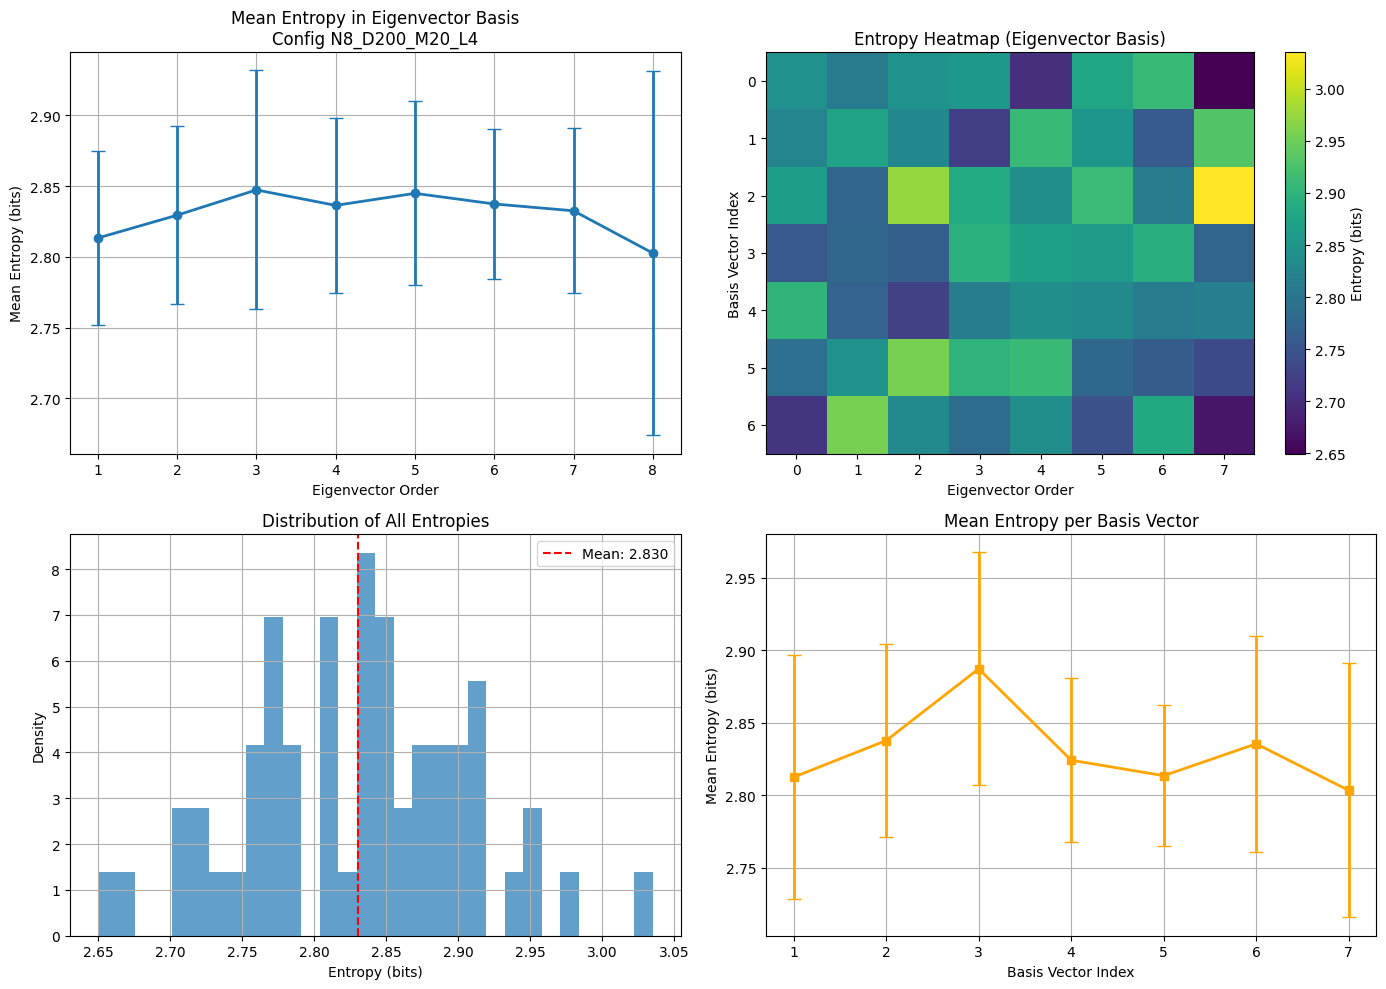

Processing experiment files:  48%|████▊     | 47/97 [06:35<06:53,  8.27s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8305 ± 0.0770 bits
  Max entropy: 3.0350 bits
  Min entropy: 2.6499 bits
  Number of basis vectors used: 7

Most random eigenvector: 3rd
  Mean entropy: 2.8473 ± 0.0845 bits

Least random eigenvector: 8th
  Mean entropy: 2.8026 ± 0.1288 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8305 bits
  Difference: -3.7989 bits


Computing entropy in eigenvector basis - N8_D20_M20_L2
Using first experiment as basis, analyzing 99 remaining experiments


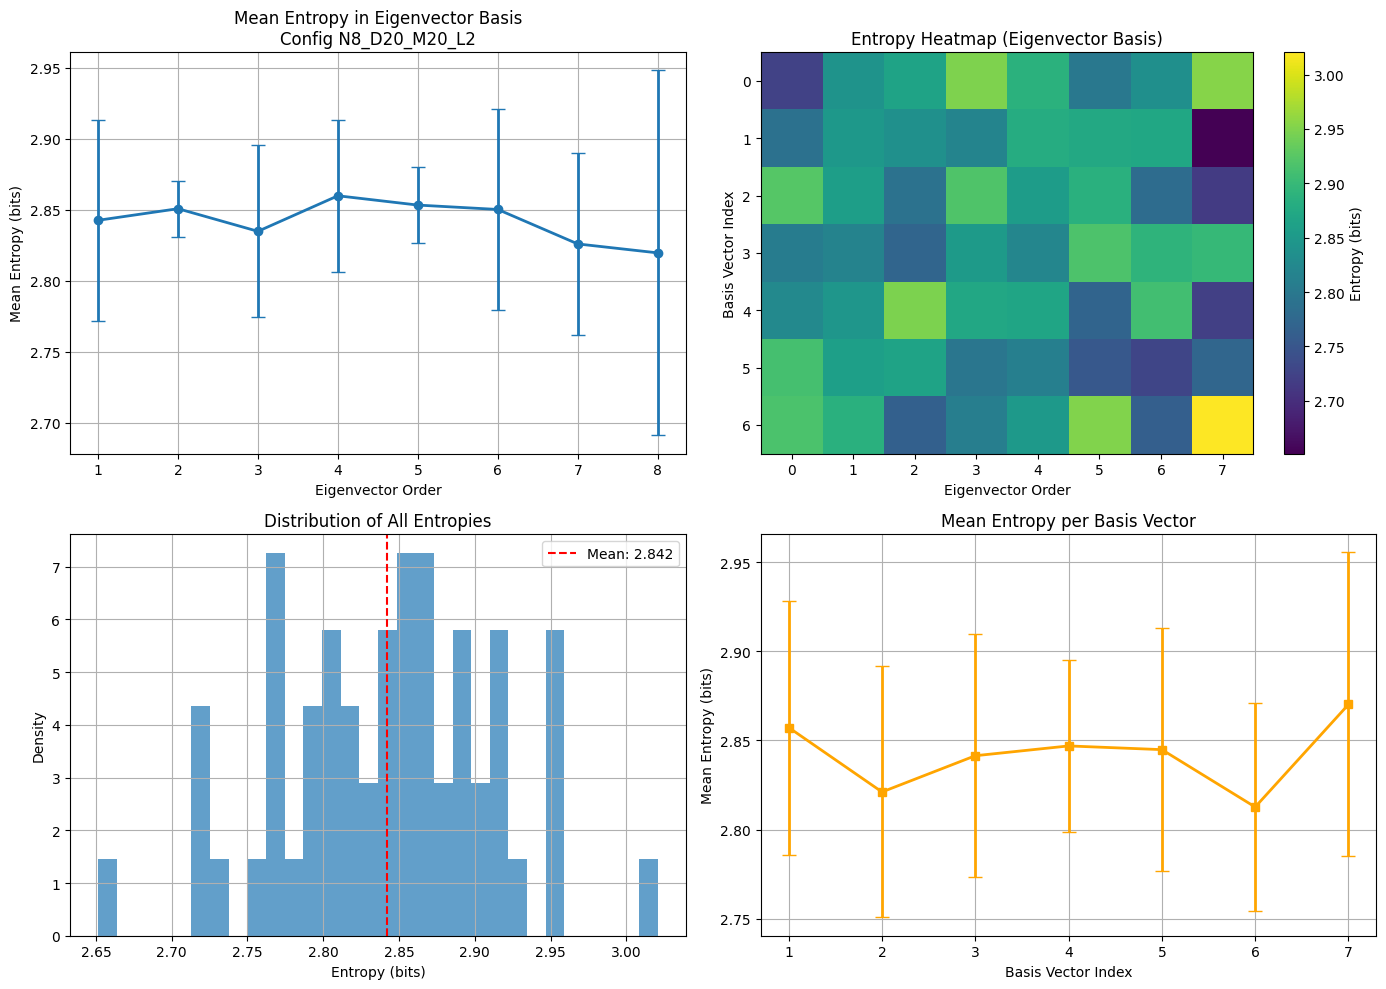

Processing experiment files:  49%|████▉     | 48/97 [06:45<06:59,  8.57s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8421 ± 0.0704 bits
  Max entropy: 3.0207 bits
  Min entropy: 2.6514 bits
  Number of basis vectors used: 7

Most random eigenvector: 4th
  Mean entropy: 2.8598 ± 0.0535 bits

Least random eigenvector: 8th
  Mean entropy: 2.8196 ± 0.1285 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8421 bits
  Difference: -3.7873 bits


Computing entropy in eigenvector basis - N8_D20_M100_L4
Using first experiment as basis, analyzing 99 remaining experiments


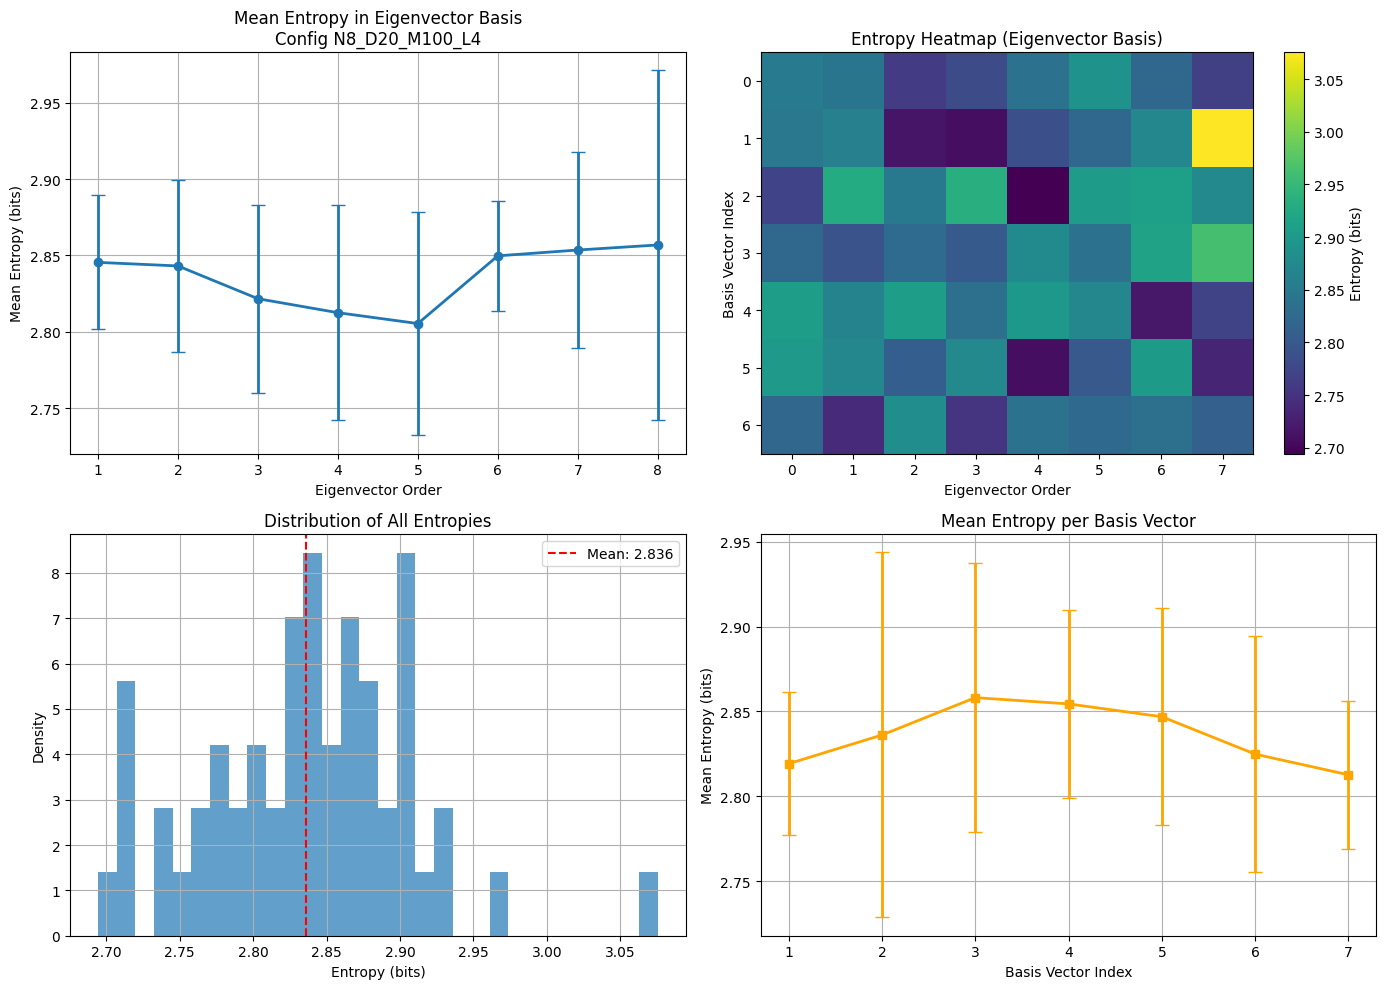

Processing experiment files:  51%|█████     | 49/97 [06:53<06:42,  8.39s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8360 ± 0.0711 bits
  Max entropy: 3.0756 bits
  Min entropy: 2.6944 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.8569 ± 0.1144 bits

Least random eigenvector: 5th
  Mean entropy: 2.8054 ± 0.0733 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8360 bits
  Difference: -3.7933 bits


Computing entropy in eigenvector basis - N8_D100_M50_L2
Using first experiment as basis, analyzing 99 remaining experiments


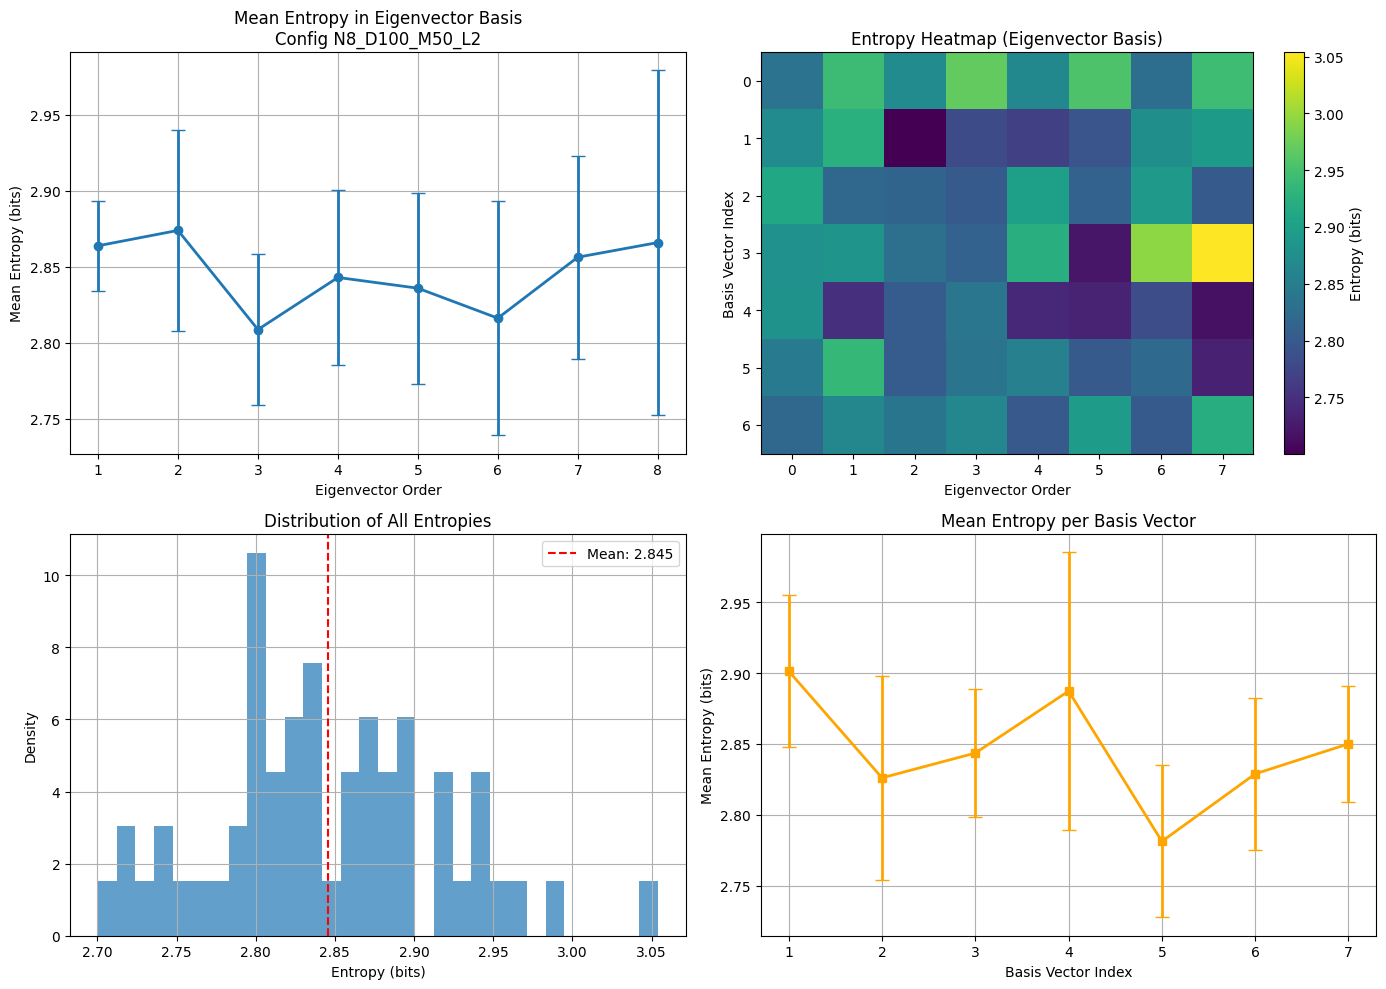

Processing experiment files:  52%|█████▏    | 50/97 [07:01<06:35,  8.42s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8455 ± 0.0725 bits
  Max entropy: 3.0539 bits
  Min entropy: 2.7004 bits
  Number of basis vectors used: 7

Most random eigenvector: 2nd
  Mean entropy: 2.8739 ± 0.0659 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8088 ± 0.0494 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8455 bits
  Difference: -3.7839 bits


Computing entropy in eigenvector basis - N8_D200_M10_L6
Using first experiment as basis, analyzing 99 remaining experiments


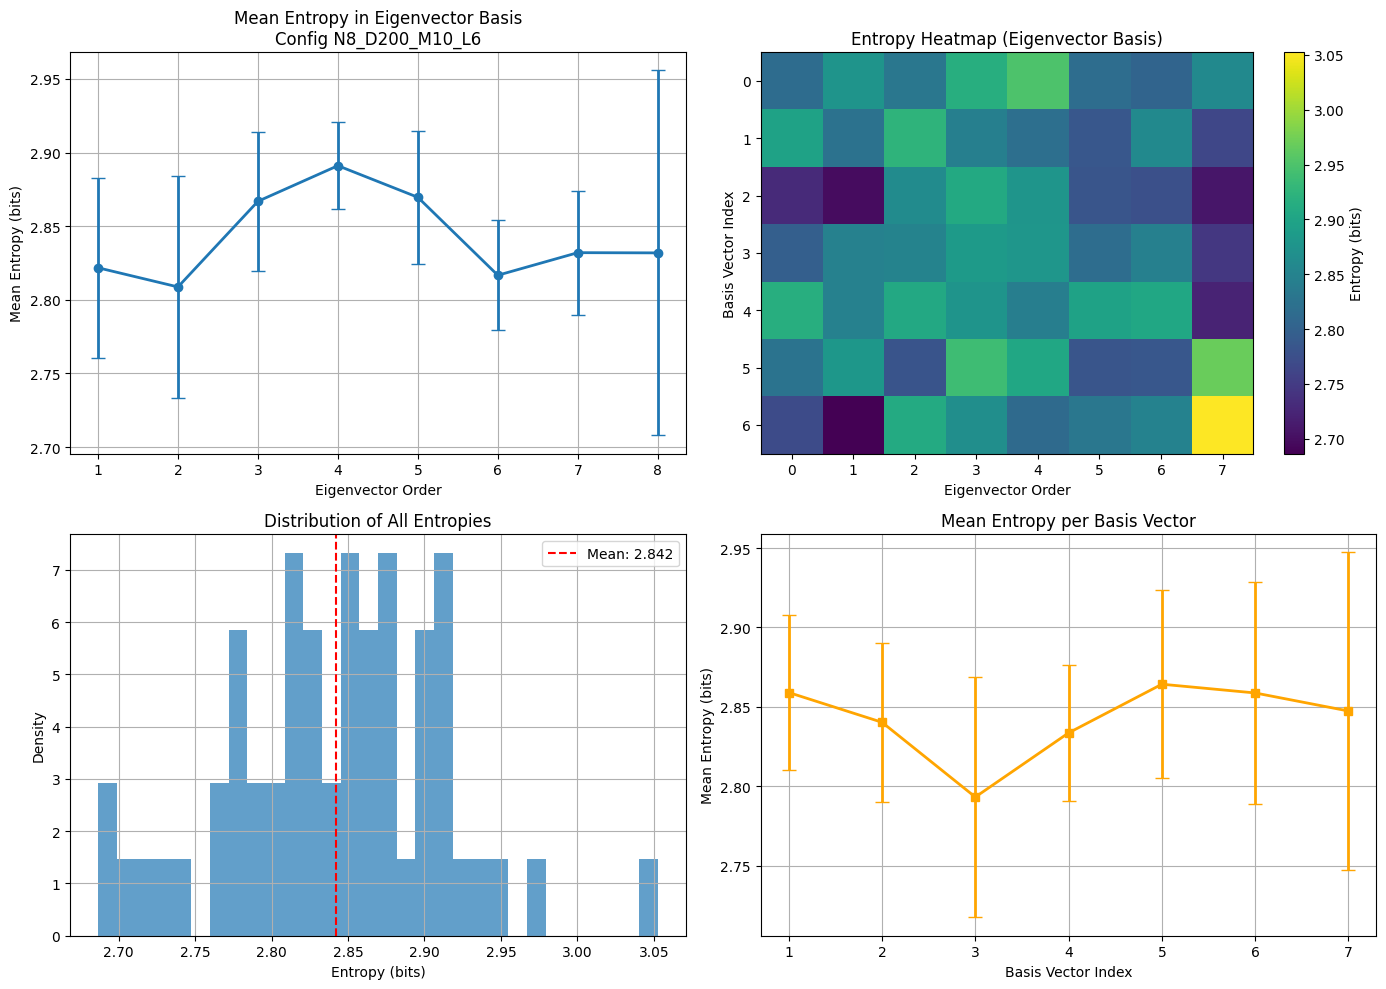

Processing experiment files:  53%|█████▎    | 51/97 [07:09<06:23,  8.33s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8423 ± 0.0701 bits
  Max entropy: 3.0525 bits
  Min entropy: 2.6865 bits
  Number of basis vectors used: 7

Most random eigenvector: 4th
  Mean entropy: 2.8911 ± 0.0295 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8087 ± 0.0757 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8423 bits
  Difference: -3.7870 bits


Computing entropy in eigenvector basis - N8_D20_M10_L10
Using first experiment as basis, analyzing 99 remaining experiments


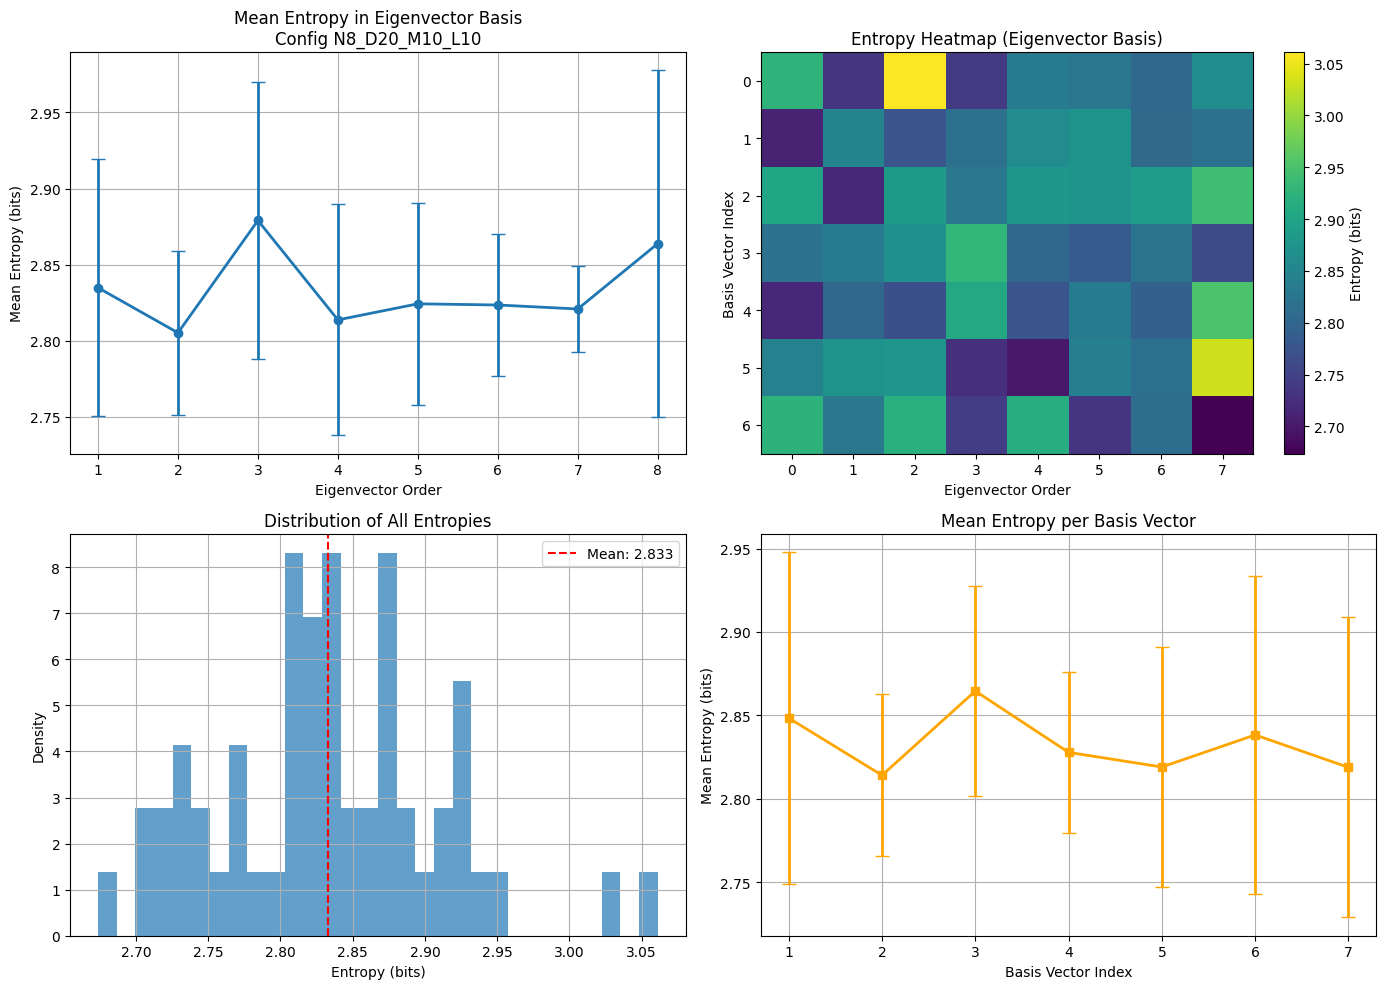

Processing experiment files:  54%|█████▎    | 52/97 [07:18<06:20,  8.45s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8331 ± 0.0782 bits
  Max entropy: 3.0611 bits
  Min entropy: 2.6738 bits
  Number of basis vectors used: 7

Most random eigenvector: 3rd
  Mean entropy: 2.8790 ± 0.0910 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8051 ± 0.0538 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8331 bits
  Difference: -3.7963 bits


Computing entropy in eigenvector basis - N8_D500_M10_L4
Using first experiment as basis, analyzing 99 remaining experiments


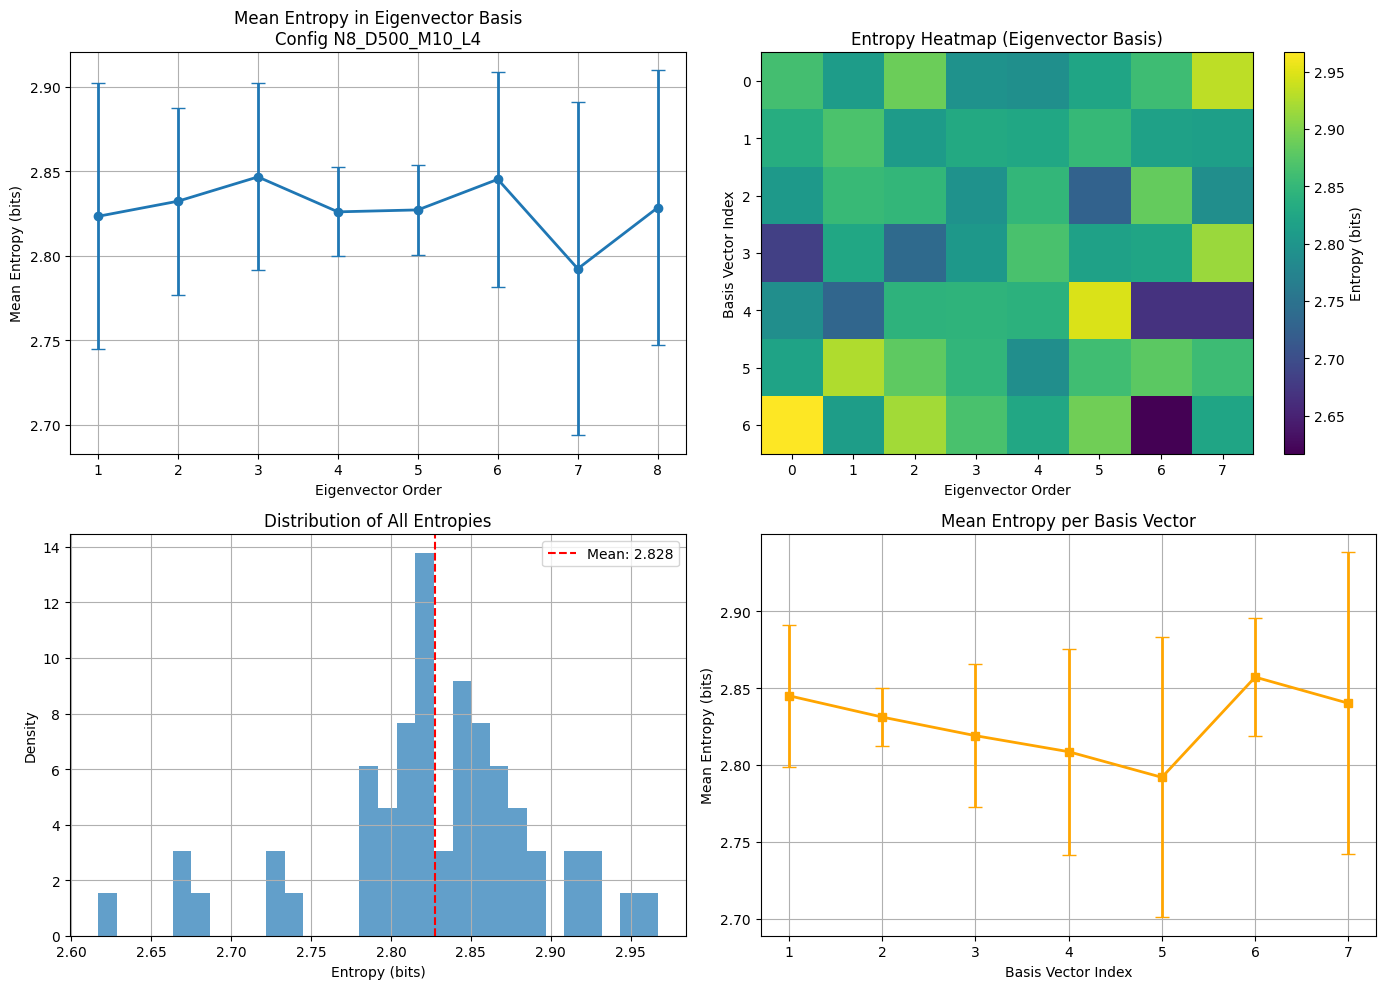

Processing experiment files:  55%|█████▍    | 53/97 [07:25<05:54,  8.05s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8276 ± 0.0671 bits
  Max entropy: 2.9670 bits
  Min entropy: 2.6168 bits
  Number of basis vectors used: 7

Most random eigenvector: 3rd
  Mean entropy: 2.8466 ± 0.0554 bits

Least random eigenvector: 7th
  Mean entropy: 2.7922 ± 0.0986 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8276 bits
  Difference: -3.8018 bits


Computing entropy in eigenvector basis - N8_D50_M20_L2
Using first experiment as basis, analyzing 99 remaining experiments


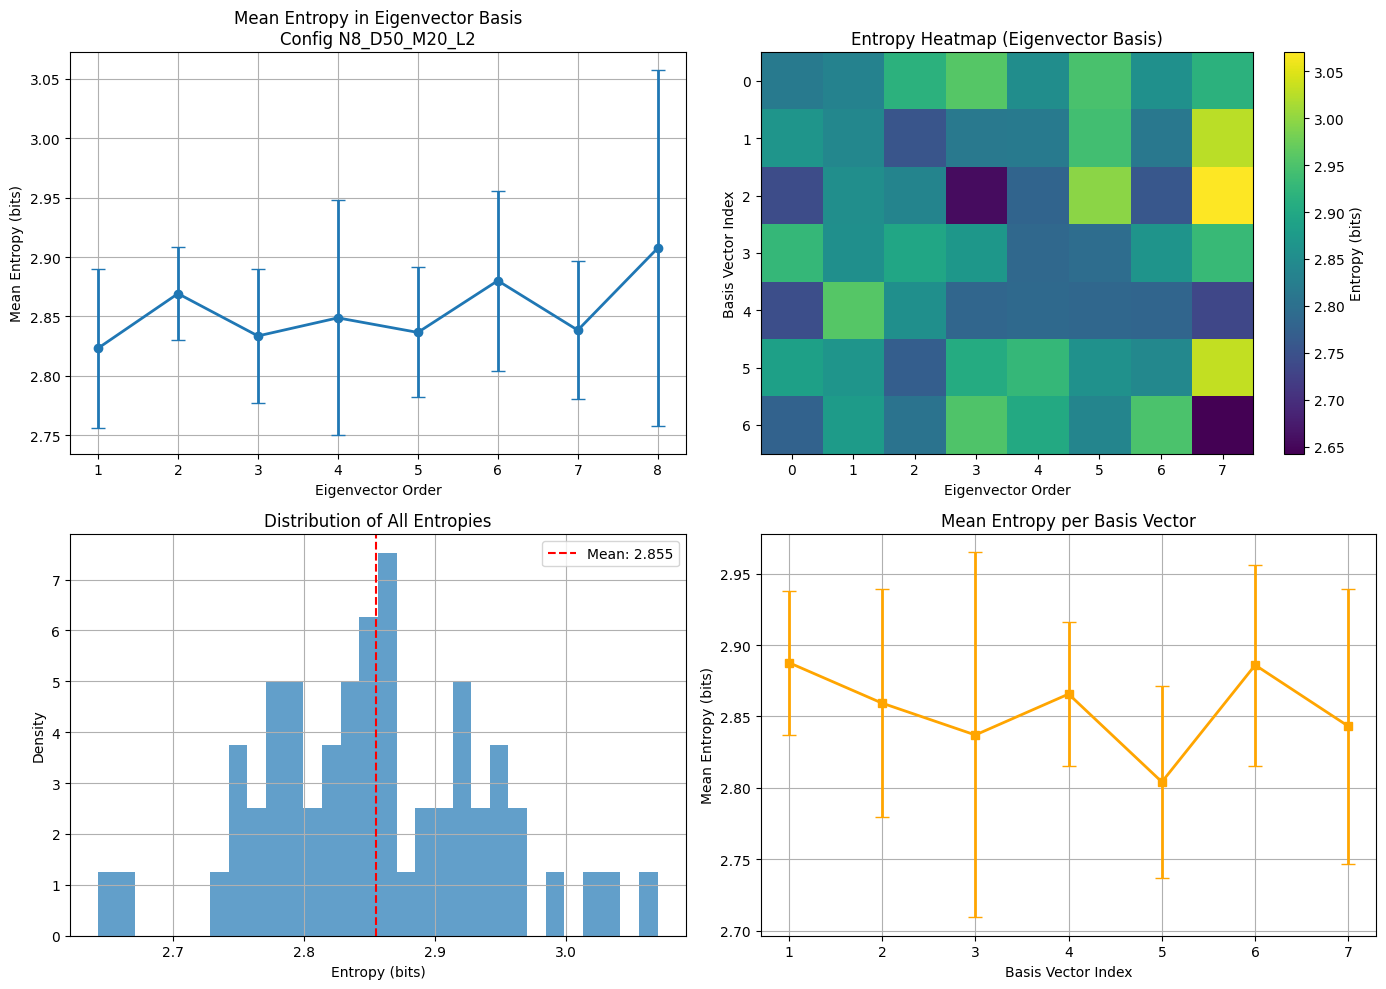

Processing experiment files:  56%|█████▌    | 54/97 [07:34<05:56,  8.28s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8547 ± 0.0860 bits
  Max entropy: 3.0704 bits
  Min entropy: 2.6427 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9076 ± 0.1496 bits

Least random eigenvector: 1st
  Mean entropy: 2.8232 ± 0.0669 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8547 bits
  Difference: -3.7747 bits


Computing entropy in eigenvector basis - N8_D50_M20_L8
Using first experiment as basis, analyzing 99 remaining experiments


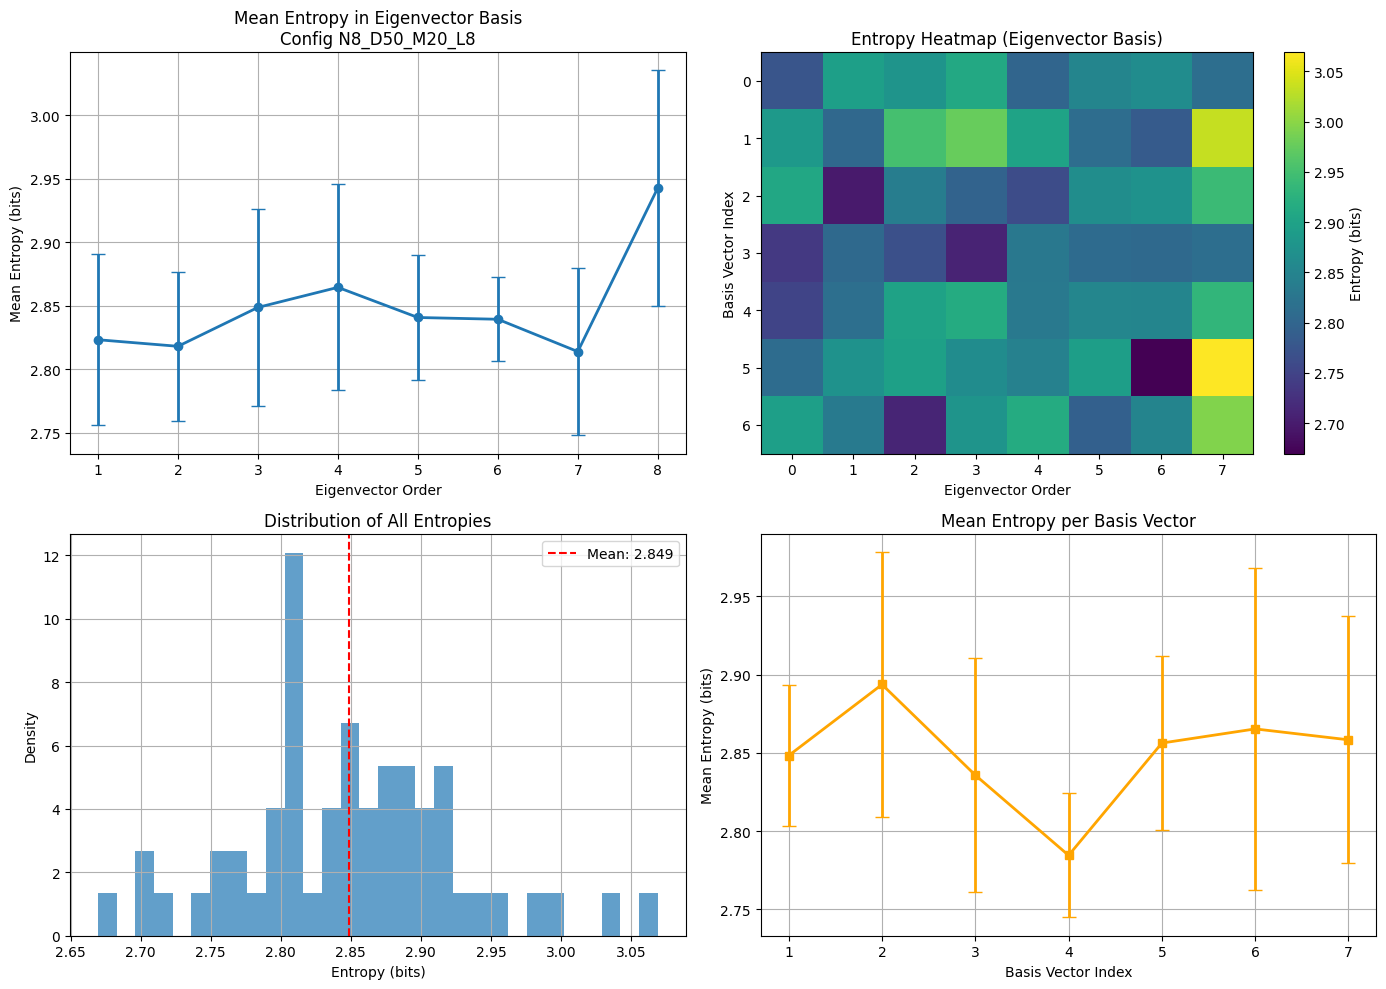

Processing experiment files:  57%|█████▋    | 55/97 [07:43<05:56,  8.48s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8489 ± 0.0784 bits
  Max entropy: 3.0691 bits
  Min entropy: 2.6695 bits
  Number of basis vectors used: 7

Most random eigenvector: 8th
  Mean entropy: 2.9428 ± 0.0927 bits

Least random eigenvector: 7th
  Mean entropy: 2.8139 ± 0.0661 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8489 bits
  Difference: -3.7805 bits


Computing entropy in eigenvector basis - N8_D50_M100_L2
Using first experiment as basis, analyzing 99 remaining experiments


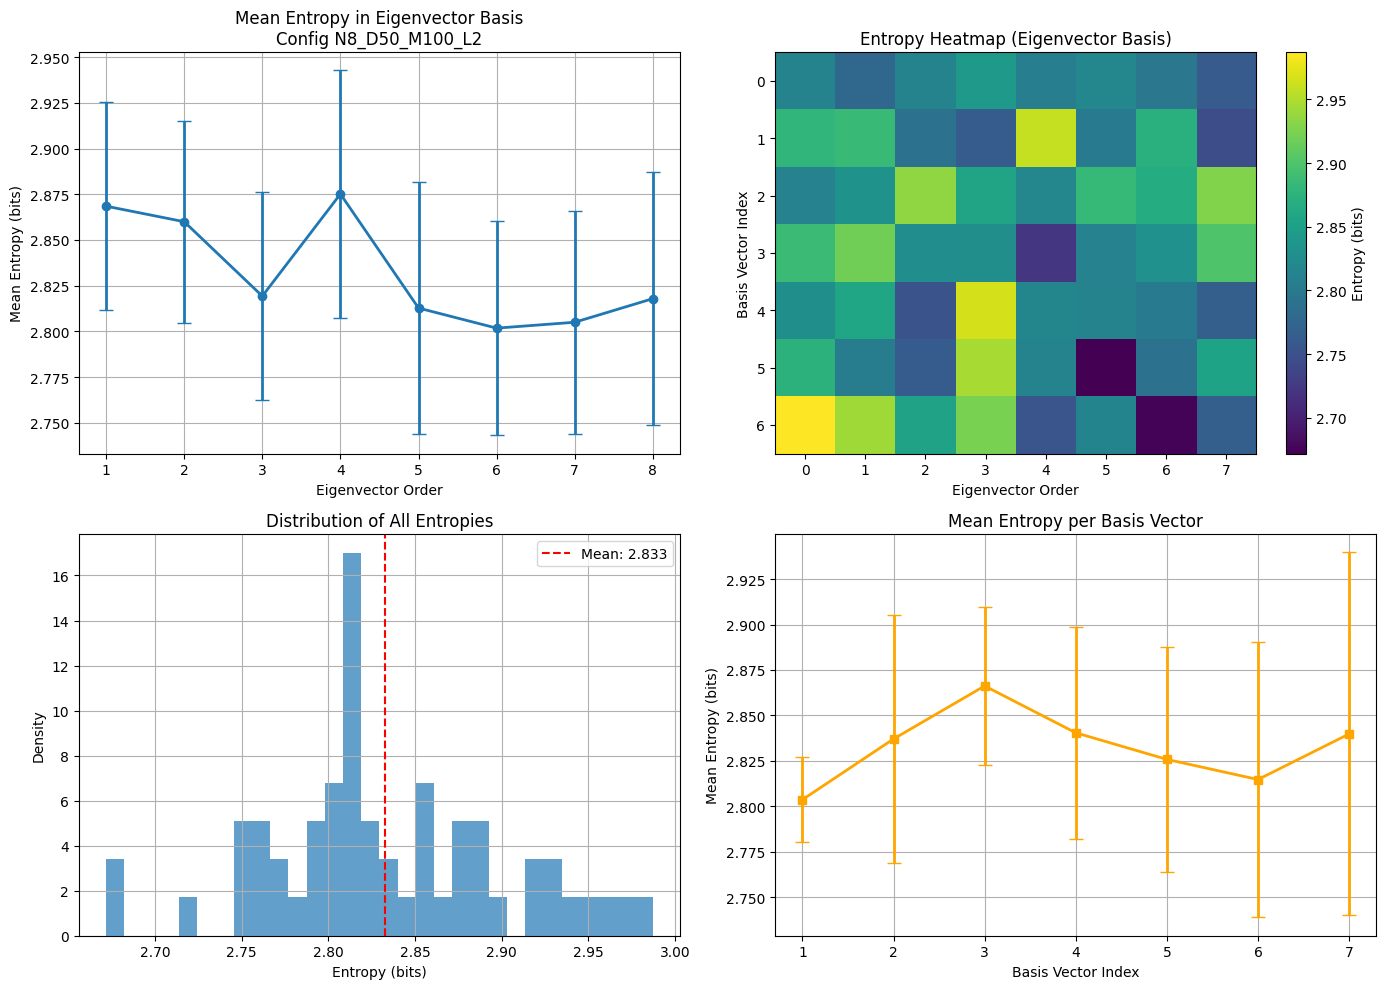

Processing experiment files:  58%|█████▊    | 56/97 [07:51<05:40,  8.30s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8325 ± 0.0682 bits
  Max entropy: 2.9872 bits
  Min entropy: 2.6717 bits
  Number of basis vectors used: 7

Most random eigenvector: 4th
  Mean entropy: 2.8752 ± 0.0677 bits

Least random eigenvector: 6th
  Mean entropy: 2.8018 ± 0.0587 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8325 bits
  Difference: -3.7968 bits


Computing entropy in eigenvector basis - N10_D20_M10_L2
Using first experiment as basis, analyzing 99 remaining experiments


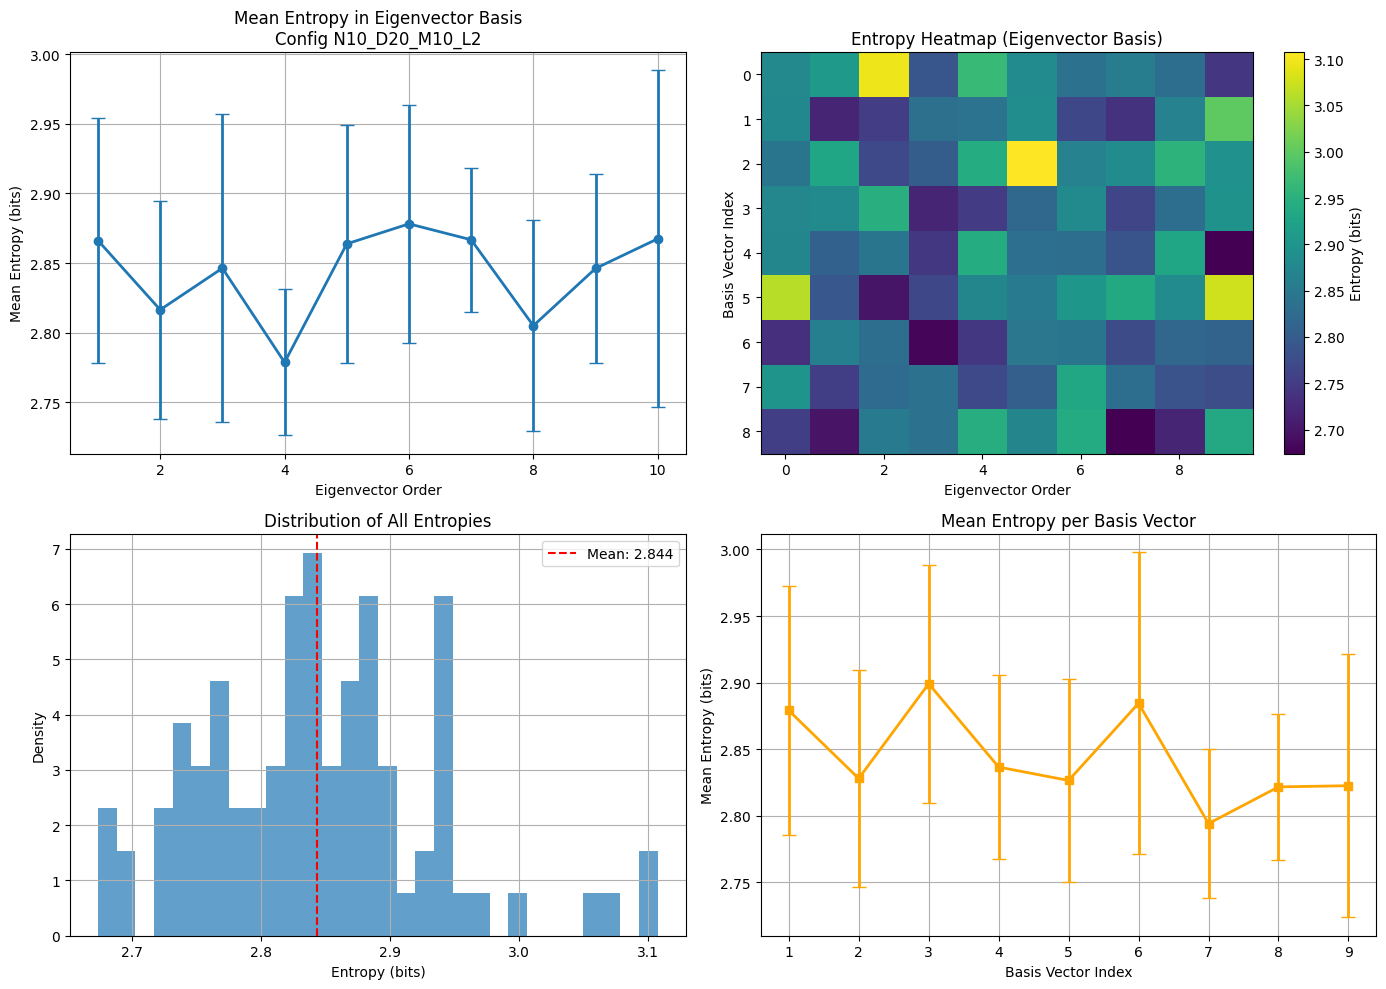

Processing experiment files:  59%|█████▉    | 57/97 [08:03<06:26,  9.65s/it]


Entropy Statistics in Eigenvector Basis:
  Overall mean entropy: 2.8436 ± 0.0899 bits
  Max entropy: 3.1076 bits
  Min entropy: 2.6740 bits
  Number of basis vectors used: 9

Most random eigenvector: 6th
  Mean entropy: 2.8782 ± 0.0852 bits

Least random eigenvector: 4th
  Mean entropy: 2.7788 ± 0.0524 bits

Uniformity Analysis:
  Theoretical uniform entropy (approx): 6.6294 bits
  Observed mean entropy: 2.8436 bits
  Difference: -3.7858 bits


Computing entropy in eigenvector basis - N10_D20_M50_L6
Using first experiment as basis, analyzing 99 remaining experiments


Processing experiment files:  59%|█████▉    | 57/97 [08:11<05:44,  8.62s/it]


KeyboardInterrupt: 

In [ ]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files  # we process all files
    print("Processing all experiment files for eigenvector basis entropy analysis...")
    print("=" * 80)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we analyze entropy in eigenvector basis
            analyze_entropy_in_eigenvector_basis(
                eigenvectors_data['eigenvectors'].transpose(0, 2, 1), N, D_IN, M, L, PATH_TO_PLOTS
            )
            
            print("\n" + "="*50 + "\n")
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("Eigenvector basis entropy analysis complete!")